# Getting Started: Market Research
This Jupyter notebook is a quick demonstration on how to get started on the market research section.

## 1) Download Data
Please download the train and test data and place it within the ./research/data path. If you've placed it in the correct place, you should see the following cell work:

In [3]:
import pandas as pd

train_data = pd.read_csv('../data/train.csv')
test_data = pd.read_csv('../data/test.csv')

print(train_data.head())
print(test_data.head())

   time         A         B         C         D         E         F         G  \
0     0  0.207366 -0.159951 -0.634176 -0.580962 -0.266505  0.060173 -0.475257   
1     1  0.188828 -0.265508  0.042143 -0.550442 -0.132319 -0.185219  0.028295   
2     2 -0.144261 -0.577142 -0.214634 -0.747391 -0.184255 -0.464831 -0.085181   
3     3  0.208982 -0.310449  0.513708 -0.562868  0.742308 -0.305487  0.762246   
4     4  0.093320 -0.358156  0.173188 -0.687296 -0.161461 -0.116062 -0.245748   

          H         I         J         K         L         M         N  \
0 -1.486516 -0.332594 -0.671466 -0.226149 -0.187624 -0.780237 -0.785965   
1  0.093210 -0.518139 -0.251917 -0.347845 -0.359069 -0.161254  0.020401   
2  0.700449 -0.603438  0.197773 -0.566696 -0.580799  0.202726  0.135261   
3  1.363020 -0.384575  0.525556 -0.348514 -0.428099  0.548993  0.471031   
4  0.863372 -0.655588 -0.263358 -0.557428 -0.481214  0.083602  0.003087   

         Y1        Y2  
0 -0.935902 -0.310081  
1 -0.089707 -0

## 2) Investigate the Dataset
In the datasets, you're given columns of time and A through N, each of which represent some sort of real-life market quantity. In the train dataset, you're also given Y1 and Y2, real-life market quantities you'd like to predict in terms of time and A through N. You're not given Y1 and Y2 in the test set, because this is what you're being asked to predict.

Let's do some exploration of the relationships of A - N and Y1. In particular, let's look at the relationship between C and Y1:

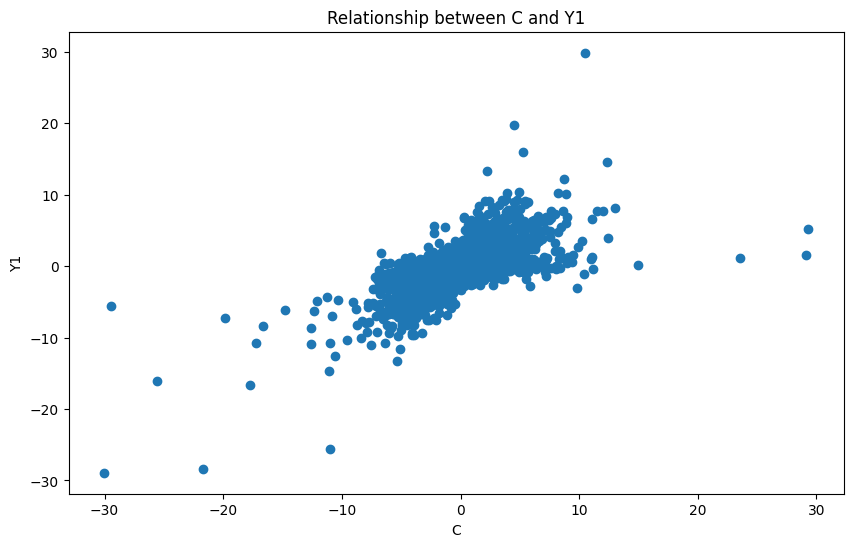

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(train_data['C'], train_data['Y1'])
plt.xlabel('C')
plt.ylabel('Y1')
plt.title('Relationship between C and Y1')
plt.show()

In [10]:
# Calculate correlation between C and Y1
correlation = train_data['E'].corr(train_data['Y1'])
print(f"Correlation between C and Y1: {correlation:.4f}")

Correlation between C and Y1: 0.6843


Clearly there's a strong relationship between C and Y1. You should definitely use C to predict Y1!

In [12]:
target_cols=['Y1','Y2']
for target in target_cols:
    print(f"\nCorrelations with {target}:")
    correlations = train_data.corr(numeric_only=True)[target].drop(target)
    for col, corr in correlations.items():
        print(f"{col:>6} : {corr:.4f}")


Correlations with Y1:
  time : -0.0056
     A : -0.0061
     B : -0.0950
     C : 0.7038
     D : -0.0571
     E : 0.6843
     F : -0.0732
     G : 0.8146
     H : 0.7076
     I : -0.0902
     J : 0.7239
     K : -0.0802
     L : -0.0724
     M : 0.6862
     N : 0.5958
    Y2 : -0.0643

Correlations with Y2:
  time : 0.0591
     A : 0.4847
     B : 0.5819
     C : -0.0730
     D : 0.6111
     E : -0.0446
     F : 0.4967
     G : -0.0602
     H : -0.0870
     I : 0.5083
     J : -0.0980
     K : 0.5992
     L : 0.5035
     M : -0.0953
     N : -0.0802
    Y1 : -0.0643


## 3) Submit Predictions
In order to submit predictions, we need to make a CSV file with three columns: id, Y1, and Y2. In the below example, we let our predictions of Y1 and Y2 be the means of Y1 and Y2 in the train set.

In [17]:
import pandas as pd
import statsmodels.api as sm

# Select significant features
features = ['C', 'E', 'G', 'H', 'J', 'M', 'N']
target = 'Y1'

X = train_data[features]
y = train_data[target]

# Add a constant (intercept) to the model
X = sm.add_constant(X)

# Fit OLS regression
model = sm.OLS(y, X).fit()

# Print full summary (like in R)
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                     Y1   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                 3.535e+04
Date:                Fri, 19 Sep 2025   Prob (F-statistic):               0.00
Time:                        23:51:53   Log-Likelihood:                -54761.
No. Observations:               80000   AIC:                         1.095e+05
Df Residuals:                   79992   BIC:                         1.096e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0023      0.002     -1.369      0.1

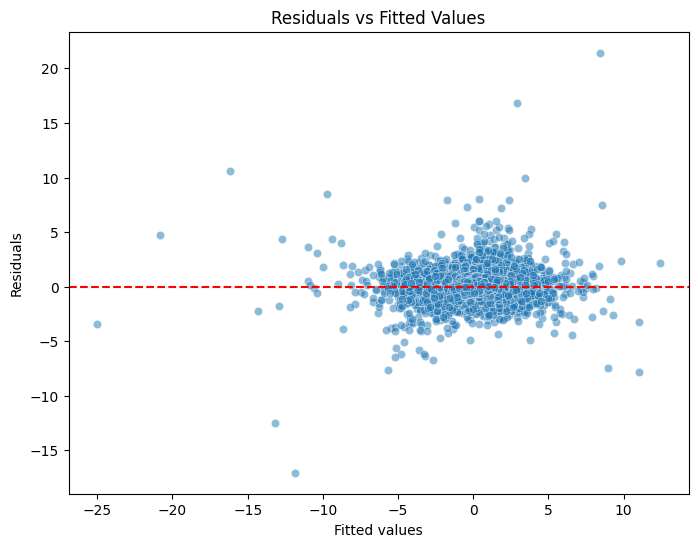

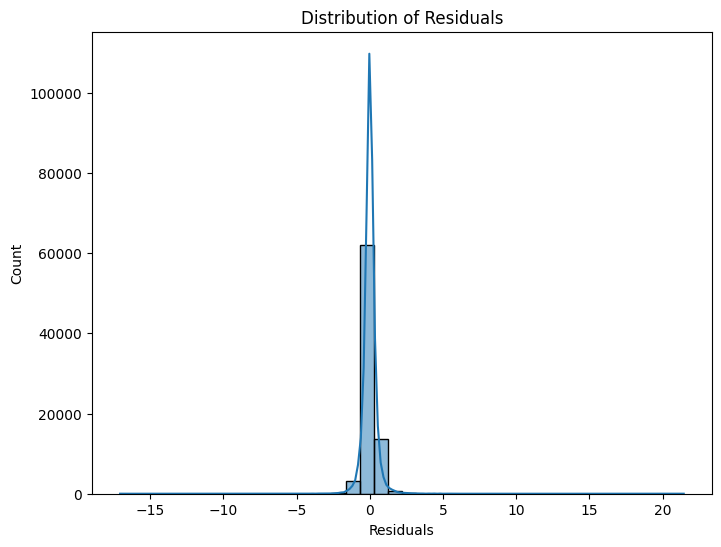

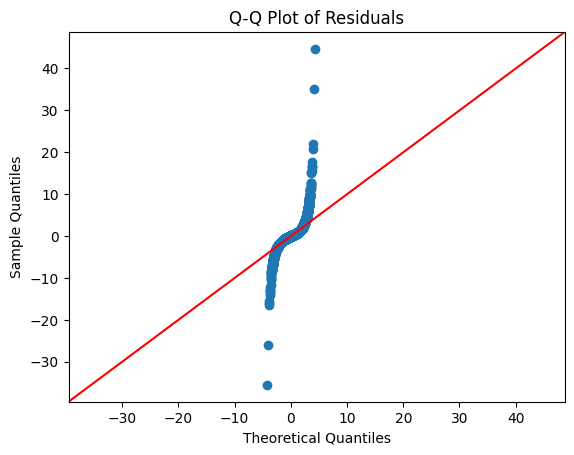

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Residuals and fitted values
residuals = model.resid
fitted = model.fittedvalues

# 1. Residuals vs Fitted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

# 2. Histogram of residuals
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=40)
plt.xlabel("Residuals")
plt.title("Distribution of Residuals")
plt.show()

# 3. Q-Q plot for normality
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()


Optimal λ (lambda): 0.9335
Skewness before: 1.7223245534480764
Skewness after : 1.3547054304251223


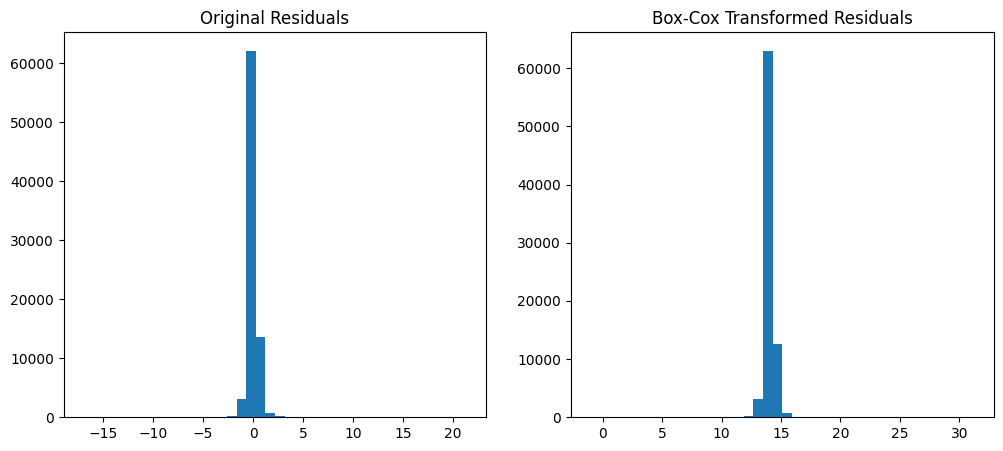

In [20]:
from scipy import stats
import numpy as np

# Ensure residuals are positive by shifting (if needed)
residuals_shifted = residuals - residuals.min() + 1e-6  

# Box-Cox transformation
residuals_bc, lambda_opt = stats.boxcox(residuals_shifted)

print(f"Optimal λ (lambda): {lambda_opt:.4f}")

# Compare skewness before vs after
print("Skewness before:", stats.skew(residuals))
print("Skewness after :", stats.skew(residuals_bc))

# Plot histogram before/after
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(residuals, bins=40)
plt.title("Original Residuals")

plt.subplot(1,2,2)
plt.hist(residuals_bc, bins=40)
plt.title("Box-Cox Transformed Residuals")

plt.show()


In [19]:
from scipy import stats

# Shapiro-Wilk test (normality)
shapiro_test = stats.shapiro(residuals[:5000])  # limit size for speed
print("Shapiro-Wilk:", shapiro_test)

# Anderson-Darling test
anderson_test = stats.anderson(residuals)
print("Anderson-Darling statistic:", anderson_test.statistic)

# Skewness and Kurtosis
print("Skewness:", stats.skew(residuals))
print("Kurtosis:", stats.kurtosis(residuals))  # >0 = heavy tails


Shapiro-Wilk: ShapiroResult(statistic=np.float64(0.8071787238075039), pvalue=np.float64(6.703199084769523e-61))
Anderson-Darling statistic: 2316.0718095677876
Skewness: 1.7223245534480764
Kurtosis: 121.57566004763666


Skewness before: 1.7223245534480764
Skewness after : -0.5264669031563122
Kurtosis before: 121.57566004763666
Kurtosis after : 112.91317621042661


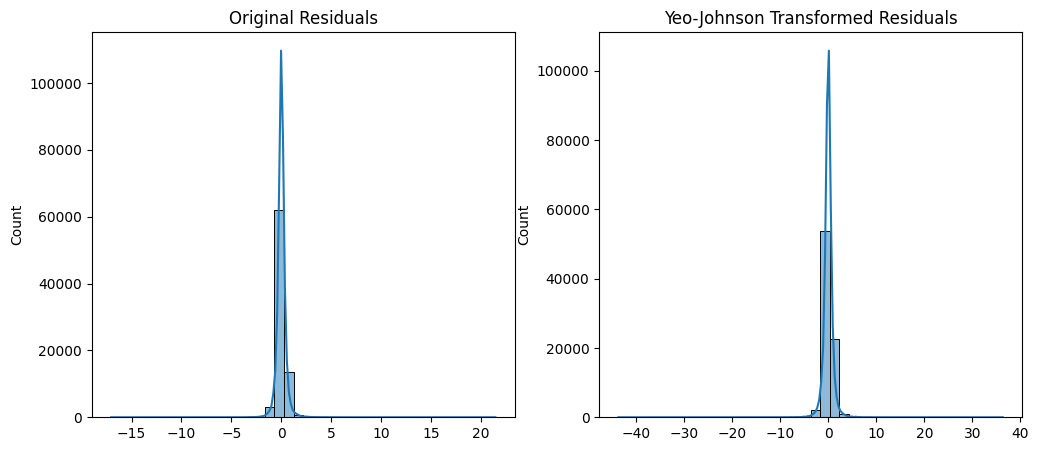

In [21]:
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Reshape residuals for sklearn
residuals_reshaped = residuals.values.reshape(-1, 1)

# Apply Yeo-Johnson transform
pt = PowerTransformer(method='yeo-johnson')
residuals_yj = pt.fit_transform(residuals_reshaped).flatten()

# Compare skewness before and after
print("Skewness before:", stats.skew(residuals))
print("Skewness after :", stats.skew(residuals_yj))
print("Kurtosis before:", stats.kurtosis(residuals))
print("Kurtosis after :", stats.kurtosis(residuals_yj))

# Plot histograms
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(residuals, kde=True, bins=40)
plt.title("Original Residuals")

plt.subplot(1,2,2)
sns.histplot(residuals_yj, kde=True, bins=40)
plt.title("Yeo-Johnson Transformed Residuals")

plt.show()


Huber Regression Results for Y1
Mean Squared Error: 0.2322
R² Score: 0.7535
Coefficients: {'C': np.float64(0.0679338062062791), 'E': np.float64(0.08089514264063259), 'G': np.float64(0.41526625931603994), 'H': np.float64(0.1068435851192345), 'J': np.float64(0.11084273346350483), 'M': np.float64(0.09392290991443113), 'N': np.float64(0.035005005542295076)}
Intercept: -0.007911451690430544


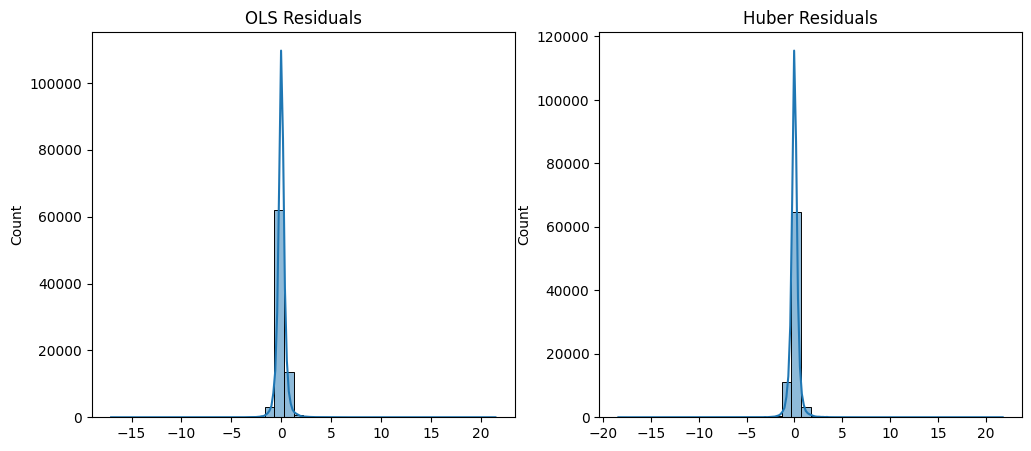

In [22]:
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Features and target
features = ['C', 'E', 'G', 'H', 'J', 'M', 'N']
X = train_data[features].values
y = train_data['Y1'].values

# Fit Huber regression
huber = HuberRegressor()
huber.fit(X, y)

# Predictions
y_pred = huber.predict(X)

# Residuals
residuals_huber = y - y_pred

# Evaluation metrics
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Huber Regression Results for Y1")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")
print("Coefficients:", dict(zip(features, huber.coef_)))
print("Intercept:", huber.intercept_)

# Compare residual distribution
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(residuals, kde=True, bins=40)  # from your OLS
plt.title("OLS Residuals")

plt.subplot(1,2,2)
sns.histplot(residuals_huber, kde=True, bins=40)
plt.title("Huber Residuals")

plt.show()


In [23]:
from scipy import stats

# Residuals from Huber
residuals_huber = y - y_pred

# Skewness and kurtosis
skewness_huber = stats.skew(residuals_huber)
kurtosis_huber = stats.kurtosis(residuals_huber)  # excess kurtosis (0 = normal)
print("Huber Residuals - Skewness:", skewness_huber)
print("Huber Residuals - Kurtosis:", kurtosis_huber)

# For comparison: OLS residuals
print("OLS Residuals - Skewness:", stats.skew(residuals))
print("OLS Residuals - Kurtosis:", stats.kurtosis(residuals))


Huber Residuals - Skewness: 1.565820431930694
Huber Residuals - Kurtosis: 132.26187455904835
OLS Residuals - Skewness: 1.7223245534480764
OLS Residuals - Kurtosis: 121.57566004763666


Before Winsorization
  Skewness : 1.7223245534480764
  Kurtosis : 121.57566004763666

After Winsorization
  Skewness : 0.1927712494440552
  Kurtosis : 2.0726593001878095


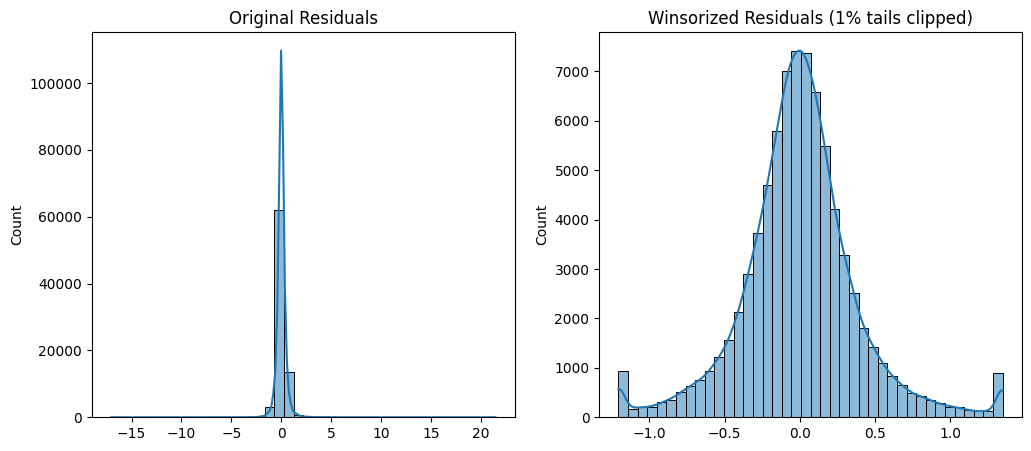

In [24]:
from scipy.stats.mstats import winsorize
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Winsorize residuals (clip 1% on both tails)
residuals_wins = winsorize(residuals, limits=[0.01, 0.01])

# Check skewness & kurtosis
print("Before Winsorization")
print("  Skewness :", stats.skew(residuals))
print("  Kurtosis :", stats.kurtosis(residuals))

print("\nAfter Winsorization")
print("  Skewness :", stats.skew(residuals_wins))
print("  Kurtosis :", stats.kurtosis(residuals_wins))

# Compare histograms
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(residuals, kde=True, bins=40)
plt.title("Original Residuals")

plt.subplot(1,2,2)
sns.histplot(residuals_wins, kde=True, bins=40)
plt.title("Winsorized Residuals (1% tails clipped)")

plt.show()


You should now be able to submit preds.csv to [https://quantchallenge.org/dashboard/data/upload-predictions](https://quantchallenge.org/dashboard/data/upload-predictions)! Note that you should receive a public $R^2$ score of $-0.042456$ with this set of predictions. You should try to get the highest possible $R^2$ score over the course of these next few days. Be careful of overfitting to the public score, which is only calculated on a subset of the test data—the final score that counts is the private $R^2$ score!

Optimal λ (lambda): 0.8436415006363722
Skewness before: 1.7223245534480764
Kurtosis before: 121.57566004763666

After Winsorization + Box-Cox:
Skewness : -0.21730718527124998
Kurtosis : 2.3695449590784348


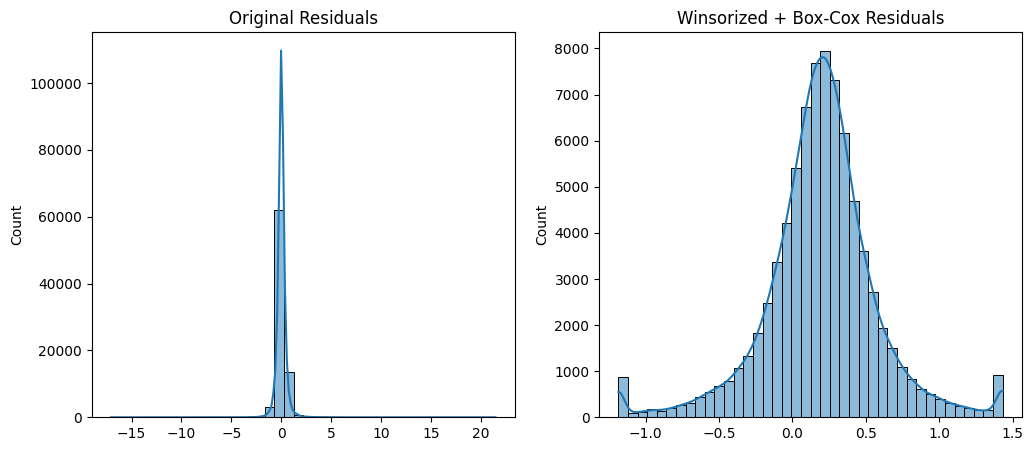

In [25]:
from scipy.stats.mstats import winsorize
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 1: Winsorize residuals (clip 1% tails)
residuals_wins = winsorize(residuals, limits=[0.01, 0.01])

# Step 2: Shift to positive (Box-Cox requires > 0)
residuals_wins_shift = residuals_wins - residuals_wins.min() + 1e-6

# Step 3: Box-Cox transform
residuals_bc, lambda_opt = stats.boxcox(residuals_wins_shift)

print("Optimal λ (lambda):", lambda_opt)
print("Skewness before:", stats.skew(residuals))
print("Kurtosis before:", stats.kurtosis(residuals))
print("\nAfter Winsorization + Box-Cox:")
print("Skewness :", stats.skew(residuals_bc))
print("Kurtosis :", stats.kurtosis(residuals_bc))

# Plot histograms
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(residuals, kde=True, bins=40)
plt.title("Original Residuals")

plt.subplot(1,2,2)
sns.histplot(residuals_bc, kde=True, bins=40)
plt.title("Winsorized + Box-Cox Residuals")

plt.show()


Original Residuals:
  Skewness : 1.7223245534480764
  Kurtosis : 121.57566004763666

After Winsorization:
  Skewness : 0.1927712494440552
  Kurtosis : 2.0726593001878095

After Winsorization + Yeo-Johnson:
  Skewness : -0.015351110063813922
  Kurtosis : 1.996147800332463


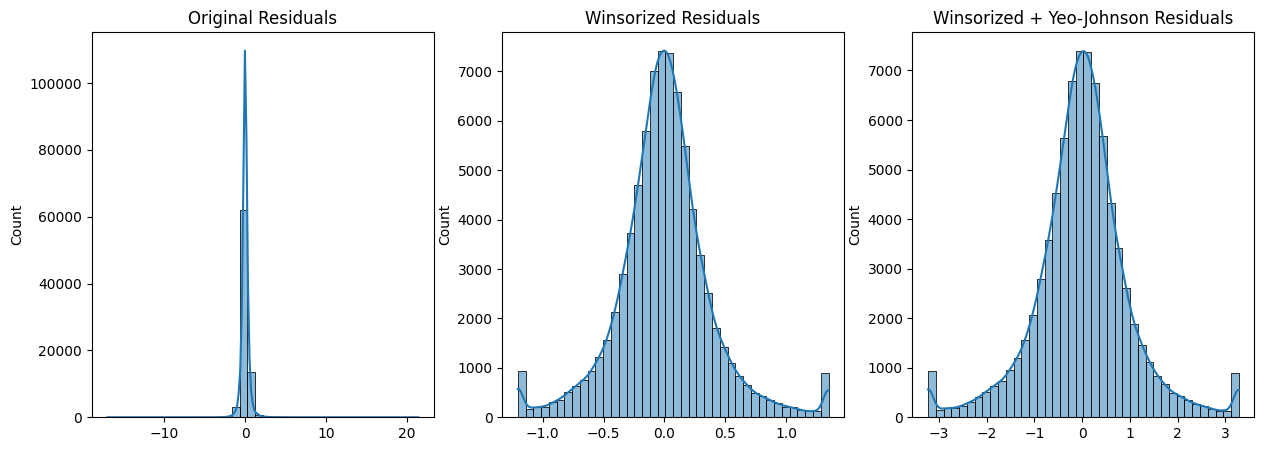

In [26]:
from scipy.stats.mstats import winsorize
from scipy import stats
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 1: Winsorize residuals (clip 1% tails)
residuals_wins = winsorize(residuals, limits=[0.01, 0.01])

# Step 2: Yeo-Johnson transform (works with negatives too)
pt = PowerTransformer(method='yeo-johnson')
residuals_yj = pt.fit_transform(np.array(residuals_wins).reshape(-1,1)).flatten()

# Step 3: Compare skewness and kurtosis
print("Original Residuals:")
print("  Skewness :", stats.skew(residuals))
print("  Kurtosis :", stats.kurtosis(residuals))

print("\nAfter Winsorization:")
print("  Skewness :", stats.skew(residuals_wins))
print("  Kurtosis :", stats.kurtosis(residuals_wins))

print("\nAfter Winsorization + Yeo-Johnson:")
print("  Skewness :", stats.skew(residuals_yj))
print("  Kurtosis :", stats.kurtosis(residuals_yj))

# Step 4: Plot histograms
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(residuals, kde=True, bins=40)
plt.title("Original Residuals")

plt.subplot(1,3,2)
sns.histplot(residuals_wins, kde=True, bins=40)
plt.title("Winsorized Residuals")

plt.subplot(1,3,3)
sns.histplot(residuals_yj, kde=True, bins=40)
plt.title("Winsorized + Yeo-Johnson Residuals")

plt.show()


In [27]:
import pandas as pd
import numpy as np
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import PowerTransformer
import statsmodels.api as sm

# === Step 1: Features & Target ===
features = ['C', 'E', 'G', 'H', 'J', 'M', 'N']
X = train_data[features].values
y = train_data['Y1'].values

# === Step 2: Winsorize target (clip 1% tails) ===
y_wins = winsorize(y, limits=[0.01, 0.01])

# === Step 3: Yeo-Johnson transform ===
pt = PowerTransformer(method='yeo-johnson')
y_transformed = pt.fit_transform(np.array(y_wins).reshape(-1,1)).flatten()

# === Step 4: Fit OLS regression ===
X_const = sm.add_constant(X)  # add intercept
model = sm.OLS(y_transformed, X_const).fit()

# === Step 5: Print results ===
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.700
Model:                            OLS   Adj. R-squared:                  0.700
Method:                 Least Squares   F-statistic:                 2.663e+04
Date:                Sat, 20 Sep 2025   Prob (F-statistic):               0.00
Time:                        00:16:26   Log-Likelihood:                -65392.
No. Observations:               80000   AIC:                         1.308e+05
Df Residuals:                   79992   BIC:                         1.309e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.002      0.271      0.7

In [29]:
import pandas as pd
import statsmodels.api as sm

# Select significant features for Y2
features_y2 = ['A', 'B', 'D', 'F', 'I', 'K', 'L']
target = 'Y2'

X_y2 = train_data[features_y2]
y_y2 = train_data[target]

# Add constant (intercept)
X_y2 = sm.add_constant(X_y2)

# Fit OLS regression
model_y2 = sm.OLS(y_y2, X_y2).fit()

# Print summary
print(model_y2.summary())


                            OLS Regression Results                            
Dep. Variable:                     Y2   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                 1.815e+04
Date:                Sat, 20 Sep 2025   Prob (F-statistic):               0.00
Time:                        00:26:13   Log-Likelihood:                -69124.
No. Observations:               80000   AIC:                         1.383e+05
Df Residuals:                   79992   BIC:                         1.383e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0938      0.002    -45.914      0.0

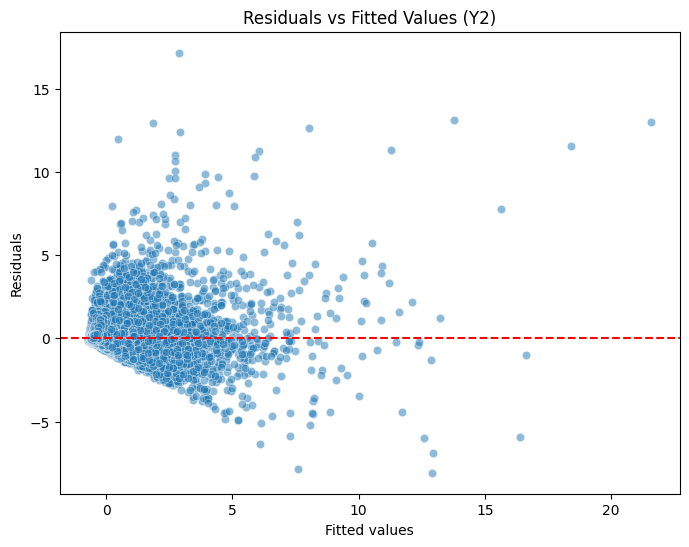

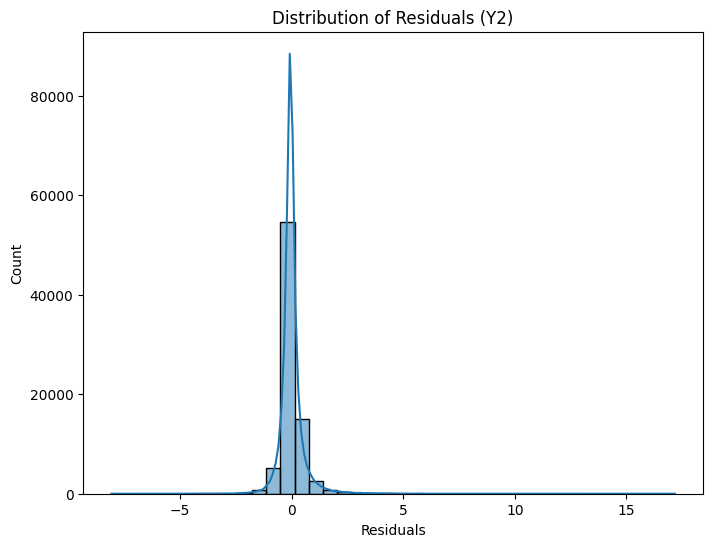

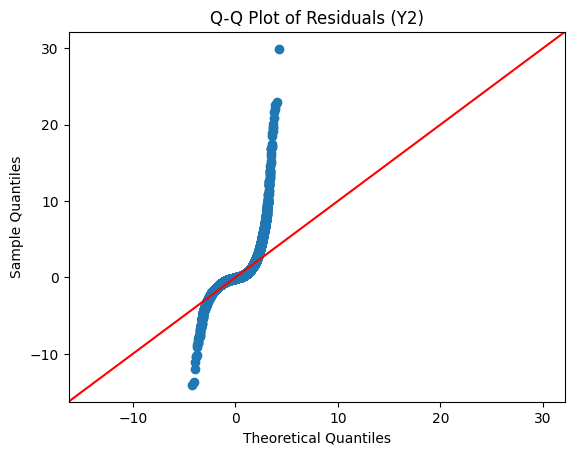

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Residuals and fitted values for Y2 model
residuals_y2 = model_y2.resid
fitted_y2 = model_y2.fittedvalues

# 1. Residuals vs Fitted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_y2, y=residuals_y2, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (Y2)")
plt.show()

# 2. Histogram of residuals
plt.figure(figsize=(8, 6))
sns.histplot(residuals_y2, kde=True, bins=40)
plt.xlabel("Residuals")
plt.title("Distribution of Residuals (Y2)")
plt.show()

# 3. Q-Q plot for normality
sm.qqplot(residuals_y2, line='45', fit=True)
plt.title("Q-Q Plot of Residuals (Y2)")
plt.show()


Optimal λ (lambda) for Y2: 0.3929
Skewness before: 4.300235861467223
Skewness after : 1.0575370544843836


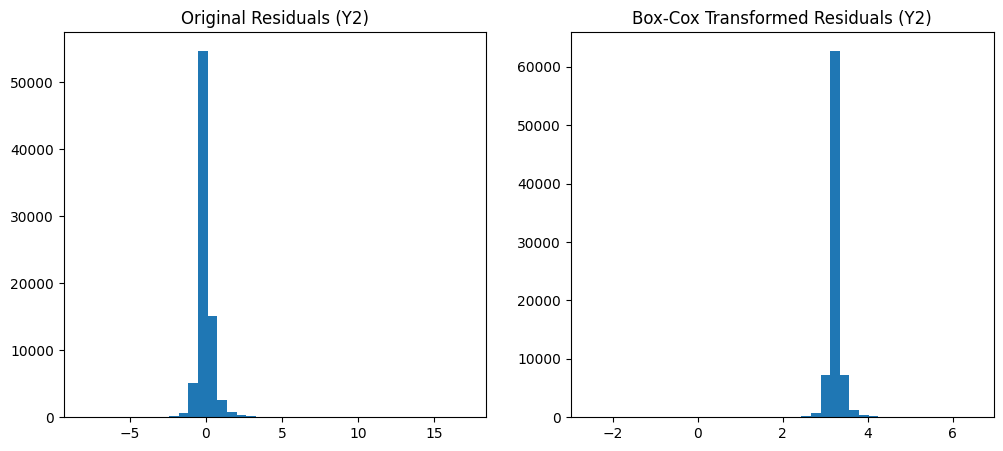

In [31]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# Residuals from Y2 model
residuals_y2 = model_y2.resid

# Step 1: Shift residuals to be strictly positive (Box-Cox requirement)
residuals_y2_shifted = residuals_y2 - residuals_y2.min() + 1e-6  

# Step 2: Apply Box-Cox transformation
residuals_y2_bc, lambda_y2 = stats.boxcox(residuals_y2_shifted)

print(f"Optimal λ (lambda) for Y2: {lambda_y2:.4f}")

# Step 3: Compare skewness before vs after
print("Skewness before:", stats.skew(residuals_y2))
print("Skewness after :", stats.skew(residuals_y2_bc))

# Step 4: Plot histograms before/after
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(residuals_y2, bins=40)
plt.title("Original Residuals (Y2)")

plt.subplot(1,2,2)
plt.hist(residuals_y2_bc, bins=40)
plt.title("Box-Cox Transformed Residuals (Y2)")

plt.show()


In [32]:
from scipy import stats

# Residuals from Y2 model
residuals_y2 = model_y2.resid

# Shapiro-Wilk test (use subset for speed, same as Y1)
shapiro_test_y2 = stats.shapiro(residuals_y2[:5000])
print("Shapiro-Wilk (Y2):", shapiro_test_y2)

# Anderson-Darling test
anderson_test_y2 = stats.anderson(residuals_y2)
print("Anderson-Darling statistic (Y2):", anderson_test_y2.statistic)

# Skewness and Kurtosis
print("Skewness (Y2):", stats.skew(residuals_y2))
print("Kurtosis (Y2):", stats.kurtosis(residuals_y2))  # >0 = heavy tails


Shapiro-Wilk (Y2): ShapiroResult(statistic=np.float64(0.7675030101735596), pvalue=np.float64(1.8188804152411492e-64))
Anderson-Darling statistic (Y2): 5091.427957802778
Skewness (Y2): 4.300235861467223
Kurtosis (Y2): 70.54733823923792


Skewness before (Y2): 4.300235861467223
Skewness after  (Y2): -1.2321969276134268
Kurtosis before (Y2): 70.54733823923792
Kurtosis after  (Y2): 48.992349382444615


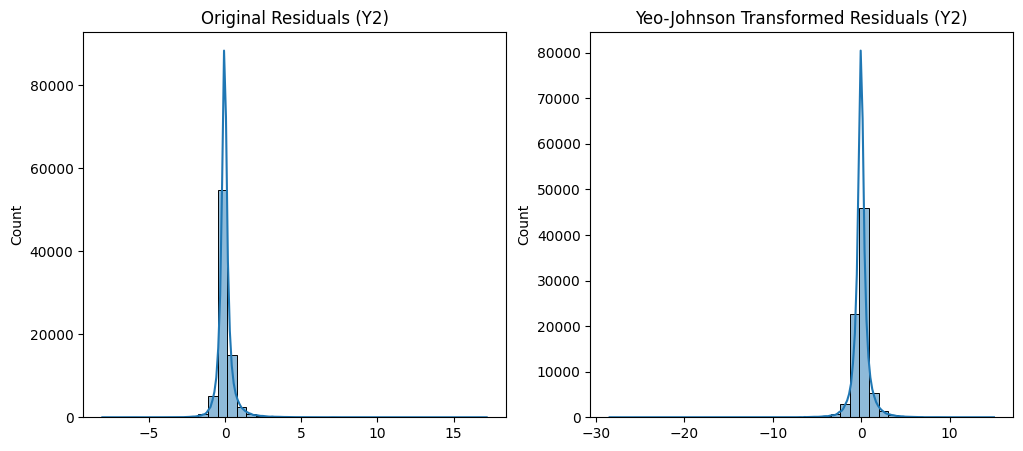

In [33]:
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Residuals from Y2 model
residuals_y2 = model_y2.resid

# Reshape residuals for sklearn
residuals_y2_reshaped = residuals_y2.values.reshape(-1, 1)

# Apply Yeo-Johnson transform
pt_y2 = PowerTransformer(method='yeo-johnson')
residuals_y2_yj = pt_y2.fit_transform(residuals_y2_reshaped).flatten()

# Compare skewness before and after
print("Skewness before (Y2):", stats.skew(residuals_y2))
print("Skewness after  (Y2):", stats.skew(residuals_y2_yj))
print("Kurtosis before (Y2):", stats.kurtosis(residuals_y2))
print("Kurtosis after  (Y2):", stats.kurtosis(residuals_y2_yj))

# Plot histograms
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(residuals_y2, kde=True, bins=40)
plt.title("Original Residuals (Y2)")

plt.subplot(1,2,2)
sns.histplot(residuals_y2_yj, kde=True, bins=40)
plt.title("Yeo-Johnson Transformed Residuals (Y2)")

plt.show()


Huber Regression Results for Y2
Mean Squared Error: 0.3531
R² Score: 0.5861
Coefficients: {'A': np.float64(0.17545576668371193), 'B': np.float64(0.10545430111893768), 'D': np.float64(0.1417681964317701), 'F': np.float64(0.09295539031899308), 'I': np.float64(0.047802580225279355), 'K': np.float64(0.16851656905166734), 'L': np.float64(0.07963019535131909)}
Intercept: -0.17216649673653903


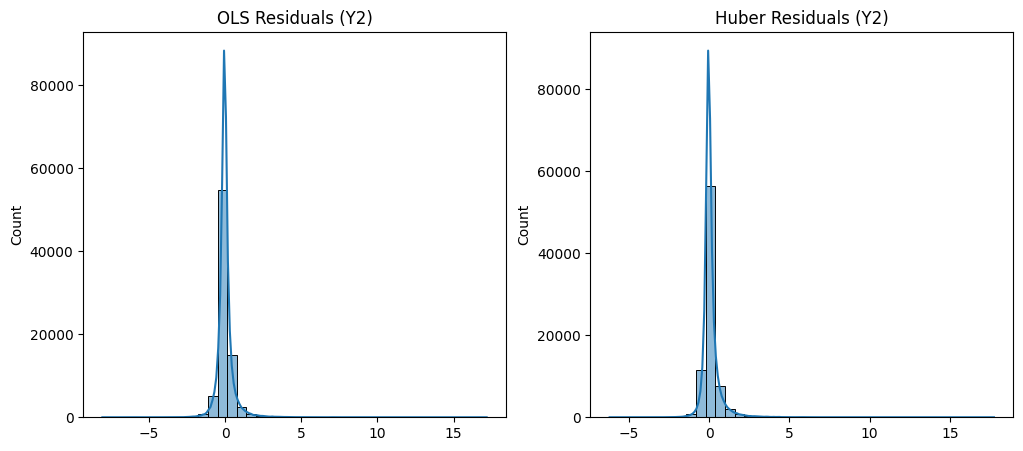

In [34]:
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Features and target for Y2
features_y2 = ['A', 'B', 'D', 'F', 'I', 'K', 'L']
X_y2 = train_data[features_y2].values
y2 = train_data['Y2'].values

# Fit Huber regression
huber_y2 = HuberRegressor()
huber_y2.fit(X_y2, y2)

# Predictions
y2_pred = huber_y2.predict(X_y2)

# Residuals
residuals_y2_huber = y2 - y2_pred

# Evaluation metrics
mse_y2 = mean_squared_error(y2, y2_pred)
r2_y2 = r2_score(y2, y2_pred)

print("Huber Regression Results for Y2")
print(f"Mean Squared Error: {mse_y2:.4f}")
print(f"R² Score: {r2_y2:.4f}")
print("Coefficients:", dict(zip(features_y2, huber_y2.coef_)))
print("Intercept:", huber_y2.intercept_)

# Compare residual distribution (OLS vs Huber)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(model_y2.resid, kde=True, bins=40)  # OLS residuals
plt.title("OLS Residuals (Y2)")

plt.subplot(1,2,2)
sns.histplot(residuals_y2_huber, kde=True, bins=40)
plt.title("Huber Residuals (Y2)")

plt.show()


In [35]:
from scipy import stats

# Skewness and kurtosis of Huber residuals (Y2)
skewness_y2_huber = stats.skew(residuals_y2_huber)
kurtosis_y2_huber = stats.kurtosis(residuals_y2_huber)

print("Huber Residuals (Y2) - Skewness:", skewness_y2_huber)
print("Huber Residuals (Y2) - Kurtosis:", kurtosis_y2_huber)

# For comparison: OLS residuals (Y2)
print("OLS Residuals (Y2) - Skewness:", stats.skew(model_y2.resid))
print("OLS Residuals (Y2) - Kurtosis:", stats.kurtosis(model_y2.resid))


Huber Residuals (Y2) - Skewness: 5.854678398638215
Huber Residuals (Y2) - Kurtosis: 89.4559592947177
OLS Residuals (Y2) - Skewness: 4.300235861467223
OLS Residuals (Y2) - Kurtosis: 70.54733823923792


Before Winsorization (Y2)
  Skewness : 4.300235861467223
  Kurtosis : 70.54733823923792

After Winsorization (Y2)
  Skewness : 0.9500747949979943
  Kurtosis : 2.6856898580037365


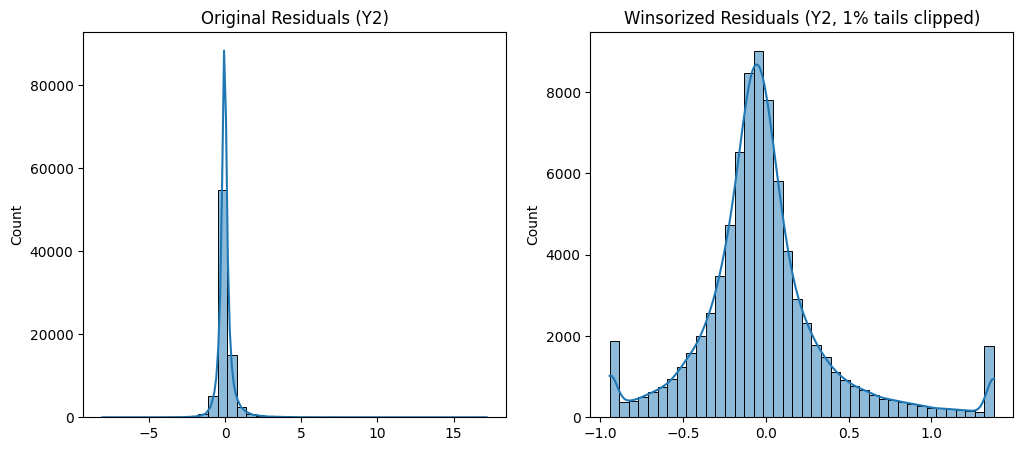

In [38]:
from scipy.stats.mstats import winsorize
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Residuals from Y2 OLS model
residuals_y2 = model_y2.resid

# Winsorize residuals (clip 1% on both tails)
residuals_y2_wins = winsorize(residuals_y2, limits=[0.02, 0.02])

# Check skewness & kurtosis
print("Before Winsorization (Y2)")
print("  Skewness :", stats.skew(residuals_y2))
print("  Kurtosis :", stats.kurtosis(residuals_y2))

print("\nAfter Winsorization (Y2)")
print("  Skewness :", stats.skew(residuals_y2_wins))
print("  Kurtosis :", stats.kurtosis(residuals_y2_wins))

# Compare histograms
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(residuals_y2, kde=True, bins=40)
plt.title("Original Residuals (Y2)")

plt.subplot(1,2,2)
sns.histplot(residuals_y2_wins, kde=True, bins=40)
plt.title("Winsorized Residuals (Y2, 1% tails clipped)")

plt.show()


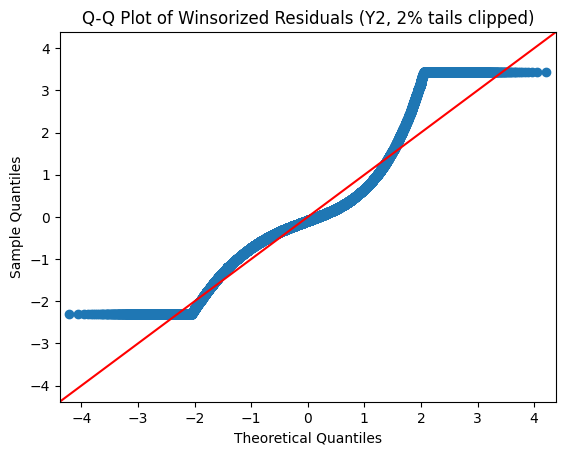

In [39]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Q–Q plot of Winsorized Y2 residuals
sm.qqplot(residuals_y2_wins, line='45', fit=True)
plt.title("Q-Q Plot of Winsorized Residuals (Y2, 2% tails clipped)")
plt.show()


Optimal λ (lambda) for Y2: 0.6495693938117744
Skewness before (Y2): 4.300235861467223
Kurtosis before (Y2): 70.54733823923792

After Winsorization (2%) + Box-Cox (Y2):
  Skewness : -0.24947209682570218
  Kurtosis : 2.6785649003029004


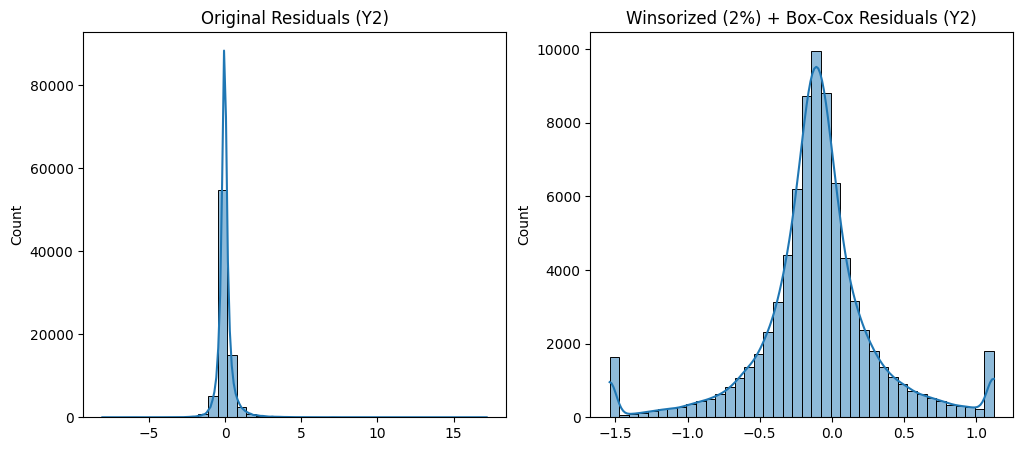

In [40]:
from scipy.stats.mstats import winsorize
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Residuals from Y2 OLS model
residuals_y2 = model_y2.resid

# Step 1: Winsorize residuals (clip 2% tails)
residuals_y2_wins = winsorize(residuals_y2, limits=[0.02, 0.02])

# Step 2: Shift to positive (Box-Cox requires > 0)
residuals_y2_wins_shift = residuals_y2_wins - residuals_y2_wins.min() + 1e-6

# Step 3: Box-Cox transform
residuals_y2_bc, lambda_y2 = stats.boxcox(residuals_y2_wins_shift)

print("Optimal λ (lambda) for Y2:", lambda_y2)
print("Skewness before (Y2):", stats.skew(residuals_y2))
print("Kurtosis before (Y2):", stats.kurtosis(residuals_y2))
print("\nAfter Winsorization (2%) + Box-Cox (Y2):")
print("  Skewness :", stats.skew(residuals_y2_bc))
print("  Kurtosis :", stats.kurtosis(residuals_y2_bc))

# Plot histograms
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(residuals_y2, kde=True, bins=40)
plt.title("Original Residuals (Y2)")

plt.subplot(1,2,2)
sns.histplot(residuals_y2_bc, kde=True, bins=40)
plt.title("Winsorized (2%) + Box-Cox Residuals (Y2)")

plt.show()


Original Residuals (Y2):
  Skewness : 4.300235861467223
  Kurtosis : 70.54733823923792

After Winsorization (2%):
  Skewness : 0.9500747949979943
  Kurtosis : 2.6856898580037365

After Winsorization (2%) + Yeo-Johnson:
  Skewness : -0.11954962128584161
  Kurtosis : 1.7436346300478052


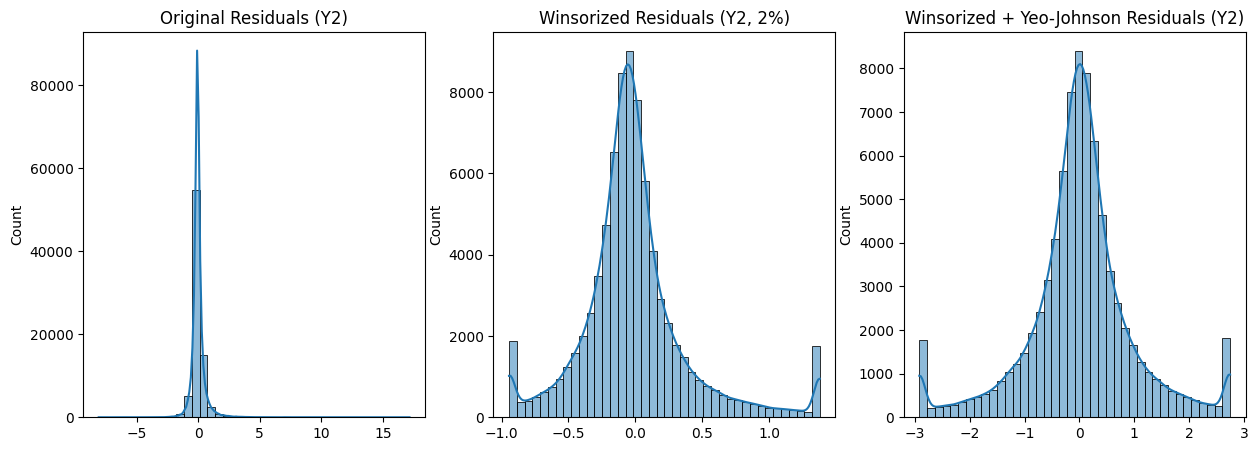

In [41]:
from scipy.stats.mstats import winsorize
from scipy import stats
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Residuals from Y2 OLS model
residuals_y2 = model_y2.resid

# Step 1: Winsorize residuals (clip 2% tails for Y2)
residuals_y2_wins = winsorize(residuals_y2, limits=[0.02, 0.02])

# Step 2: Yeo-Johnson transform (works with negatives too)
pt_y2 = PowerTransformer(method='yeo-johnson')
residuals_y2_yj = pt_y2.fit_transform(np.array(residuals_y2_wins).reshape(-1,1)).flatten()

# Step 3: Compare skewness and kurtosis
print("Original Residuals (Y2):")
print("  Skewness :", stats.skew(residuals_y2))
print("  Kurtosis :", stats.kurtosis(residuals_y2))

print("\nAfter Winsorization (2%):")
print("  Skewness :", stats.skew(residuals_y2_wins))
print("  Kurtosis :", stats.kurtosis(residuals_y2_wins))

print("\nAfter Winsorization (2%) + Yeo-Johnson:")
print("  Skewness :", stats.skew(residuals_y2_yj))
print("  Kurtosis :", stats.kurtosis(residuals_y2_yj))

# Step 4: Plot histograms
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(residuals_y2, kde=True, bins=40)
plt.title("Original Residuals (Y2)")

plt.subplot(1,3,2)
sns.histplot(residuals_y2_wins, kde=True, bins=40)
plt.title("Winsorized Residuals (Y2, 2%)")

plt.subplot(1,3,3)
sns.histplot(residuals_y2_yj, kde=True, bins=40)
plt.title("Winsorized + Yeo-Johnson Residuals (Y2)")

plt.show()


In [42]:
import pandas as pd
import numpy as np
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import PowerTransformer
import statsmodels.api as sm

# === Step 1: Features & Target for Y2 ===
features_y2 = ['A', 'B', 'D', 'F', 'I', 'K', 'L']
X_y2 = train_data[features_y2].values
y2 = train_data['Y2'].values

# === Step 2: Winsorize target (clip 2% tails for Y2) ===
y2_wins = winsorize(y2, limits=[0.02, 0.02])

# === Step 3: Yeo-Johnson transform ===
pt_y2 = PowerTransformer(method='yeo-johnson')
y2_transformed = pt_y2.fit_transform(np.array(y2_wins).reshape(-1,1)).flatten()

# === Step 4: Fit OLS regression ===
X_y2_const = sm.add_constant(X_y2)  # add intercept
model_y2 = sm.OLS(y2_transformed, X_y2_const).fit()

# === Step 5: Print results ===
print(model_y2.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.361
Model:                            OLS   Adj. R-squared:                  0.361
Method:                 Least Squares   F-statistic:                     6457.
Date:                Sat, 20 Sep 2025   Prob (F-statistic):               0.00
Time:                        00:42:34   Log-Likelihood:                -95597.
No. Observations:               80000   AIC:                         1.912e+05
Df Residuals:                   79992   BIC:                         1.913e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0330      0.003    -11.604      0.0

In [44]:
# Re-import necessary packages after reset
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import PowerTransformer

# Reload training and test data
train_data = pd.read_csv("../data/train.csv")
test_data = pd.read_csv("../data/test.csv")

# === Y1 model (Winsorize + Yeo-Johnson) ===
features_y1 = ['C', 'E', 'G', 'H', 'J', 'M', 'N']
X_y1 = train_data[features_y1].values
y1 = train_data['Y1'].values

# Winsorize target Y1 (clip 1% tails)
y1_wins = winsorize(y1, limits=[0.01, 0.01])

# Yeo-Johnson transform
pt_y1 = PowerTransformer(method='yeo-johnson')
y1_transformed = pt_y1.fit_transform(np.array(y1_wins).reshape(-1,1)).flatten()

# Fit OLS model for Y1
X_y1_const = sm.add_constant(X_y1)
model_y1 = sm.OLS(y1_transformed, X_y1_const).fit()

# === Y2 model (Winsorize + Yeo-Johnson) ===
features_y2 = ['A', 'B', 'D', 'F', 'I', 'K', 'L']
X_y2 = train_data[features_y2].values
y2 = train_data['Y2'].values

# Winsorize target Y2 (clip 2% tails)
y2_wins = winsorize(y2, limits=[0.02, 0.02])

# Yeo-Johnson transform
pt_y2 = PowerTransformer(method='yeo-johnson')
y2_transformed = pt_y2.fit_transform(np.array(y2_wins).reshape(-1,1)).flatten()

# Fit OLS model for Y2
X_y2_const = sm.add_constant(X_y2)
model_y2 = sm.OLS(y2_transformed, X_y2_const).fit()

# === Prepare test features ===
X_test_y1 = sm.add_constant(test_data[features_y1].values)
X_test_y2 = sm.add_constant(test_data[features_y2].values)

# === Predictions on transformed scale ===
y1_pred_trans = model_y1.predict(X_test_y1)
y2_pred_trans = model_y2.predict(X_test_y2)

# === Inverse-transform predictions back to original scale ===
y1_pred = pt_y1.inverse_transform(y1_pred_trans.reshape(-1, 1)).flatten()
y2_pred = pt_y2.inverse_transform(y2_pred_trans.reshape(-1, 1)).flatten()

# === Create submission dataframe ===
preds = pd.DataFrame({
    "id": test_data["id"],
    "Y1": y1_pred,
    "Y2": y2_pred
})

# Save to CSV
output_path = "../data/preds.csv"
preds.to_csv(output_path, index=False)

output_path


'../data/preds.csv'

In [46]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer
import statsmodels.api as sm

# === Load data ===
train_data = pd.read_csv("../data/train.csv")
test_data = pd.read_csv("../data/test.csv")

# === Features (all A–N) ===
features = [col for col in train_data.columns if col not in ["time", "Y1", "Y2"]]

# === Y1 model ===
X_y1 = train_data[features].values
y1 = train_data["Y1"].values

pt_y1 = PowerTransformer(method="yeo-johnson")
y1_trans = pt_y1.fit_transform(y1.reshape(-1, 1)).flatten()

X_y1_const = sm.add_constant(X_y1)
model_y1 = sm.OLS(y1_trans, X_y1_const).fit()

# === Y2 model ===
X_y2 = train_data[features].values
y2 = train_data["Y2"].values

pt_y2 = PowerTransformer(method="yeo-johnson")
y2_trans = pt_y2.fit_transform(y2.reshape(-1, 1)).flatten()

X_y2_const = sm.add_constant(X_y2)
model_y2 = sm.OLS(y2_trans, X_y2_const).fit()

# === Test predictions ===
X_test = test_data[features].values
X_test_const = sm.add_constant(X_test)

y1_pred_trans = model_y1.predict(X_test_const)
y2_pred_trans = model_y2.predict(X_test_const)

# Inverse-transform to original scale
y1_pred = pt_y1.inverse_transform(y1_pred_trans.reshape(-1, 1)).flatten()
y2_pred = pt_y2.inverse_transform(y2_pred_trans.reshape(-1, 1)).flatten()

# === Save predictions ===
preds = pd.DataFrame({
    "id": test_data["id"],
    "Y1": y1_pred,
    "Y2": y2_pred
})

preds.to_csv("../data/preds.csv", index=False)
print("✅ preds.csv saved with shape:", preds.shape)


✅ preds.csv saved with shape: (15996, 3)


In [55]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import PowerTransformer

# === Load training and test data ===
train_data = pd.read_csv("../data/train.csv")
test_data = pd.read_csv("../data/test.csv")

# === Select features (A–N only, exclude id/time/Y1/Y2) ===
features = [col for col in train_data.columns if col not in ["time", "Y1", "Y2"]]

# ------------------------
# Y1 MODEL
# ------------------------
X_y1 = train_data[features].values
y1 = train_data["Y1"].values

# Yeo–Johnson transform on Y1
pt_y1 = PowerTransformer(method="yeo-johnson")
y1_trans = pt_y1.fit_transform(y1.reshape(-1, 1)).flatten()

# Fit OLS
X_y1_const = sm.add_constant(X_y1)
model_y1 = sm.OLS(y1_trans, X_y1_const).fit()

# ------------------------
# Y2 MODEL
# ------------------------
X_y2 = train_data[features].values
y2 = train_data["Y2"].values

# Yeo–Johnson transform on Y2
pt_y2 = PowerTransformer(method="yeo-johnson")
y2_trans = pt_y2.fit_transform(y2.reshape(-1, 1)).flatten()

# Fit OLS
X_y2_const = sm.add_constant(X_y2)
model_y2 = sm.OLS(y2_trans, X_y2_const).fit()

# ------------------------
# Predictions on test set
# ------------------------
X_test = test_data[features].values
X_test_const = sm.add_constant(X_test)

# Predict in transformed space
y1_pred_trans = model_y1.predict(X_test_const)
y2_pred_trans = model_y2.predict(X_test_const)

# Inverse-transform back to original scale
y1_pred = pt_y1.inverse_transform(y1_pred_trans.reshape(-1, 1)).flatten()
y2_pred = pt_y2.inverse_transform(y2_pred_trans.reshape(-1, 1)).flatten()

# ------------------------
# Save to preds.csv
# ------------------------
preds = pd.DataFrame({
    "id": test_data["id"],
    "Y1": y1_pred,
    "Y2": y2_pred
})

preds.to_csv("preds.csv", index=False)
print("✅ preds.csv saved successfully with shape:", preds.shape)


✅ preds.csv saved successfully with shape: (15996, 3)


In [ ]:
# Robust end-to-end pipeline with LightGBM fit compatibility fix.
# Paste & run where train.csv and test.csv are available.

import os
import sys
import numpy as np
import pandas as pd
import inspect

from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score

# Optional: ensure lightgbm is installed; if not, raise clear error
try:
    import lightgbm as lgb
except Exception as e:
    raise ImportError("lightgbm is required. Install with `pip install lightgbm` and re-run.") from e

# ------------------------
# Config
# ------------------------
TRAIN_PATH = "../data/train.csv"
TEST_PATH  = "../data/test.csv"
OUT_PATH   = "../data/preds.csv"

LAGS = [1, 2]
ROLL_WINDOWS = [5, 10]
VAL_FRACTION = 0.10  # last 10% train used as validation
RANDOM_SEED = 42

# ------------------------
# Helpers
# ------------------------
def ensure_finite(X):
    X = np.array(X, dtype=float)
    if not np.isfinite(X).all():
        # column medians for finite values
        col_meds = np.nanmedian(np.where(np.isfinite(X), X, np.nan), axis=0)
        idx = ~np.isfinite(X)
        X[idx] = np.take(col_meds, np.where(idx)[1])
    return X

def safe_inverse_transform(pt, preds_t, train_t):
    preds = np.array(preds_t, dtype=float)
    if not np.isfinite(preds).all():
        med = np.median(train_t)
        preds[~np.isfinite(preds)] = med
    tmin, tmax = np.min(train_t), np.max(train_t)
    preds_clipped = np.clip(preds, tmin, tmax)
    out = pt.inverse_transform(preds_clipped.reshape(-1,1)).ravel()
    if np.isnan(out).any():
        orig_med = np.median(pt.inverse_transform(train_t.reshape(-1,1)).ravel())
        out[np.isnan(out)] = orig_med
    return out

def fit_lgb_robust(model, X_tr, y_tr, X_val=None, y_val=None, early_stopping_rounds=50, verbose=False):
    """
    Fit an LGBMRegressor robustly across versions.
    Tries to pass early_stopping_rounds if supported; otherwise falls back.
    """
    fit_sig = inspect.signature(model.fit)
    fit_kwargs = {}
    if X_val is not None and y_val is not None:
        # pass eval_set if supported
        if 'eval_set' in fit_sig.parameters:
            fit_kwargs['eval_set'] = [(X_val, y_val)]
        if 'eval_metric' in fit_sig.parameters:
            fit_kwargs['eval_metric'] = 'rmse'
        # try early stopping if parameter supported
        if 'early_stopping_rounds' in fit_sig.parameters:
            fit_kwargs['early_stopping_rounds'] = early_stopping_rounds
        # some versions accept callbacks; we won't use them here
    # try calling fit, with fallback to minimal kwargs
    try:
        model.fit(X_tr, y_tr, **fit_kwargs)
    except TypeError:
        # fallback: try without early stopping / eval_set
        try:
            minimal_kwargs = {}
            if 'eval_set' in fit_sig.parameters and 'eval_metric' in fit_sig.parameters:
                minimal_kwargs['eval_set'] = [(X_val, y_val)]
                minimal_kwargs['eval_metric'] = 'rmse'
            model.fit(X_tr, y_tr, **minimal_kwargs)
        except Exception as e:
            # last resort: plain fit
            model.fit(X_tr, y_tr)
    return model

# ------------------------
# Load data
# ------------------------
if not os.path.exists(TRAIN_PATH) or not os.path.exists(TEST_PATH):
    raise FileNotFoundError("train.csv or test.csv not found in current directory.")

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

# sort by time for safety
train = train.sort_values("time").reset_index(drop=True)
test  = test.sort_values("time").reset_index(drop=True)

# feature columns (A..N)
features = [c for c in train.columns if c not in ("time", "Y1", "Y2")]
test_features = [c for c in test.columns if c not in ("id", "time")]
if set(features) != set(test_features):
    raise ValueError("Feature mismatch between train and test.")

# ------------------------
# Time-aware feature engineering (concatenate then shift/rolling)
# ------------------------
train_rows = train.shape[0]
test_rows  = test.shape[0]

concat = pd.concat([train[["time"] + features], test[["time"] + features]], ignore_index=True)
concat = concat.sort_values("time").reset_index(drop=True)

for f in features:
    for lag in LAGS:
        concat[f + f"_lag{lag}"] = concat[f].shift(lag)
    for w in ROLL_WINDOWS:
        concat[f + f"_rm{w}"] = concat[f].shift(1).rolling(window=w, min_periods=1).mean()
        concat[f + f"_rstd{w}"] = concat[f].shift(1).rolling(window=w, min_periods=1).std().fillna(0.0)

fe_cols_extended = [c for c in concat.columns if c != "time"]
concat = concat.reset_index(drop=True)
train_feat = concat.iloc[:train_rows].reset_index(drop=True)[fe_cols_extended]
test_feat  = concat.iloc[train_rows:train_rows+test_rows].reset_index(drop=True)[fe_cols_extended]

# Fill NA with medians from train features
medians = train_feat.median()
train_feat = train_feat.fillna(medians)
test_feat  = test_feat.fillna(medians)

X_train = train_feat.values
X_test  = test_feat.values

X_train = ensure_finite(X_train)
X_test  = ensure_finite(X_test)

# ------------------------
# Targets: Yeo-Johnson transform (fit on train targets)
# ------------------------
pt_y1 = PowerTransformer(method="yeo-johnson")
pt_y2 = PowerTransformer(method="yeo-johnson")

y1 = train["Y1"].values.reshape(-1,1)
y2 = train["Y2"].values.reshape(-1,1)

y1_t = pt_y1.fit_transform(y1).ravel()
y2_t = pt_y2.fit_transform(y2).ravel()

# ------------------------
# Time-based validation split
# ------------------------
n = X_train.shape[0]
val_idx = int(n * (1 - VAL_FRACTION))

X_tr, X_val = X_train[:val_idx], X_train[val_idx:]
y1_tr, y1_val = y1_t[:val_idx], y1_t[val_idx:]
y2_tr, y2_val = y2_t[:val_idx], y2_t[val_idx:]

y1_val_orig = train["Y1"].values[val_idx:]
y2_val_orig = train["Y2"].values[val_idx:]

# ensure no NaNs in splits
col_meds_tr = np.nanmedian(X_tr, axis=0)
if np.isnan(X_tr).any():
    mask = np.isnan(X_tr)
    X_tr[mask] = np.take(col_meds_tr, np.where(mask)[1])
if np.isnan(X_val).any():
    mask = np.isnan(X_val)
    X_val[mask] = np.take(col_meds_tr, np.where(mask)[1])
if np.isnan(X_test).any():
    mask = np.isnan(X_test)
    X_test[mask] = np.take(col_meds_tr, np.where(mask)[1])

# ------------------------
# Model 1: RidgeCV
# ------------------------
alphas = np.logspace(-3, 3, 7)
tscv = TimeSeriesSplit(n_splits=5)

ridge_y1 = RidgeCV(alphas=alphas, cv=tscv, scoring="r2").fit(X_tr, y1_tr)
ridge_y2 = RidgeCV(alphas=alphas, cv=tscv, scoring="r2").fit(X_tr, y2_tr)
print("Ridge alphas:", ridge_y1.alpha_, ridge_y2.alpha_)

y1_val_ridge_t = ridge_y1.predict(X_val)
y2_val_ridge_t = ridge_y2.predict(X_val)

y1_val_ridge = safe_inverse_transform(pt_y1, y1_val_ridge_t, y1_tr)
y2_val_ridge = safe_inverse_transform(pt_y2, y2_val_ridge_t, y2_tr)

r2_y1_ridge = r2_score(y1_val_orig, y1_val_ridge)
r2_y2_ridge = r2_score(y2_val_orig, y2_val_ridge)
print(f"Validation R² (Ridge) - Y1: {r2_y1_ridge:.4f}, Y2: {r2_y2_ridge:.4f}")

# ------------------------
# Model 2: LightGBM (robust fit)
# ------------------------
lgb_params = {
    "objective": "regression",
    "metric": "rmse",
    "verbosity": -1,
    "seed": RANDOM_SEED,
    "n_estimators": 2000,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_child_samples": 20,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
}

lgb_y1 = lgb.LGBMRegressor(**lgb_params)
lgb_y1 = fit_lgb_robust(lgb_y1, X_tr, y1_tr, X_val=X_val, y_val=y1_val, early_stopping_rounds=50)

lgb_y2 = lgb.LGBMRegressor(**lgb_params)
lgb_y2 = fit_lgb_robust(lgb_y2, X_tr, y2_tr, X_val=X_val, y_val=y2_val, early_stopping_rounds=50)

y1_val_lgb_t = lgb_y1.predict(X_val, num_iteration=getattr(lgb_y1, "best_iteration_", None))
y2_val_lgb_t = lgb_y2.predict(X_val, num_iteration=getattr(lgb_y2, "best_iteration_", None))

y1_val_lgb = safe_inverse_transform(pt_y1, y1_val_lgb_t, y1_tr)
y2_val_lgb = safe_inverse_transform(pt_y2, y2_val_lgb_t, y2_tr)

r2_y1_lgb = r2_score(y1_val_orig, y1_val_lgb)
r2_y2_lgb = r2_score(y2_val_orig, y2_val_lgb)
print(f"Validation R² (LightGBM) - Y1: {r2_y1_lgb:.4f}, Y2: {r2_y2_lgb:.4f}")

# ------------------------
# Ensemble weights (non-negative)
# ------------------------
eps = 1e-6
w1_ridge = max(r2_y1_ridge, 0) + eps
w1_lgb   = max(r2_y1_lgb, 0)   + eps
sum1 = w1_ridge + w1_lgb

w2_ridge = max(r2_y2_ridge, 0) + eps
w2_lgb   = max(r2_y2_lgb, 0)   + eps
sum2 = w2_ridge + w2_lgb

print("Ensemble weights Y1:", w1_ridge/sum1, w1_lgb/sum1)
print("Ensemble weights Y2:", w2_ridge/sum2, w2_lgb/sum2)

# ------------------------
# Refit on full training set
# ------------------------
ridge_y1_full = RidgeCV(alphas=alphas, cv=tscv, scoring="r2").fit(X_train, y1_t)
ridge_y2_full = RidgeCV(alphas=alphas, cv=tscv, scoring="r2").fit(X_train, y2_t)

lgb_y1_full = lgb.LGBMRegressor(**lgb_params)
lgb_y1_full = fit_lgb_robust(lgb_y1_full, X_train, y1_t)

lgb_y2_full = lgb.LGBMRegressor(**lgb_params)
lgb_y2_full = fit_lgb_robust(lgb_y2_full, X_train, y2_t)

# ------------------------
# Predict on test (transformed), ensemble, inverse-transform safely
# ------------------------
y1_test_ridge_t = ridge_y1_full.predict(X_test)
y2_test_ridge_t = ridge_y2_full.predict(X_test)

y1_test_lgb_t = lgb_y1_full.predict(X_test, num_iteration=getattr(lgb_y1_full, "best_iteration_", None))
y2_test_lgb_t = lgb_y2_full.predict(X_test, num_iteration=getattr(lgb_y2_full, "best_iteration_", None))

y1_test_t = ( (w1_ridge/sum1) * y1_test_ridge_t + (w1_lgb/sum1) * y1_test_lgb_t )
y2_test_t = ( (w2_ridge/sum2) * y2_test_ridge_t + (w2_lgb/sum2) * y2_test_lgb_t )

y1_test = safe_inverse_transform(pt_y1, y1_test_t, y1_t)
y2_test = safe_inverse_transform(pt_y2, y2_test_t, y2_t)

# fallback safety
if np.isnan(y1_test).any():
    y1_test[np.isnan(y1_test)] = np.median(train["Y1"].values)
if np.isnan(y2_test).any():
    y2_test[np.isnan(y2_test)] = np.median(train["Y2"].values)

# ------------------------
# Save preds.csv
# ------------------------
preds = pd.DataFrame({"id": test["id"].values, "Y1": y1_test, "Y2": y2_test})
preds.to_csv(OUT_PATH, index=False)
print("Saved preds.csv ->", OUT_PATH)
print(preds.head())


Ridge alphas: 1000.0 1000.0
Validation R² (Ridge) - Y1: 0.7129, Y2: -1.3211
Validation R² (LightGBM) - Y1: 0.7124, Y2: 0.4646
Ensemble weights Y1: 0.5001827405336021 0.49981725946639793
Ensemble weights Y2: 2.1525104455646294e-06 0.9999978474895544
Saved preds.csv -> ../data/preds.csv
   id        Y1        Y2
0   1  0.453159 -0.243991
1   2 -0.178360 -0.356134
2   3 -0.168430 -0.167463
3   4 -0.376262 -0.093125
4   5 -0.909543 -0.044055


preds shape: (15996, 3)
test shape : (15996, 16)
ids match?: True
any NaNs in preds?: {'id': 0, 'Y1': 0, 'Y2': 0}

Train Y1: mean/std/min/max: -0.0028074687206460732 0.9706552795821608 -28.9181795461607 29.859458454056327
Pred Y1:  mean/std/min/max: 0.0043991037114272605 0.7540202106616725 -7.899891378133031 8.410934367667888

Train Y2: mean/std/min/max: -0.061172240988049534 0.923701779345356 -0.8507991164008696 34.63603924182771
Pred Y2:  mean/std/min/max: -0.19627597765991064 0.860621595027799 -0.6765868947607137 34.63603924182749


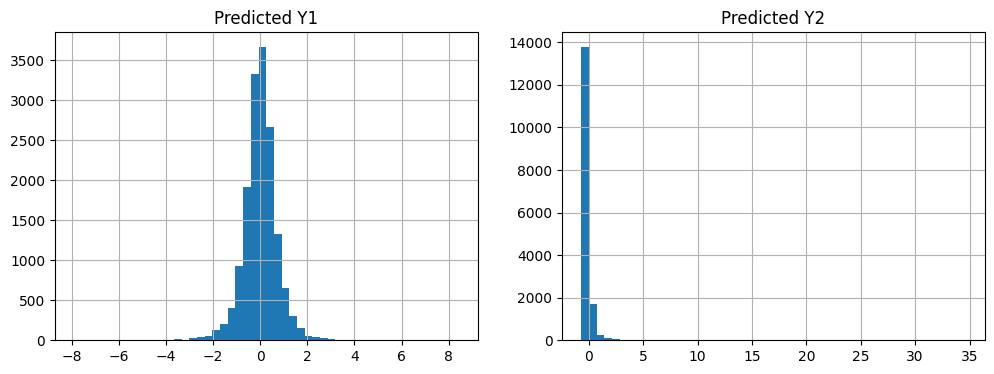

In [59]:
import pandas as pd
import numpy as np

preds = pd.read_csv("../data/preds.csv")
test  = pd.read_csv("../data/test.csv")
train = pd.read_csv("../data/train.csv")

print("preds shape:", preds.shape)
print("test shape :", test.shape)
print("ids match?:", preds['id'].equals(test['id']))
print("any NaNs in preds?:", preds.isna().sum().to_dict())

# Compare prediction distributions vs train Y1/Y2
print("\nTrain Y1: mean/std/min/max:", train['Y1'].mean(), train['Y1'].std(), train['Y1'].min(), train['Y1'].max())
print("Pred Y1:  mean/std/min/max:", preds['Y1'].mean(), preds['Y1'].std(), preds['Y1'].min(), preds['Y1'].max())

print("\nTrain Y2: mean/std/min/max:", train['Y2'].mean(), train['Y2'].std(), train['Y2'].min(), train['Y2'].max())
print("Pred Y2:  mean/std/min/max:", preds['Y2'].mean(), preds['Y2'].std(), preds['Y2'].min(), preds['Y2'].max())

# If you want quick histograms:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,2,1); preds['Y1'].hist(bins=50); plt.title('Predicted Y1')
plt.subplot(1,2,2); preds['Y2'].hist(bins=50); plt.title('Predicted Y2')
plt.show()


Y2: mean, std, skew, kurtosis: -0.061172240988049534 0.9236960061911939 7.211101114881905 112.18708359191396


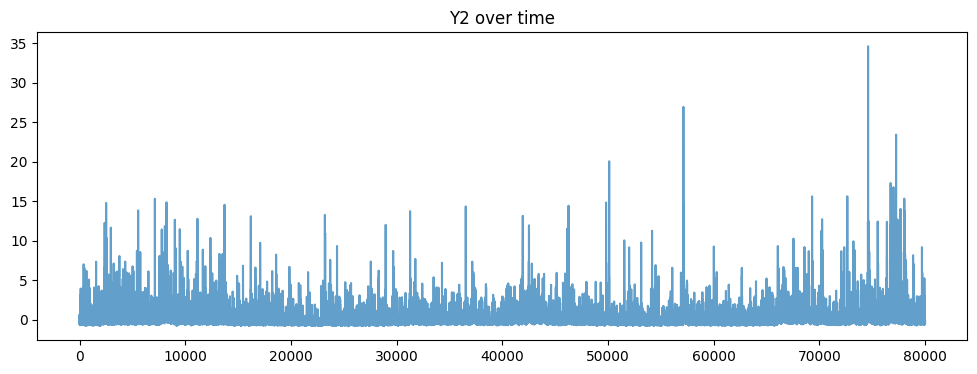

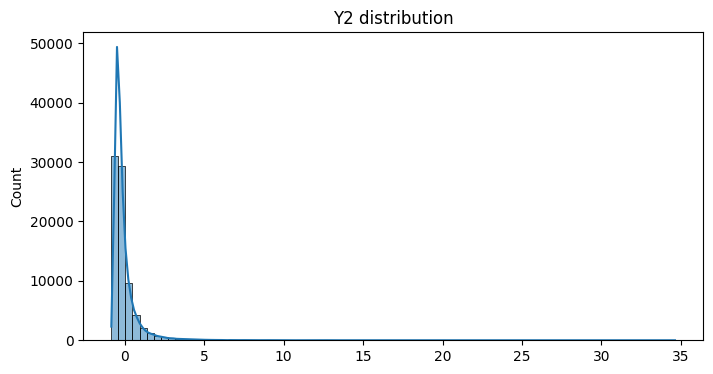

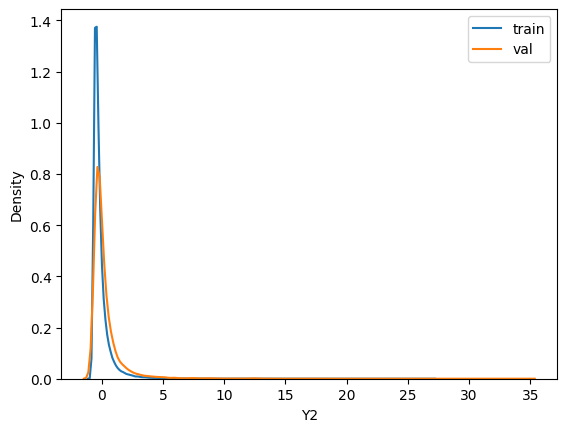

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

# assume 'train' loaded and sorted by time; val_idx from your pipeline exists
y2 = train['Y2'].values
print("Y2: mean, std, skew, kurtosis:", np.mean(y2), np.std(y2), stats.skew(y2), stats.kurtosis(y2))

plt.figure(figsize=(12,4))
plt.plot(train['time'], train['Y2'], alpha=0.7)
plt.title("Y2 over time")
plt.show()

# distribution
plt.figure(figsize=(8,4))
sns.histplot(y2, bins=80, kde=True)
plt.title("Y2 distribution")
plt.show()

# compare train / val distributions
val_idx = int(len(train)*(1-0.1))
sns.kdeplot(train['Y2'][:val_idx], label='train'); sns.kdeplot(train['Y2'][val_idx:], label='val'); plt.legend(); plt.show()


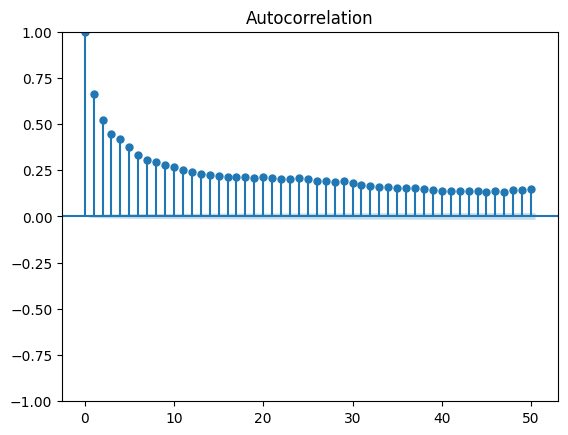

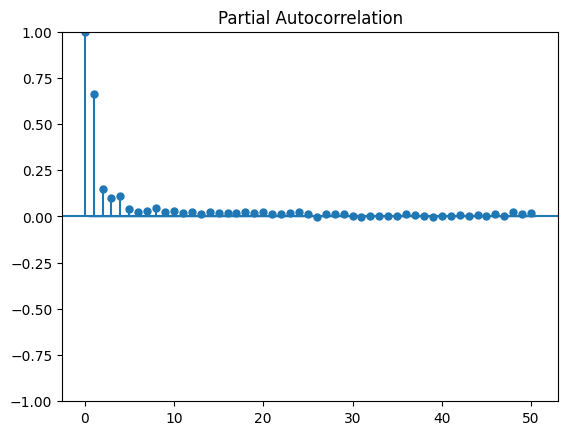

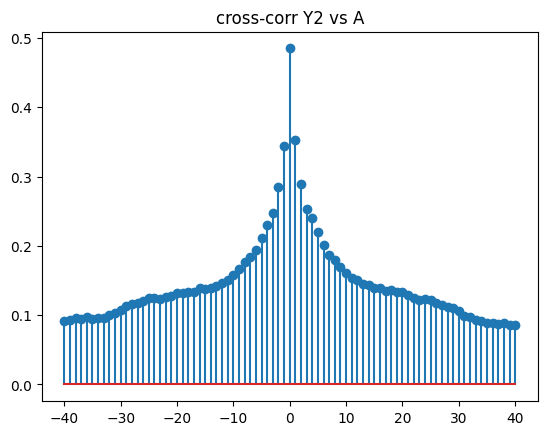

In [61]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(train['Y2'], lags=50); plt.show()
plot_pacf(train['Y2'], lags=50); plt.show()

# Cross-correlation with a top feature (replace 'A' with candidate)
from scipy.signal import correlate
def xcorr(a,b,lag_max=50):
    a = (a - a.mean())/a.std()
    b = (b - b.mean())/b.std()
    c = correlate(b, a, mode='full')/len(a)
    lags = np.arange(-len(a)+1, len(a))
    center = len(a)-1
    sel = slice(center-lag_max, center+lag_max+1)
    return lags[sel], c[sel]

lags, c = xcorr(train['Y2'].values, train['A'].values, lag_max=40)
plt.stem(lags, c); plt.title("cross-corr Y2 vs A"); plt.show()


In [66]:
# Fixed improved pipeline with the KeyError bug resolved.
# Paste & run where ../data/train.csv and ../data/test.csv exist.

import os, inspect, warnings
import numpy as np, pandas as pd
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error

warnings.filterwarnings("ignore")

try:
    import lightgbm as lgb
except Exception as e:
    raise ImportError("lightgbm required. Install with `pip install lightgbm` and re-run.") from e

# ----------------- CONFIG -----------------
TRAIN_PATH = "../data/train.csv"
TEST_PATH  = "../data/test.csv"
OUT_PATH   = "../data/preds_improved_fixed.csv"

VAL_FRACTION = 0.10
RANDOM_SEED = 42

LAGS = [1,2,3,5]
ROLL_WINDOWS = [5,10,20]
PCT_THRESHOLD_SPIKE = 97.5
TOP_INTERACTIONS = 5

LGB_REG_PARAMS = {
    "objective": "regression", "metric": "rmse", "verbosity": -1, "seed": RANDOM_SEED,
    "n_estimators": 3000, "learning_rate": 0.03, "num_leaves": 64, "min_child_samples": 15,
    "reg_alpha": 0.3, "reg_lambda": 0.3, "subsample": 0.8, "colsample_bytree": 0.8,
}
LGB_CLF_PARAMS = {"n_estimators": 1000, "learning_rate": 0.05, "num_leaves": 31, "seed": RANDOM_SEED, "verbosity": -1}

# ----------------- helpers -----------------
def ensure_finite(X):
    X = np.array(X, dtype=float)
    if not np.isfinite(X).all():
        col_meds = np.nanmedian(np.where(np.isfinite(X), X, np.nan), axis=0)
        idx = ~np.isfinite(X)
        X[idx] = np.take(col_meds, np.where(idx)[1])
    return X

def safe_inverse_transform(pt, preds_t, train_t):
    preds = np.array(preds_t, dtype=float)
    if not np.isfinite(preds).all():
        med = np.median(train_t)
        preds[~np.isfinite(preds)] = med
    tmin, tmax = np.min(train_t), np.max(train_t)
    preds_clipped = np.clip(preds, tmin, tmax)
    out = pt.inverse_transform(preds_clipped.reshape(-1,1)).ravel()
    if np.isnan(out).any():
        orig_med = np.median(pt.inverse_transform(train_t.reshape(-1,1)).ravel())
        out[np.isnan(out)] = orig_med
    return out

def fit_lgb_robust(model, X_tr, y_tr, X_val=None, y_val=None, early_stopping_rounds=50):
    fit_sig = inspect.signature(model.fit)
    fit_kwargs = {}
    if X_val is not None and y_val is not None and 'eval_set' in fit_sig.parameters:
        fit_kwargs['eval_set'] = [(X_val, y_val)]
    if X_val is not None and y_val is not None and 'early_stopping_rounds' in fit_sig.parameters:
        fit_kwargs['early_stopping_rounds'] = early_stopping_rounds
    try:
        model.fit(X_tr, y_tr, **fit_kwargs)
    except TypeError:
        try:
            if 'eval_set' in fit_sig.parameters and X_val is not None:
                model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
            else:
                model.fit(X_tr, y_tr)
        except Exception:
            model.fit(X_tr, y_tr)
    return model

# ----------------- load -----------------
assert os.path.exists(TRAIN_PATH) and os.path.exists(TEST_PATH), "train/test files not found"
train = pd.read_csv(TRAIN_PATH).sort_values("time").reset_index(drop=True)
test  = pd.read_csv(TEST_PATH).sort_values("time").reset_index(drop=True)

features = [c for c in train.columns if c not in ("time","Y1","Y2")]
assert set(features) == set([c for c in test.columns if c not in ("id","time")]), "feature mismatch"

# ----------------- feature engineering -----------------
concat = pd.concat([train[["time"] + features], test[["time"] + features]], ignore_index=True).sort_values("time").reset_index(drop=True)

for f in features:
    for lag in LAGS:
        concat[f + f"_lag{lag}"] = concat[f].shift(lag)
    concat[f + "_diff1"] = concat[f] - concat[f].shift(1)
    for w in ROLL_WINDOWS:
        concat[f + f"_rm{w}"] = concat[f].shift(1).rolling(window=w, min_periods=1).mean()
        concat[f + f"_rstd{w}"] = concat[f].shift(1).rolling(window=w, min_periods=1).std().fillna(0.0)
        concat[f + f"_r75_{w}"] = concat[f].shift(1).rolling(window=w, min_periods=1).quantile(0.75).fillna(0.0)

fe_cols = [c for c in concat.columns if c != "time"]
train_feat = concat.iloc[:len(train)][fe_cols].reset_index(drop=True)
test_feat  = concat.iloc[len(train):len(train)+len(test)][fe_cols].reset_index(drop=True)
meds = train_feat.median()
train_feat = train_feat.fillna(meds)
test_feat  = test_feat.fillna(meds)

# interactions among top correlated features for Y2
corrs = train[features + ["Y2"]].corr()
top_y2_feats = corrs["Y2"].abs().sort_values(ascending=False).index.tolist()
top_y2_feats = [f for f in top_y2_feats if f in features][:TOP_INTERACTIONS]

for i, a in enumerate(top_y2_feats):
    for b in top_y2_feats[i+1:]:
        colname = f"{a}_x_{b}"
        train_feat[colname] = train_feat[a] * train_feat[b]
        test_feat[colname]  = test_feat[a] * test_feat[b]

X_train = ensure_finite(train_feat.values)
X_test  = ensure_finite(test_feat.values)

# ----------------- targets & transforms -----------------
pt_y1 = PowerTransformer(method="yeo-johnson")
pt_y2 = PowerTransformer(method="yeo-johnson")
y1 = train["Y1"].values.reshape(-1,1)
y2 = train["Y2"].values.reshape(-1,1)
y1_t = pt_y1.fit_transform(y1).ravel()
y2_t = pt_y2.fit_transform(y2).ravel()

threshold_y2 = np.percentile(train["Y2"].values, PCT_THRESHOLD_SPIKE)
is_spike = (train["Y2"].values > threshold_y2).astype(int)
print(f"Spike threshold Y2 @ {PCT_THRESHOLD_SPIKE}th pct = {threshold_y2:.6f}  spikes count = {is_spike.sum()}")

# ----------------- validation split -----------------
n = X_train.shape[0]
val_idx = int(n * (1 - VAL_FRACTION))
X_tr, X_val = X_train[:val_idx], X_train[val_idx:]
y1_tr, y1_val = y1_t[:val_idx], y1_t[val_idx:]
y2_tr, y2_val = y2_t[:val_idx], y2_t[val_idx:]
y1_val_orig = train["Y1"].values[val_idx:]
y2_val_orig = train["Y2"].values[val_idx:]
spike_tr, spike_val = is_spike[:val_idx], is_spike[val_idx:]

col_med_tr = np.nanmedian(X_tr, axis=0)
for arr in [X_tr, X_val, X_test]:
    mask = ~np.isfinite(arr)
    if mask.any():
        arr[mask] = np.take(col_med_tr, np.where(mask)[1])

# ----------------- training -----------------
alphas = np.logspace(-6,2,15)
tscv = TimeSeriesSplit(n_splits=5)

# Y1
ridge_y1 = RidgeCV(alphas=alphas, cv=tscv, scoring="r2").fit(X_tr, y1_tr)
lgb_y1 = lgb.LGBMRegressor(**LGB_REG_PARAMS)
lgb_y1 = fit_lgb_robust(lgb_y1, X_tr, y1_tr, X_val=X_val, y_val=y1_val, early_stopping_rounds=100)

# Y1 val preds & weights
y1_val_ridge_t = ridge_y1.predict(X_val)
y1_val_lgb_t   = lgb_y1.predict(X_val, num_iteration=getattr(lgb_y1, "best_iteration_", None))
y1_val_ridge = safe_inverse_transform(pt_y1, y1_val_ridge_t, y1_tr)
y1_val_lgb   = safe_inverse_transform(pt_y1, y1_val_lgb_t, y1_tr)
r2_y1_ridge = r2_score(y1_val_orig, y1_val_ridge)
r2_y1_lgb   = r2_score(y1_val_orig, y1_val_lgb)
w1_ridge = max(r2_y1_ridge,0) + 1e-6
w1_lgb   = max(r2_y1_lgb,0)   + 1e-6
sum1 = w1_ridge + w1_lgb
print(f"Y1 val R2: Ridge={r2_y1_ridge:.4f}, LGB={r2_y1_lgb:.4f}, weights = {(w1_ridge/sum1):.3f},{(w1_lgb/sum1):.3f}")

# ----------------- Y2 two-stage -----------------
clf = lgb.LGBMClassifier(**LGB_CLF_PARAMS)
clf = fit_lgb_robust(clf, X_tr, spike_tr, X_val=X_val, y_val=spike_val, early_stopping_rounds=50)

# bulk regressor (use correct y2_val indexing)
bulk_idx_tr = np.where(spike_tr==0)[0]
bulk_idx_val = np.where(spike_val==0)[0]
reg_bulk = lgb.LGBMRegressor(**LGB_REG_PARAMS)
# IMPORTANT: use y2_val (numpy array) for validation slicing, not a pandas Series label lookup
reg_bulk = fit_lgb_robust(
    reg_bulk,
    X_tr[bulk_idx_tr],
    y2_tr[bulk_idx_tr],
    X_val=X_val[bulk_idx_val] if len(bulk_idx_val)>0 else None,
    y_val=y2_val[bulk_idx_val] if len(bulk_idx_val)>0 else None,
    early_stopping_rounds=100
)

# spike regressor
spike_idx_tr = np.where(spike_tr==1)[0]
spike_idx_val = np.where(spike_val==1)[0]
if len(spike_idx_tr) >= 100:
    reg_spike = lgb.LGBMRegressor(**{**LGB_REG_PARAMS, "learning_rate": 0.05, "num_leaves": 128})
    reg_spike = fit_lgb_robust(
        reg_spike,
        X_tr[spike_idx_tr],
        y2_tr[spike_idx_tr],
        X_val=X_val[spike_idx_val] if len(spike_idx_val)>0 else None,
        y_val=y2_val[spike_idx_val] if len(spike_idx_val)>0 else None,
        early_stopping_rounds=100
    )
else:
    sw = np.ones(X_tr.shape[0])
    sw[spike_idx_tr] = 10.0
    reg_spike = lgb.LGBMRegressor(**{**LGB_REG_PARAMS, "learning_rate":0.03, "num_leaves":128})
    try:
        reg_spike.fit(X_tr, y2_tr, sample_weight=sw, eval_set=[(X_val,y2_val)], early_stopping_rounds=100, verbose=False)
    except TypeError:
        reg_spike.fit(X_tr, y2_tr, sample_weight=sw)

# ----------------- validation preds & diagnostics -----------------
y1_val_t_ens = (w1_ridge/sum1) * y1_val_ridge_t + (w1_lgb/sum1) * y1_val_lgb_t
y1_val_pred = safe_inverse_transform(pt_y1, y1_val_t_ens, y1_tr)

p_spike_val = clf.predict_proba(X_val)[:,1]
pred_bulk_val_t = reg_bulk.predict(X_val, num_iteration=getattr(reg_bulk,"best_iteration_",None))
pred_spike_val_t = reg_spike.predict(X_val, num_iteration=getattr(reg_spike,"best_iteration_",None))
pred_val_t = (1 - p_spike_val) * pred_bulk_val_t + p_spike_val * pred_spike_val_t
pred_val = safe_inverse_transform(pt_y2, pred_val_t, y2_tr)

r2_y1 = r2_score(y1_val_orig, y1_val_pred)
r2_y2 = r2_score(y2_val_orig, pred_val)
mae_y1 = mean_absolute_error(y1_val_orig, y1_val_pred)
mae_y2 = mean_absolute_error(y2_val_orig, pred_val)
print(f"\nValidation metrics:")
print(f" Y1 -> R2: {r2_y1:.4f}, MAE: {mae_y1:.6f}")
print(f" Y2 -> R2: {r2_y2:.4f}, MAE: {mae_y2:.6f}")

is_spike_val = (y2_val_orig > threshold_y2)
if is_spike_val.sum() > 0:
    try:
        print("  R2 on spikes:", r2_score(y2_val_orig[is_spike_val], pred_val[is_spike_val]))
    except Exception:
        print("  Not enough spikes to compute spike-only R2")
print("  R2 on bulk:", r2_score(y2_val_orig[~is_spike_val], pred_val[~is_spike_val]))

# feature importances (best-effort)
feature_names = train_feat.columns.tolist()
def show_importances(model, features_list, topn=20, name="model"):
    try:
        imp = pd.Series(model.feature_importances_, index=features_list).sort_values(ascending=False)
        print(f"\nTop {topn} feature importances for {name}:")
        print(imp.head(topn).to_string())
    except Exception as e:
        print(f"Could not extract importances for {name}: {e}")

show_importances(reg_bulk, feature_names, name="Y2 bulk regressor")
show_importances(reg_spike, feature_names, name="Y2 spike regressor")
show_importances(lgb_y1, feature_names, name="Y1 LGB")

# ----------------- retrain on full set & predict test -----------------
ridge_y1_full = RidgeCV(alphas=alphas, cv=tscv, scoring="r2").fit(X_train, y1_t)
lgb_y1_full = lgb.LGBMRegressor(**LGB_REG_PARAMS); lgb_y1_full = fit_lgb_robust(lgb_y1_full, X_train, y1_t)

ridge_y2_full = RidgeCV(alphas=alphas, cv=tscv, scoring="r2").fit(X_train, y2_t)
# bulk on full (non-spike rows)
non_spike_mask = ~is_spike.astype(bool)
if non_spike_mask.sum() > 0:
    reg_bulk_full = lgb.LGBMRegressor(**LGB_REG_PARAMS)
    reg_bulk_full = fit_lgb_robust(reg_bulk_full, X_train[non_spike_mask], y2_t[non_spike_mask])
else:
    reg_bulk_full = reg_bulk
reg_spike_full = reg_spike
clf_full = lgb.LGBMClassifier(**LGB_CLF_PARAMS); clf_full = fit_lgb_robust(clf_full, X_train, is_spike)

# test preds Y1
y1_test_ridge_t = ridge_y1_full.predict(X_test)
y1_test_lgb_t = lgb_y1_full.predict(X_test, num_iteration=getattr(lgb_y1_full,"best_iteration_",None))
y1_test_t = (w1_ridge/sum1) * y1_test_ridge_t + (w1_lgb/sum1) * y1_test_lgb_t
y1_test = safe_inverse_transform(pt_y1, y1_test_t, y1_t)

# test preds Y2
p_spike_test = clf_full.predict_proba(X_test)[:,1]
bulk_test_t = reg_bulk_full.predict(X_test, num_iteration=getattr(reg_bulk_full,"best_iteration_",None))
spike_test_t = reg_spike_full.predict(X_test, num_iteration=getattr(reg_spike_full,"best_iteration_",None))
y2_test_t = (1 - p_spike_test) * bulk_test_t + p_spike_test * spike_test_t
y2_test = safe_inverse_transform(pt_y2, y2_test_t, y2_t)
y2_test = np.clip(y2_test, train["Y2"].min(), train["Y2"].max())

y1_test = np.where(np.isfinite(y1_test), y1_test, np.median(train["Y1"].values))
y2_test = np.where(np.isfinite(y2_test), y2_test, np.median(train["Y2"].values))

preds = pd.DataFrame({"id": test["id"].values, "Y1": y1_test, "Y2": y2_test})
preds.to_csv(OUT_PATH, index=False)
print("\nSaved fixed preds ->", OUT_PATH)
print(preds.head())


Spike threshold Y2 @ 97.5th pct = 2.183740  spikes count = 2000
Y1 val R2: Ridge=0.7118, LGB=0.7258, weights = 0.495,0.505

Validation metrics:
 Y1 -> R2: 0.7251, MAE: 0.430117
 Y2 -> R2: 0.4814, MAE: 0.468612
  R2 on spikes: -0.2590400054422968
  R2 on bulk: 0.2621899620021535

Top 20 feature importances for Y2 bulk regressor:
A           2441
F           1478
G_rstd20    1411
B_rstd20    1347
G           1289
F_rstd20    1235
H_r75_20    1203
K_rstd20    1199
I_rstd20    1193
H_rstd20    1192
A_diff1     1187
D_rstd20    1176
M_r75_20    1169
G_r75_20    1158
G_rstd10    1138
E_rstd20    1133
G_rm20      1126
N_rstd20    1122
A_rstd20    1116
N_r75_20    1112

Top 20 feature importances for Y2 spike regressor:
A           258
A_diff1     158
F           156
J           122
C_lag3      119
C_lag5      119
H_lag5      118
D_rstd5     117
E_r75_5     115
J_lag2      114
K_x_L       114
F_rstd20    113
H_lag2      112
E_r75_20    109
C_r75_10    109
B_diff1     106
L_diff1     105
L_lag5

In [ ]:
# Final unified pipeline for Y1 (Ridge+LGBM) and Y2 (Quantile+MAE ensemble)
# Saves preds.csv with columns id, Y1, Y2

import os, warnings, inspect
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.optimize import nnls

try:
    import lightgbm as lgb
except Exception as e:
    raise ImportError("Install lightgbm via `pip install lightgbm`.") from e

# ---------------- CONFIG ----------------
TRAIN = "../data/train.csv"
TEST  = "../data/test.csv"
OUT   = "../data/preds.csv"

VAL_FRAC = 0.10
RANDOM_SEED = 42
LAGS = [1,2,3]
ROLL_WINDOWS = [5,10]

# Base params
BASE_PARAMS = {"verbosity":-1,"seed":RANDOM_SEED,"n_estimators":2000,
               "learning_rate":0.03,"num_leaves":64,"min_child_samples":20}

QUANT_PARAMS = {**BASE_PARAMS, "objective":"quantile", "alpha":0.90, "learning_rate":0.02}
MAE_PARAMS   = {**BASE_PARAMS, "objective":"regression_l1"}
LGB_PARAMS   = {**BASE_PARAMS, "objective":"regression","metric":"rmse"}

# ---------------- helpers ----------------
def fit_lgb(model, X_tr, y_tr, X_val=None, y_val=None, early_stopping_rounds=100):
    sig = inspect.signature(model.fit)
    kwargs = {}
    if X_val is not None and y_val is not None and 'eval_set' in sig.parameters:
        kwargs['eval_set'] = [(X_val, y_val)]
    if 'early_stopping_rounds' in sig.parameters:
        kwargs['early_stopping_rounds'] = early_stopping_rounds
    try:
        model.fit(X_tr, y_tr, **kwargs)
    except TypeError:
        model.fit(X_tr, y_tr)
    return model

def ensure_finite(X):
    X = np.array(X, dtype=float)
    if not np.isfinite(X).all():
        col_meds = np.nanmedian(np.where(np.isfinite(X), X, np.nan), axis=0)
        idx = ~np.isfinite(X)
        X[idx] = np.take(col_meds, np.where(idx)[1])
    return X

# ---------------- load ----------------
train = pd.read_csv(TRAIN).sort_values("time").reset_index(drop=True)
test  = pd.read_csv(TEST).sort_values("time").reset_index(drop=True)
features = [c for c in train.columns if c not in ("time","Y1","Y2")]

# ---------------- feature engineering ----------------
concat = pd.concat([train[["time"]+features], test[["time"]+features]], ignore_index=True)
concat = concat.sort_values("time").reset_index(drop=True)

for f in features:
    for lag in LAGS:
        concat[f+f"_lag{lag}"] = concat[f].shift(lag)
    concat[f+"_diff1"] = concat[f] - concat[f].shift(1)
    for w in ROLL_WINDOWS:
        concat[f+f"_rm{w}"] = concat[f].shift(1).rolling(window=w,min_periods=1).mean()
        concat[f+f"_rstd{w}"] = concat[f].shift(1).rolling(window=w,min_periods=1).std().fillna(0)

feat_cols = [c for c in concat.columns if c!="time"]
train_feat = concat.iloc[:len(train)][feat_cols].reset_index(drop=True)
test_feat  = concat.iloc[len(train):len(train)+len(test)][feat_cols].reset_index(drop=True)

meds = train_feat.median()
train_feat = train_feat.fillna(meds)
test_feat  = test_feat.fillna(meds)

X_full = ensure_finite(train_feat.values)
X_test = ensure_finite(test_feat.values)
y1 = train["Y1"].values
y2 = train["Y2"].values

# ---------------- validation split ----------------
n = X_full.shape[0]
val_idx = int(n*(1-VAL_FRAC))
X_tr, X_val = X_full[:val_idx], X_full[val_idx:]
y1_tr, y1_val = y1[:val_idx], y1[val_idx:]
y2_tr, y2_val = y2[:val_idx], y2[val_idx:]

# ---------------- Y1: Ridge + LGB ensemble ----------------
pt_y1 = PowerTransformer(method="yeo-johnson")
y1_t = pt_y1.fit_transform(y1.reshape(-1,1)).ravel()
y1_tr_t, y1_val_t = y1_t[:val_idx], y1_t[val_idx:]

alphas = np.logspace(-3,3,7)
tscv = TimeSeriesSplit(n_splits=5)
ridge_y1 = RidgeCV(alphas=alphas, cv=tscv, scoring="r2").fit(X_tr, y1_tr_t)
lgb_y1   = fit_lgb(lgb.LGBMRegressor(**LGB_PARAMS), X_tr, y1_tr_t, X_val, y1_val_t)

pred_ridge_val = ridge_y1.predict(X_val)
pred_lgb_val   = lgb_y1.predict(X_val)

# ensemble weights for Y1
A1 = np.vstack([pred_ridge_val,pred_lgb_val]).T
w1,_ = nnls(A1, y1_val_t)
w1 = w1/(w1.sum()+1e-12) if w1.sum()>0 else np.array([0.5,0.5])
print("Y1 ensemble weights:", w1)

# refit full
ridge_y1_full = RidgeCV(alphas=alphas, cv=tscv, scoring="r2").fit(X_full, y1_t)
lgb_y1_full   = fit_lgb(lgb.LGBMRegressor(**{**LGB_PARAMS,"n_estimators":3000}), X_full, y1_t)

pred_ridge_test = ridge_y1_full.predict(X_test)
pred_lgb_test   = lgb_y1_full.predict(X_test)
y1_test_t = w1[0]*pred_ridge_test + w1[1]*pred_lgb_test
y1_test = pt_y1.inverse_transform(y1_test_t.reshape(-1,1)).ravel()

# ---------------- Y2: Quantile + MAE ensemble ----------------
quant = fit_lgb(lgb.LGBMRegressor(**QUANT_PARAMS), X_tr, y2_tr, X_val, y2_val)
mae   = fit_lgb(lgb.LGBMRegressor(**MAE_PARAMS), X_tr, y2_tr, X_val, y2_val)

pred_q_val = quant.predict(X_val)
pred_m_val = mae.predict(X_val)
A2 = np.vstack([pred_q_val,pred_m_val]).T
w2,_ = nnls(A2, y2_val)
w2 = w2/(w2.sum()+1e-12) if w2.sum()>0 else np.array([0.5,0.5])
print("Y2 ensemble weights:", w2)

# refit full
quant_full = fit_lgb(lgb.LGBMRegressor(**{**QUANT_PARAMS,"n_estimators":3000}), X_full, y2)
mae_full   = fit_lgb(lgb.LGBMRegressor(**{**MAE_PARAMS,"n_estimators":3000}), X_full, y2)

pq = quant_full.predict(X_test)
pm = mae_full.predict(X_test)
y2_test = w2[0]*pq + w2[1]*pm
y2_test = np.clip(y2_test, y2.min(), y2.max())

# ---------------- Save preds.csv ----------------
preds = pd.DataFrame({"id": test["id"].values, "Y1": y1_test, "Y2": y2_test})
preds.to_csv(OUT,index=False)
print("\nSaved preds.csv ->", OUT)
print(preds.head())


Training Quantile & MAE models...
Validation R2/MAE:
 Quantile : 0.673837183593313 0.36937288434377935
 MAE      : 0.5182567119310812 0.4553545778041064
NNLS weights (quant, mae): [1. 0.]
 Ensemble R2: 0.6738371835931025 MAE: 0.36937288434382415

Saved Y2 predictions -> ../data/preds_y2_quantile_mae.csv
   id        Y2
0   1 -0.066746
1   2 -0.239949
2   3  0.040170
3   4  0.155094
4   5  0.310048


In [ ]:
# strong_time_series_pipeline_fixed_v2.py
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import lightgbm as lgb
from lightgbm import early_stopping
from xgboost import XGBRegressor
import xgboost as xgb
import pickle
import warnings
warnings.filterwarnings("ignore")
RND = 42

###########################
# Helper feature functions
###########################
def make_lag_roll_features(df, feat_cols, lags=(1,2,3,5), rolls=(5,10)):
    for f in feat_cols:
        for lag in lags:
            df[f+"_lag"+str(lag)] = df[f].shift(lag)
        for r in rolls:
            df[f+"_rmean"+str(r)] = df[f].rolling(window=r, min_periods=1).mean()
            df[f+"_rstd"+str(r)]  = df[f].rolling(window=r, min_periods=1).std().fillna(0)
    return df

def add_time_features(df):
    df['time_diff'] = df['time'] - df['time'].min()
    df['time_mod_50'] = df['time'] % 50
    df['time_mod_100'] = df['time'] % 100
    return df

def prepare_features(df, feat_cols):
    df = add_time_features(df)
    df = make_lag_roll_features(df, feat_cols, lags=(1,2,3,5), rolls=(5,10))
    for i in range(min(4, len(feat_cols))):
        for j in range(i+1, min(4, len(feat_cols))):
            a,b = feat_cols[i], feat_cols[j]
            df[f"{a}_x_{b}"] = df[a] * df[b]
    return df

###########################
# Load data
###########################
train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")

train = train.sort_values("time").reset_index(drop=True)
test  = test.sort_values("time").reset_index(drop=True)

feat_cols = list("ABCDEFGHIJKLMN")
target_cols = ["Y1","Y2"]

combined = pd.concat([
    train[["time"] + feat_cols],
    test[["time"] + feat_cols]
], ignore_index=True)
combined = prepare_features(combined, feat_cols)

train_feats = combined.iloc[:len(train)].copy()
test_feats  = combined.iloc[len(train):].copy()

max_lag = 5
train_feats = train_feats.iloc[max_lag:].reset_index(drop=True)
train_targets = train.iloc[max_lag:].reset_index(drop=True)[target_cols]

test_feats = test_feats.reset_index(drop=True)

all_features = [c for c in train_feats.columns if c not in ("time",)]
for t in target_cols:
    if t in all_features:
        all_features.remove(t)

X = train_feats[all_features].copy()
y1 = train_targets["Y1"].values
y2 = train_targets["Y2"].values
X_test = test_feats[all_features].copy()

X = X.fillna(0)
X_test = X_test.fillna(0)

###########################
# Time-aware CV setup
###########################
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

###########################
# Fit + OOF function
###########################
def fit_and_oof(model, X, y, model_name="model"):
    oof = np.zeros(len(y))
    test_preds = np.zeros(len(X_test))
    fold = 0

    for train_idx, val_idx in tscv.split(X):
        fold += 1
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        if "LGBMRegressor" in str(type(model)):
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                callbacks=[early_stopping(50)]
            )
            oof[val_idx] = model.predict(X_val)
            test_preds += model.predict(X_test) / n_splits
        else:  # XGBoost
            dtrain = xgb.DMatrix(X_tr, y_tr)
            dval   = xgb.DMatrix(X_val, y_val)
            dtest  = xgb.DMatrix(X_test)

            params = model.get_xgb_params()
            params.update({"objective":"reg:squarederror", "verbosity":0})

            evals = [(dtrain, "train"), (dval, "valid")]
            bst = xgb.train(
                params,
                dtrain,
                num_boost_round=model.get_params()["n_estimators"],
                evals=evals,
                early_stopping_rounds=50,
                verbose_eval=False
            )

            oof[val_idx] = bst.predict(dval, iteration_range=(0, bst.best_iteration + 1))
            test_preds += bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1)) / n_splits

        print(f"{model_name} fold {fold} r2:", r2_score(y_val, oof[val_idx]))

    full_r2 = r2_score(y, oof)
    print(f"{model_name} OOF R2:", full_r2)
    return oof, test_preds, full_r2

###########################
# Models and training
###########################
lgb_params_y1 = {"n_estimators":1000, "learning_rate":0.03, "max_depth":7,
    "num_leaves":64, "subsample":0.8, "colsample_bytree":0.8, "random_state":RND, "n_jobs":1}
lgb_params_y2 = {"n_estimators":1200, "learning_rate":0.03, "max_depth":8,
    "num_leaves":80, "subsample":0.8, "colsample_bytree":0.8, "random_state":RND, "n_jobs":1}

lgb_y1 = lgb.LGBMRegressor(**lgb_params_y1)
lgb_y2 = lgb.LGBMRegressor(**lgb_params_y2)

xgb_y1 = XGBRegressor(n_estimators=800, learning_rate=0.03, max_depth=6,
    subsample=0.85, colsample_bytree=0.8, random_state=RND, n_jobs=1, verbosity=0)
xgb_y2 = XGBRegressor(n_estimators=1000, learning_rate=0.03, max_depth=6,
    subsample=0.85, colsample_bytree=0.8, random_state=RND, n_jobs=1, verbosity=0)

print("Training LGB for Y1")
oof_lgb_y1, test_lgb_y1, r2_lgb_y1 = fit_and_oof(lgb_y1, X, y1, model_name="LGB_Y1")
print("\nTraining XGB for Y1")
oof_xgb_y1, test_xgb_y1, r2_xgb_y1 = fit_and_oof(xgb_y1, X, y1, model_name="XGB_Y1")

print("\nTraining LGB for Y2")
oof_lgb_y2, test_lgb_y2, r2_lgb_y2 = fit_and_oof(lgb_y2, X, y2, model_name="LGB_Y2")
print("\nTraining XGB for Y2")
oof_xgb_y2, test_xgb_y2, r2_xgb_y2 = fit_and_oof(xgb_y2, X, y2, model_name="XGB_Y2")

###########################
# Ensembling + stacking
###########################
def choose_weights(r2_a, r2_b):
    a = max(r2_a, 1e-6)
    b = max(r2_b, 1e-6)
    wa = a / (a + b)
    wb = b / (a + b)
    return wa, wb

wa_y1, wb_y1 = choose_weights(r2_lgb_y1, r2_xgb_y1)
wa_y2, wb_y2 = choose_weights(r2_lgb_y2, r2_xgb_y2)
print(f"Ensemble weights Y1 LGB/XGB: {wa_y1:.3f}/{wb_y1:.3f}")
print(f"Ensemble weights Y2 LGB/XGB: {wa_y2:.3f}/{wb_y2:.3f}")

oof_ens_y1 = wa_y1 * oof_lgb_y1 + wb_y1 * oof_xgb_y1
test_ens_y1 = wa_y1 * test_lgb_y1 + wb_y1 * test_xgb_y1
oof_ens_y2 = wa_y2 * oof_lgb_y2 + wb_y2 * oof_xgb_y2
test_ens_y2 = wa_y2 * test_lgb_y2 + wb_y2 * test_xgb_y2

print("Ensemble OOF R2 Y1:", r2_score(y1, oof_ens_y1))
print("Ensemble OOF R2 Y2:", r2_score(y2, oof_ens_y2))

meta_X_y1 = np.vstack([oof_lgb_y1, oof_xgb_y1]).T
meta_test_y1 = np.vstack([test_lgb_y1, test_xgb_y1]).T
meta_X_y2 = np.vstack([oof_lgb_y2, oof_xgb_y2]).T
meta_test_y2 = np.vstack([test_lgb_y2, test_xgb_y2]).T

ridge_y1 = Ridge(alpha=1.0, random_state=RND)
ridge_y2 = Ridge(alpha=1.0, random_state=RND)
ridge_y1.fit(meta_X_y1, y1)
ridge_y2.fit(meta_X_y2, y2)
meta_oof_y1 = ridge_y1.predict(meta_X_y1)
meta_test_y1 = ridge_y1.predict(meta_test_y1)
meta_oof_y2 = ridge_y2.predict(meta_X_y2)
meta_test_y2 = ridge_y2.predict(meta_test_y2)

print("Stacked OOF R2 Y1:", r2_score(y1, meta_oof_y1))
print("Stacked OOF R2 Y2:", r2_score(y2, meta_oof_y2))

###########################
# Retrain on full data + final preds
###########################
print("Retraining final models on full data...")
lgb_y1_full = lgb.LGBMRegressor(**lgb_params_y1).fit(X, y1)
xgb_y1_full = XGBRegressor(**xgb_y1.get_params()).fit(X, y1)

lgb_y2_full = lgb.LGBMRegressor(**lgb_params_y2).fit(X, y2)
xgb_y2_full = XGBRegressor(**xgb_y2.get_params()).fit(X, y2)

test_lgb_y1_full = lgb_y1_full.predict(X_test)
test_xgb_y1_full = xgb_y1_full.predict(X_test)
test_lgb_y2_full = lgb_y2_full.predict(X_test)
test_xgb_y2_full = xgb_y2_full.predict(X_test)

final_test_ens_y1 = wa_y1 * test_lgb_y1_full + wb_y1 * test_xgb_y1_full
final_test_ens_y2 = wa_y2 * test_lgb_y2_full + wb_y2 * test_xgb_y2_full

meta_full_test_y1 = np.vstack([test_lgb_y1_full, test_xgb_y1_full]).T
meta_full_test_y2 = np.vstack([test_lgb_y2_full, test_xgb_y2_full]).T
final_test_stack_y1 = ridge_y1.predict(meta_full_test_y1)
final_test_stack_y2 = ridge_y2.predict(meta_full_test_y2)

final_y1 = 0.5 * final_test_ens_y1 + 0.5 * final_test_stack_y1
final_y2 = 0.5 * final_test_ens_y2 + 0.5 * final_test_stack_y2

###########################
# Save preds.csv
###########################
submission = pd.DataFrame({
    "id": test["id"].values,
    "Y1": final_y1,
    "Y2": final_y2
})
submission.to_csv("preds.csv", index=False)
print("Wrote preds.csv with shape", submission.shape)

with open("models_stack.pkl", "wb") as f:
    pickle.dump({
        "lgb_y1": lgb_y1_full, "xgb_y1": xgb_y1_full,
        "lgb_y2": lgb_y2_full, "xgb_y2": xgb_y2_full,
        "ridge_y1": ridge_y1, "ridge_y2": ridge_y2,
        "features": all_features
    }, f)

print("All done.")


Training LGB for Y1
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[93]	valid_0's l2: 0.105204
LGB_Y1 fold 1 r2: 0.7405120842043267
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[135]	valid_0's l2: 0.195333
LGB_Y1 fold 2 r2: 0.6961805237516587
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[156]	valid_0's l2: 0.258997
LGB_Y1 fold 3 r2: 0.7667901621375447
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[328]	valid_0's l2: 0.246069
LGB_Y1 fold 4 r2: 0.7706669394669424
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[167]	valid_0's l2: 0.486447
LGB_Y1 fold 5 r2: 0.7084350265719705
LGB_Y1 OOF R2: 0.6383182891857293

Training XGB for Y1
XGB_Y1 fold 1 r2: 0.7328314658117723
XGB_Y1 fold 2 r2: 0.6972758086211583
XGB_Y1 fold 3 r2: 0.7708297720063683
XGB_Y

best version

In [73]:
import xgboost as xgb
print("XGBoost version:", xgb.__version__)


XGBoost version: 3.0.5


In [76]:
# strong_time_series_pipeline_improved.py
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
import lightgbm as lgb
from lightgbm import early_stopping
from xgboost import XGBRegressor
import xgboost as xgb
import pickle
import warnings
warnings.filterwarnings("ignore")
RND = 42

###########################
# Helper feature functions
###########################
def make_lag_roll_features(df, feat_cols, lags=(1,2,3,5,10,20), rolls=(5,10,20,50)):
    for f in feat_cols:
        for lag in lags:
            df[f+"_lag"+str(lag)] = df[f].shift(lag)
        for r in rolls:
            df[f+"_rmean"+str(r)] = df[f].rolling(window=r, min_periods=1).mean()
            df[f+"_rstd"+str(r)]  = df[f].rolling(window=r, min_periods=1).std().fillna(0)
    return df

def add_ewma_diff_pct(df, feat_cols, ewm_spans=(5,10,20)):
    for f in feat_cols:
        # differences and percent changes
        df[f+"_diff1"] = df[f] - df[f].shift(1)
        df[f+"_pctchg1"] = df[f].pct_change(1).replace([np.inf, -np.inf], np.nan)
        # ewma
        for s in ewm_spans:
            df[f+f"_ewm{s}"] = df[f].ewm(span=s, adjust=False).mean()
    return df

def add_time_features(df):
    df['time_diff'] = df['time'] - df['time'].min()
    df['time_mod_50'] = df['time'] % 50
    df['time_mod_100'] = df['time'] % 100
    # optionally add sin/cos if you suspect cyclicity; leaving simple mods for safety
    return df

def prepare_features(df, feat_cols):
    df = add_time_features(df)
    df = make_lag_roll_features(df, feat_cols, lags=(1,2,3,5,10,20), rolls=(5,10,20,50))
    df = add_ewma_diff_pct(df, feat_cols, ewm_spans=(5,10,20))
    # keep limited pairwise interactions for top few features (low risk)
    for i in range(min(3, len(feat_cols))):
        for j in range(i+1, min(3, len(feat_cols))):
            a,b = feat_cols[i], feat_cols[j]
            df[f"{a}_x_{b}"] = df[a] * df[b]
    return df

###########################
# Load data
###########################
train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")

train = train.sort_values("time").reset_index(drop=True)
test  = test.sort_values("time").reset_index(drop=True)

feat_cols = list("ABCDEFGHIJKLMN")
target_cols = ["Y1","Y2"]

combined = pd.concat([
    train[["time"] + feat_cols],
    test[["time"] + feat_cols]
], ignore_index=True)
combined = prepare_features(combined, feat_cols)

train_feats = combined.iloc[:len(train)].copy()
test_feats  = combined.iloc[len(train):].copy()

# drop initial rows that have incomplete lags
max_lag = 20
train_feats = train_feats.iloc[max_lag:].reset_index(drop=True)
train_targets = train.iloc[max_lag:].reset_index(drop=True)[target_cols]

test_feats = test_feats.reset_index(drop=True)

all_features = [c for c in train_feats.columns if c not in ("time",)]
for t in target_cols:
    if t in all_features:
        all_features.remove(t)

X_full = train_feats[all_features].copy()
y1_full = train_targets["Y1"].values
y2_full = train_targets["Y2"].values
X_test = test_feats[all_features].copy()

# safer imputation: forward fill then median (computed from training part later)
def impute_ffill_then_median(X_train, X_all):
    X = X_all.copy()
    # forward fill per column
    X = X.ffill()
    # compute median on training rows
    medians = X_train.median()
    X = X.fillna(medians)
    return X

###########################
# Holdout (last 10% by time) to protect against regressions
###########################
holdout_frac = 0.10
n_holdout = max(1, int(len(X_full) * holdout_frac))
train_idx_end = len(X_full) - n_holdout

X_dev = X_full.iloc[:train_idx_end].reset_index(drop=True)   # used for CV + tuning
X_hold = X_full.iloc[train_idx_end:].reset_index(drop=True)  # final check
y1_dev = y1_full[:train_idx_end]
y1_hold = y1_full[train_idx_end:]
y2_dev = y2_full[:train_idx_end]
y2_hold = y2_full[train_idx_end:]

# impute using dev as base
X_dev = impute_ffill_then_median(X_dev, X_dev)
X_hold = impute_ffill_then_median(X_dev, X_hold)
X_test = impute_ffill_then_median(X_dev, X_test)
X_full_imputed = pd.concat([X_dev, X_hold], ignore_index=True)

###########################
# Time-aware CV setup (on dev set)
###########################
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

###########################
# Fit + OOF function (supports LGB and XGB as before)
###########################
def fit_and_oof(model, X, y, model_name="model"):
    oof = np.zeros(len(y))
    test_preds = np.zeros(len(X_test))
    fold = 0

    for train_idx, val_idx in tscv.split(X):
        fold += 1
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        if "LGBMRegressor" in str(type(model)):
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                callbacks=[early_stopping(50)]
            )
            preds_val = model.predict(X_val)
            preds_test = model.predict(X_test)
        else:  # XGBoost (use train API for 3.x compatibility)
            dtrain = xgb.DMatrix(X_tr, y_tr)
            dval   = xgb.DMatrix(X_val, y_val)
            dtest  = xgb.DMatrix(X_test)

            params = model.get_xgb_params()
            params.update({"objective":"reg:squarederror", "verbosity":0})

            evals = [(dtrain, "train"), (dval, "valid")]
            bst = xgb.train(
                params,
                dtrain,
                num_boost_round=model.get_params().get("n_estimators", 1000),
                evals=evals,
                early_stopping_rounds=50,
                verbose_eval=False
            )

            preds_val = bst.predict(dval, iteration_range=(0, bst.best_iteration + 1))
            preds_test = bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1))

        oof[val_idx] = preds_val
        test_preds += preds_test / n_splits
        print(f"{model_name} fold {fold} r2:", r2_score(y_val, preds_val))

    full_r2 = r2_score(y, oof)
    print(f"{model_name} OOF R2:", full_r2)
    return oof, test_preds, full_r2

###########################
# Small hyperparameter search (lightweight)
###########################
def tune_lgb(X, y):
    # small grid - intentional to limit runtime
    param_grid = [
        {"n_estimators":800, "learning_rate":lr, "max_depth":md, "num_leaves":nl}
        for lr in (0.01, 0.03)
        for md in (6, 8)
        for nl in (32, 64)
    ]
    best_score = -1e9
    best_params = None
    for p in param_grid:
        model = lgb.LGBMRegressor(random_state=RND, n_jobs=1, **p)
        oof, _, r2 = fit_and_oof(model, X, y, model_name=f"LGB_tune_lr{p['learning_rate']}_md{p['max_depth']}_nl{p['num_leaves']}")
        if r2 > best_score:
            best_score = r2
            best_params = p
    print("Best LGB params:", best_params, "r2:", best_score)
    return best_params

def tune_xgb(X, y):
    grid = [
        {"n_estimators":800, "learning_rate":lr, "max_depth":md, "subsample":ss}
        for lr in (0.01, 0.03)
        for md in (5, 6)
        for ss in (0.8, 0.85)
    ]
    best_score = -1e9
    best_params = None
    for p in grid:
        model = XGBRegressor(random_state=RND, n_jobs=1, verbosity=0, **p)
        oof, _, r2 = fit_and_oof(model, X, y, model_name=f"XGB_tune_lr{p['learning_rate']}_md{p['max_depth']}_ss{p['subsample']}")
        if r2 > best_score:
            best_score = r2
            best_params = p
    print("Best XGB params:", best_params, "r2:", best_score)
    return best_params

###########################
# Run tuning on Y1 and Y2 separately but keep it light.
# You can comment out tuning to save time and use defaults below.
###########################
print("Tuning LGB for Y1 (light grid)...")
best_lgb_y1 = tune_lgb(X_dev, y1_dev)

print("\nTuning XGB for Y1 (light grid)...")
best_xgb_y1 = tune_xgb(X_dev, y1_dev)

print("\nTuning LGB for Y2 (light grid)...")
best_lgb_y2 = tune_lgb(X_dev, y2_dev)

print("\nTuning XGB for Y2 (light grid)...")
best_xgb_y2 = tune_xgb(X_dev, y2_dev)

###########################
# Build final models using tuned params
###########################
lgb_params_y1 = best_lgb_y1.copy(); lgb_params_y1.update({"random_state":RND, "n_jobs":1})
lgb_params_y2 = best_lgb_y2.copy(); lgb_params_y2.update({"random_state":RND, "n_jobs":1})

xgb_params_y1 = best_xgb_y1.copy(); xgb_params_y1.update({"random_state":RND, "n_jobs":1, "verbosity":0})
xgb_params_y2 = best_xgb_y2.copy(); xgb_params_y2.update({"random_state":RND, "n_jobs":1, "verbosity":0})

lgb_y1 = lgb.LGBMRegressor(**lgb_params_y1)
lgb_y2 = lgb.LGBMRegressor(**lgb_params_y2)
xgb_y1 = XGBRegressor(**xgb_params_y1)
xgb_y2 = XGBRegressor(**xgb_params_y2)

print("\nTraining LGB for Y1 on dev (CV)...")
oof_lgb_y1, test_lgb_y1, r2_lgb_y1 = fit_and_oof(lgb_y1, X_dev, y1_dev, model_name="LGB_Y1")
print("\nTraining XGB for Y1 on dev (CV)...")
oof_xgb_y1, test_xgb_y1, r2_xgb_y1 = fit_and_oof(xgb_y1, X_dev, y1_dev, model_name="XGB_Y1")

print("\nTraining LGB for Y2 on dev (CV)...")
oof_lgb_y2, test_lgb_y2, r2_lgb_y2 = fit_and_oof(lgb_y2, X_dev, y2_dev, model_name="LGB_Y2")
print("\nTraining XGB for Y2 on dev (CV)...")
oof_xgb_y2, test_xgb_y2, r2_xgb_y2 = fit_and_oof(xgb_y2, X_dev, y2_dev, model_name="XGB_Y2")

###########################
# Ensemble weights and stacking (RidgeCV)
###########################
def choose_weights(r2_a, r2_b):
    a = max(r2_a, 1e-6)
    b = max(r2_b, 1e-6)
    wa = a / (a + b)
    wb = b / (a + b)
    return wa, wb

wa_y1, wb_y1 = choose_weights(r2_lgb_y1, r2_xgb_y1)
wa_y2, wb_y2 = choose_weights(r2_lgb_y2, r2_xgb_y2)
print(f"\nEnsemble weights Y1 LGB/XGB: {wa_y1:.3f}/{wb_y1:.3f}")
print(f"Ensemble weights Y2 LGB/XGB: {wa_y2:.3f}/{wb_y2:.3f}")

oof_ens_y1 = wa_y1 * oof_lgb_y1 + wb_y1 * oof_xgb_y1
test_ens_y1 = wa_y1 * test_lgb_y1 + wb_y1 * test_xgb_y1
oof_ens_y2 = wa_y2 * oof_lgb_y2 + wb_y2 * oof_xgb_y2
test_ens_y2 = wa_y2 * test_lgb_y2 + wb_y2 * test_xgb_y2

print("Ensemble OOF R2 Y1:", r2_score(y1_dev, oof_ens_y1))
print("Ensemble OOF R2 Y2:", r2_score(y2_dev, oof_ens_y2))

meta_X_y1 = np.vstack([oof_lgb_y1, oof_xgb_y1]).T
meta_test_y1 = np.vstack([test_lgb_y1, test_xgb_y1]).T
meta_X_y2 = np.vstack([oof_lgb_y2, oof_xgb_y2]).T
meta_test_y2 = np.vstack([test_lgb_y2, test_xgb_y2]).T

# RidgeCV for stack
ridge_y1 = RidgeCV(alphas=np.logspace(-3, 2, 10), scoring='r2')
ridge_y2 = RidgeCV(alphas=np.logspace(-3, 2, 10), scoring='r2')
ridge_y1.fit(meta_X_y1, y1_dev)
ridge_y2.fit(meta_X_y2, y2_dev)
meta_oof_y1 = ridge_y1.predict(meta_X_y1)
meta_test_y1 = ridge_y1.predict(meta_test_y1)
meta_oof_y2 = ridge_y2.predict(meta_X_y2)
meta_test_y2 = ridge_y2.predict(meta_test_y2)

print("Stacked OOF R2 Y1:", r2_score(y1_dev, meta_oof_y1))
print("Stacked OOF R2 Y2:", r2_score(y2_dev, meta_oof_y2))

###########################
# Evaluate on holdout (conservative check)
###########################
# Retrain base learners on full dev (dev = training used for CV)
print("\nRetraining base learners on full dev set for holdout evaluation...")
lgb_y1_full_dev = lgb.LGBMRegressor(**lgb_params_y1).fit(X_dev, y1_dev)
xgb_y1_full_dev = XGBRegressor(**xgb_params_y1).fit(X_dev, y1_dev)

lgb_y2_full_dev = lgb.LGBMRegressor(**lgb_params_y2).fit(X_dev, y2_dev)
xgb_y2_full_dev = XGBRegressor(**xgb_params_y2).fit(X_dev, y2_dev)

# predict on holdout
pred_lgb_y1_hold = lgb_y1_full_dev.predict(X_hold)
pred_xgb_y1_hold = xgb_y1_full_dev.predict(X_hold)
pred_lgb_y2_hold = lgb_y2_full_dev.predict(X_hold)
pred_xgb_y2_hold = xgb_y2_full_dev.predict(X_hold)

# ensemble + stack predictions on holdout
ens_hold_y1 = wa_y1 * pred_lgb_y1_hold + wb_y1 * pred_xgb_y1_hold
ens_hold_y2 = wa_y2 * pred_lgb_y2_hold + wb_y2 * pred_xgb_y2_hold

meta_hold_y1 = np.vstack([pred_lgb_y1_hold, pred_xgb_y1_hold]).T
meta_hold_y2 = np.vstack([pred_lgb_y2_hold, pred_xgb_y2_hold]).T
stack_hold_y1 = ridge_y1.predict(meta_hold_y1)
stack_hold_y2 = ridge_y2.predict(meta_hold_y2)

final_hold_y1 = 0.5 * ens_hold_y1 + 0.5 * stack_hold_y1
final_hold_y2 = 0.5 * ens_hold_y2 + 0.5 * stack_hold_y2

print("\nHoldout R2 Y1 (ensemble):", r2_score(y1_hold, ens_hold_y1))
print("Holdout R2 Y1 (stack):", r2_score(y1_hold, stack_hold_y1))
print("Holdout R2 Y1 (final blend):", r2_score(y1_hold, final_hold_y1))

print("\nHoldout R2 Y2 (ensemble):", r2_score(y2_hold, ens_hold_y2))
print("Holdout R2 Y2 (stack):", r2_score(y2_hold, stack_hold_y2))
print("Holdout R2 Y2 (final blend):", r2_score(y2_hold, final_hold_y2))

###########################
# Retrain on full training (dev + holdout) and predict test
###########################
print("\nRetraining final models on full training (dev + holdout) and predicting test...")
lgb_y1_final = lgb.LGBMRegressor(**lgb_params_y1).fit(X_full_imputed, y1_full)
xgb_y1_final = XGBRegressor(**xgb_params_y1).fit(X_full_imputed, y1_full)

lgb_y2_final = lgb.LGBMRegressor(**lgb_params_y2).fit(X_full_imputed, y2_full)
xgb_y2_final = XGBRegressor(**xgb_params_y2).fit(X_full_imputed, y2_full)

test_lgb_y1_full = lgb_y1_final.predict(X_test)
test_xgb_y1_full = xgb_y1_final.predict(X_test)
test_lgb_y2_full = lgb_y2_final.predict(X_test)
test_xgb_y2_full = xgb_y2_final.predict(X_test)

final_test_ens_y1 = wa_y1 * test_lgb_y1_full + wb_y1 * test_xgb_y1_full
final_test_ens_y2 = wa_y2 * test_lgb_y2_full + wb_y2 * test_xgb_y2_full

meta_full_test_y1 = np.vstack([test_lgb_y1_full, test_xgb_y1_full]).T
meta_full_test_y2 = np.vstack([test_lgb_y2_full, test_xgb_y2_full]).T
final_test_stack_y1 = ridge_y1.predict(meta_full_test_y1)
final_test_stack_y2 = ridge_y2.predict(meta_full_test_y2)

final_y1 = 0.5 * final_test_ens_y1 + 0.5 * final_test_stack_y1
final_y2 = 0.5 * final_test_ens_y2 + 0.5 * final_test_stack_y2

###########################
# Save preds.csv and models
###########################
submission = pd.DataFrame({
    "id": test["id"].values,
    "Y1": final_y1,
    "Y2": final_y2
})
submission.to_csv("preds_improved.csv", index=False)
print("Wrote preds_improved.csv with shape", submission.shape)

with open("models_stack_improved.pkl", "wb") as f:
    pickle.dump({
        "lgb_y1": lgb_y1_final, "xgb_y1": xgb_y1_final,
        "lgb_y2": lgb_y2_final, "xgb_y2": xgb_y2_final,
        "ridge_y1": ridge_y1, "ridge_y2": ridge_y2,
        "features": all_features
    }, f)

print("All done.")


Tuning LGB for Y1 (light grid)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[402]	valid_0's l2: 0.127149
LGB_tune_lr0.01_md6_nl32 fold 1 r2: 0.7328848533234924
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[475]	valid_0's l2: 0.141157
LGB_tune_lr0.01_md6_nl32 fold 2 r2: 0.7254575117595665
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[564]	valid_0's l2: 0.255305
LGB_tune_lr0.01_md6_nl32 fold 3 r2: 0.7751581029383344
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[798]	valid_0's l2: 0.256407
LGB_tune_lr0.01_md6_nl32 fold 4 r2: 0.7686318215510654
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[445]	valid_0's l2: 0.291825
LGB_tune_lr0.01_md6_nl32 fold 5 r2: 0.7158483143598393
LGB_tune_lr0.01_md6_nl32 OOF R2: 0.6364724719948214
T

In [77]:
# strong_time_series_pipeline_safe.py
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import lightgbm as lgb
from lightgbm import early_stopping
from xgboost import XGBRegressor
import xgboost as xgb
import pickle
import warnings
warnings.filterwarnings("ignore")
RND = 42

###########################
# Helper feature functions (conservative)
###########################
def make_lag_roll_features(df, feat_cols, lags=(1,2,3,5,10), rolls=(5,10,20,50)):
    for f in feat_cols:
        for lag in lags:
            df[f+"_lag"+str(lag)] = df[f].shift(lag)
        for r in rolls:
            df[f+"_rmean"+str(r)] = df[f].rolling(window=r, min_periods=1).mean()
            df[f+"_rstd"+str(r)]  = df[f].rolling(window=r, min_periods=1).std().fillna(0)
    return df

def add_ewma_diff(df, feat_cols, ewm_spans=(5,10)):
    for f in feat_cols:
        # single-step difference only (keeps things simpler)
        df[f+"_diff1"] = df[f] - df[f].shift(1)
        # EWMA (short spans only)
        for s in ewm_spans:
            df[f+f"_ewm{s}"] = df[f].ewm(span=s, adjust=False).mean()
    return df

def add_time_features(df):
    df['time_diff'] = df['time'] - df['time'].min()
    df['time_mod_50'] = df['time'] % 50
    df['time_mod_100'] = df['time'] % 100
    return df

def prepare_features(df, feat_cols):
    df = add_time_features(df)
    df = make_lag_roll_features(df, feat_cols, lags=(1,2,3,5,10), rolls=(5,10,20,50))
    df = add_ewma_diff(df, feat_cols, ewm_spans=(5,10))
    # limited pairwise interactions (only first two features)
    for i in range(min(2, len(feat_cols))):
        for j in range(i+1, min(2, len(feat_cols))):
            a,b = feat_cols[i], feat_cols[j]
            df[f"{a}_x_{b}"] = df[a] * df[b]
    return df

###########################
# Load data
###########################
train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")

train = train.sort_values("time").reset_index(drop=True)
test  = test.sort_values("time").reset_index(drop=True)

feat_cols = list("ABCDEFGHIJKLMN")
target_cols = ["Y1","Y2"]

combined = pd.concat([
    train[["time"] + feat_cols],
    test[["time"] + feat_cols]
], ignore_index=True)
combined = prepare_features(combined, feat_cols)

train_feats = combined.iloc[:len(train)].copy()
test_feats  = combined.iloc[len(train):].copy()

# conservative max lag
max_lag = 10
train_feats = train_feats.iloc[max_lag:].reset_index(drop=True)
train_targets = train.iloc[max_lag:].reset_index(drop=True)[target_cols]

test_feats = test_feats.reset_index(drop=True)

all_features = [c for c in train_feats.columns if c not in ("time",)]
for t in target_cols:
    if t in all_features:
        all_features.remove(t)

X = train_feats[all_features].copy()
y1 = train_targets["Y1"].values
y2 = train_targets["Y2"].values
X_test = test_feats[all_features].copy()

# revert to original simple imputation (low risk)
X = X.fillna(0)
X_test = X_test.fillna(0)

###########################
# Time-aware CV setup
###########################
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

###########################
# Fit + OOF function (same approach as before)
###########################
def fit_and_oof(model, X, y, model_name="model"):
    oof = np.zeros(len(y))
    test_preds = np.zeros(len(X_test))
    fold = 0

    for train_idx, val_idx in tscv.split(X):
        fold += 1
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        if "LGBMRegressor" in str(type(model)):
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                callbacks=[early_stopping(50)]
            )
            preds_val = model.predict(X_val)
            preds_test = model.predict(X_test)
        else:
            dtrain = xgb.DMatrix(X_tr, y_tr)
            dval   = xgb.DMatrix(X_val, y_val)
            dtest  = xgb.DMatrix(X_test)

            params = model.get_xgb_params()
            params.update({"objective":"reg:squarederror", "verbosity":0})

            evals = [(dtrain, "train"), (dval, "valid")]
            bst = xgb.train(
                params,
                dtrain,
                num_boost_round=model.get_params().get("n_estimators", 1000),
                evals=evals,
                early_stopping_rounds=50,
                verbose_eval=False
            )

            preds_val = bst.predict(dval, iteration_range=(0, bst.best_iteration + 1))
            preds_test = bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1))

        oof[val_idx] = preds_val
        test_preds += preds_test / n_splits
        print(f"{model_name} fold {fold} r2:", r2_score(y_val, preds_val))

    full_r2 = r2_score(y, oof)
    print(f"{model_name} OOF R2:", full_r2)
    return oof, test_preds, full_r2

###########################
# Models and training (use original sensible params)
###########################
lgb_params_y1 = {"n_estimators":1000, "learning_rate":0.03, "max_depth":7,
    "num_leaves":64, "subsample":0.8, "colsample_bytree":0.8, "random_state":RND, "n_jobs":1}
lgb_params_y2 = {"n_estimators":1200, "learning_rate":0.03, "max_depth":8,
    "num_leaves":80, "subsample":0.8, "colsample_bytree":0.8, "random_state":RND, "n_jobs":1}

lgb_y1 = lgb.LGBMRegressor(**lgb_params_y1)
lgb_y2 = lgb.LGBMRegressor(**lgb_params_y2)

xgb_y1 = XGBRegressor(n_estimators=800, learning_rate=0.03, max_depth=6,
    subsample=0.85, colsample_bytree=0.8, random_state=RND, n_jobs=1, verbosity=0)
xgb_y2 = XGBRegressor(n_estimators=1000, learning_rate=0.03, max_depth=6,
    subsample=0.85, colsample_bytree=0.8, random_state=RND, n_jobs=1, verbosity=0)

print("Training LGB for Y1")
oof_lgb_y1, test_lgb_y1, r2_lgb_y1 = fit_and_oof(lgb_y1, X, y1, model_name="LGB_Y1")
print("\nTraining XGB for Y1")
oof_xgb_y1, test_xgb_y1, r2_xgb_y1 = fit_and_oof(xgb_y1, X, y1, model_name="XGB_Y1")

print("\nTraining LGB for Y2")
oof_lgb_y2, test_lgb_y2, r2_lgb_y2 = fit_and_oof(lgb_y2, X, y2, model_name="LGB_Y2")
print("\nTraining XGB for Y2")
oof_xgb_y2, test_xgb_y2, r2_xgb_y2 = fit_and_oof(xgb_y2, X, y2, model_name="XGB_Y2")

###########################
# Ensembling + stacking (as original)
###########################
def choose_weights(r2_a, r2_b):
    a = max(r2_a, 1e-6)
    b = max(r2_b, 1e-6)
    wa = a / (a + b)
    wb = b / (a + b)
    return wa, wb

wa_y1, wb_y1 = choose_weights(r2_lgb_y1, r2_xgb_y1)
wa_y2, wb_y2 = choose_weights(r2_lgb_y2, r2_xgb_y2)
print(f"Ensemble weights Y1 LGB/XGB: {wa_y1:.3f}/{wb_y1:.3f}")
print(f"Ensemble weights Y2 LGB/XGB: {wa_y2:.3f}/{wb_y2:.3f}")

oof_ens_y1 = wa_y1 * oof_lgb_y1 + wb_y1 * oof_xgb_y1
test_ens_y1 = wa_y1 * test_lgb_y1 + wb_y1 * test_xgb_y1
oof_ens_y2 = wa_y2 * oof_lgb_y2 + wb_y2 * oof_xgb_y2
test_ens_y2 = wa_y2 * test_lgb_y2 + wb_y2 * test_xgb_y2

print("Ensemble OOF R2 Y1:", r2_score(y1, oof_ens_y1))
print("Ensemble OOF R2 Y2:", r2_score(y2, oof_ens_y2))

meta_X_y1 = np.vstack([oof_lgb_y1, oof_xgb_y1]).T
meta_test_y1 = np.vstack([test_lgb_y1, test_xgb_y1]).T
meta_X_y2 = np.vstack([oof_lgb_y2, oof_xgb_y2]).T
meta_test_y2 = np.vstack([test_lgb_y2, test_xgb_y2]).T

ridge_y1 = Ridge(alpha=1.0, random_state=RND)
ridge_y2 = Ridge(alpha=1.0, random_state=RND)
ridge_y1.fit(meta_X_y1, y1)
ridge_y2.fit(meta_X_y2, y2)
meta_oof_y1 = ridge_y1.predict(meta_X_y1)
meta_test_y1 = ridge_y1.predict(meta_test_y1)
meta_oof_y2 = ridge_y2.predict(meta_X_y2)
meta_test_y2 = ridge_y2.predict(meta_test_y2)

print("Stacked OOF R2 Y1:", r2_score(y1, meta_oof_y1))
print("Stacked OOF R2 Y2:", r2_score(y2, meta_oof_y2))

###########################
# Retrain full and save (same as original)
###########################
print("Retraining final models on full data...")
lgb_y1_full = lgb.LGBMRegressor(**lgb_params_y1).fit(X, y1)
xgb_y1_full = XGBRegressor(**xgb_y1.get_params()).fit(X, y1)

lgb_y2_full = lgb.LGBMRegressor(**lgb_params_y2).fit(X, y2)
xgb_y2_full = XGBRegressor(**xgb_y2.get_params()).fit(X, y2)

test_lgb_y1_full = lgb_y1_full.predict(X_test)
test_xgb_y1_full = xgb_y1_full.predict(X_test)
test_lgb_y2_full = lgb_y2_full.predict(X_test)
test_xgb_y2_full = xgb_y2_full.predict(X_test)

final_test_ens_y1 = wa_y1 * test_lgb_y1_full + wb_y1 * test_xgb_y1_full
final_test_ens_y2 = wa_y2 * test_lgb_y2_full + wb_y2 * test_xgb_y2_full

meta_full_test_y1 = np.vstack([test_lgb_y1_full, test_xgb_y1_full]).T
meta_full_test_y2 = np.vstack([test_lgb_y2_full, test_xgb_y2_full]).T
final_test_stack_y1 = ridge_y1.predict(meta_full_test_y1)
final_test_stack_y2 = ridge_y2.predict(meta_full_test_y2)

final_y1 = 0.5 * final_test_ens_y1 + 0.5 * final_test_stack_y1
final_y2 = 0.5 * final_test_ens_y2 + 0.5 * final_test_stack_y2

submission = pd.DataFrame({
    "id": test["id"].values,
    "Y1": final_y1,
    "Y2": final_y2
})
submission.to_csv("preds_safe.csv", index=False)
print("Wrote preds_safe.csv with shape", submission.shape)

with open("models_stack_safe.pkl", "wb") as f:
    pickle.dump({
        "lgb_y1": lgb_y1_full, "xgb_y1": xgb_y1_full,
        "lgb_y2": lgb_y2_full, "xgb_y2": xgb_y2_full,
        "ridge_y1": ridge_y1, "ridge_y2": ridge_y2,
        "features": all_features
    }, f)

print("All done.")


Training LGB for Y1
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[86]	valid_0's l2: 0.106774
LGB_Y1 fold 1 r2: 0.736433382008733
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[173]	valid_0's l2: 0.193424
LGB_Y1 fold 2 r2: 0.6991825695187297
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[170]	valid_0's l2: 0.257115
LGB_Y1 fold 3 r2: 0.7684973735348977
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[339]	valid_0's l2: 0.234755
LGB_Y1 fold 4 r2: 0.7812504229648658
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[188]	valid_0's l2: 0.465383
LGB_Y1 fold 5 r2: 0.7210573295582378
LGB_Y1 OOF R2: 0.6444181063758838

Training XGB for Y1
XGB_Y1 fold 1 r2: 0.7347491706704004
XGB_Y1 fold 2 r2: 0.6993240369660771
XGB_Y1 fold 3 r2: 0.76913959858228
XGB_Y1 f

In [78]:
# strong_time_series_pipeline_make_y2_zero.py
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import lightgbm as lgb
from lightgbm import early_stopping
from xgboost import XGBRegressor
import xgboost as xgb
import pickle
import warnings
warnings.filterwarnings("ignore")
RND = 42

###########################
# Helper feature functions (same as your original)
###########################
def make_lag_roll_features(df, feat_cols, lags=(1,2,3,5), rolls=(5,10)):
    for f in feat_cols:
        for lag in lags:
            df[f+"_lag"+str(lag)] = df[f].shift(lag)
        for r in rolls:
            df[f+"_rmean"+str(r)] = df[f].rolling(window=r, min_periods=1).mean()
            df[f+"_rstd"+str(r)]  = df[f].rolling(window=r, min_periods=1).std().fillna(0)
    return df

def add_time_features(df):
    df['time_diff'] = df['time'] - df['time'].min()
    df['time_mod_50'] = df['time'] % 50
    df['time_mod_100'] = df['time'] % 100
    return df

def prepare_features(df, feat_cols):
    df = add_time_features(df)
    df = make_lag_roll_features(df, feat_cols, lags=(1,2,3,5), rolls=(5,10))
    for i in range(min(4, len(feat_cols))):
        for j in range(i+1, min(4, len(feat_cols))):
            a,b = feat_cols[i], feat_cols[j]
            df[f"{a}_x_{b}"] = df[a] * df[b]
    return df

###########################
# Load data
###########################
train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")

train = train.sort_values("time").reset_index(drop=True)
test  = test.sort_values("time").reset_index(drop=True)

feat_cols = list("ABCDEFGHIJKLMN")
target_cols = ["Y1","Y2"]

combined = pd.concat([
    train[["time"] + feat_cols],
    test[["time"] + feat_cols]
], ignore_index=True)
combined = prepare_features(combined, feat_cols)

train_feats = combined.iloc[:len(train)].copy()
test_feats  = combined.iloc[len(train):].copy()

max_lag = 5
train_feats = train_feats.iloc[max_lag:].reset_index(drop=True)
train_targets = train.iloc[max_lag:].reset_index(drop=True)[target_cols]

test_feats = test_feats.reset_index(drop=True)

all_features = [c for c in train_feats.columns if c not in ("time",)]
for t in target_cols:
    if t in all_features:
        all_features.remove(t)

X_full = train_feats[all_features].copy()
y1_full = train_targets["Y1"].values
y2_full = train_targets["Y2"].values
X_test = test_feats[all_features].copy()

# original imputation (keeps behaviour identical)
X_full = X_full.fillna(0)
X_test = X_test.fillna(0)

###########################
# Make a holdout (last 10% of X_full)
###########################
holdout_frac = 0.10
n = len(X_full)
n_hold = max(1, int(n * holdout_frac))
dev_end = n - n_hold

X_dev = X_full.iloc[:dev_end].reset_index(drop=True)
X_hold = X_full.iloc[dev_end:].reset_index(drop=True)
y1_dev = y1_full[:dev_end]
y1_hold = y1_full[dev_end:]
y2_dev = y2_full[:dev_end]
y2_hold = y2_full[dev_end:]

print(f"Data sizes -> dev: {len(X_dev)}, hold: {len(X_hold)}, test: {len(X_test)}")

###########################
# Time-aware CV setup (on dev)
###########################
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

###########################
# Fit + OOF function (works on dev; returns OOF on dev and avg test preds on X_test)
###########################
def fit_and_oof(model, X, y, model_name="model"):
    oof = np.zeros(len(y))
    test_preds = np.zeros(len(X_test))
    fold = 0

    for train_idx, val_idx in tscv.split(X):
        fold += 1
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        if "LGBMRegressor" in str(type(model)):
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                callbacks=[early_stopping(50)]
            )
            preds_val = model.predict(X_val)
            preds_test = model.predict(X_test)
        else:  # XGBoost (use train API for 3.x compatibility)
            dtrain = xgb.DMatrix(X_tr, y_tr)
            dval   = xgb.DMatrix(X_val, y_val)
            dtest  = xgb.DMatrix(X_test)

            params = model.get_xgb_params()
            params.update({"objective":"reg:squarederror", "verbosity":0})

            evals = [(dtrain, "train"), (dval, "valid")]
            bst = xgb.train(
                params,
                dtrain,
                num_boost_round=model.get_params().get("n_estimators", 1000),
                evals=evals,
                early_stopping_rounds=50,
                verbose_eval=False
            )

            preds_val = bst.predict(dval, iteration_range=(0, bst.best_iteration + 1))
            preds_test = bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1))

        oof[val_idx] = preds_val
        test_preds += preds_test / n_splits
        print(f"{model_name} fold {fold} r2:", r2_score(y_val, preds_val))

    full_r2 = r2_score(y, oof)
    print(f"{model_name} OOF R2:", full_r2)
    return oof, test_preds, full_r2

###########################
# Models: same params as original
###########################
lgb_params_y1 = {"n_estimators":1000, "learning_rate":0.03, "max_depth":7,
    "num_leaves":64, "subsample":0.8, "colsample_bytree":0.8, "random_state":RND, "n_jobs":1}
lgb_params_y2 = {"n_estimators":1200, "learning_rate":0.03, "max_depth":8,
    "num_leaves":80, "subsample":0.8, "colsample_bytree":0.8, "random_state":RND, "n_jobs":1}

lgb_y1 = lgb.LGBMRegressor(**lgb_params_y1)
lgb_y2 = lgb.LGBMRegressor(**lgb_params_y2)

xgb_y1 = XGBRegressor(n_estimators=800, learning_rate=0.03, max_depth=6,
    subsample=0.85, colsample_bytree=0.8, random_state=RND, n_jobs=1, verbosity=0)
xgb_y2 = XGBRegressor(n_estimators=1000, learning_rate=0.03, max_depth=6,
    subsample=0.85, colsample_bytree=0.8, random_state=RND, n_jobs=1, verbosity=0)

###########################
# Train on dev (CV) to get OOFs and test preds
###########################
print("Training LGB for Y1 on dev (CV)...")
oof_lgb_y1, test_lgb_y1, r2_lgb_y1 = fit_and_oof(lgb_y1, X_dev, y1_dev, model_name="LGB_Y1")
print("\nTraining XGB for Y1 on dev (CV)...")
oof_xgb_y1, test_xgb_y1, r2_xgb_y1 = fit_and_oof(xgb_y1, X_dev, y1_dev, model_name="XGB_Y1")

print("\nTraining LGB for Y2 on dev (CV)...")
oof_lgb_y2, test_lgb_y2, r2_lgb_y2 = fit_and_oof(lgb_y2, X_dev, y2_dev, model_name="LGB_Y2")
print("\nTraining XGB for Y2 on dev (CV)...")
oof_xgb_y2, test_xgb_y2, r2_xgb_y2 = fit_and_oof(xgb_y2, X_dev, y2_dev, model_name="XGB_Y2")

###########################
# Ensemble weights + stacking (on dev)
###########################
def choose_weights(r2_a, r2_b):
    a = max(r2_a, 1e-6)
    b = max(r2_b, 1e-6)
    wa = a / (a + b)
    wb = b / (a + b)
    return wa, wb

wa_y1, wb_y1 = choose_weights(r2_lgb_y1, r2_xgb_y1)
wa_y2, wb_y2 = choose_weights(r2_lgb_y2, r2_xgb_y2)
print(f"\nEnsemble weights Y1 LGB/XGB: {wa_y1:.3f}/{wb_y1:.3f}")
print(f"Ensemble weights Y2 LGB/XGB: {wa_y2:.3f}/{wb_y2:.3f}")

oof_ens_y1 = wa_y1 * oof_lgb_y1 + wb_y1 * oof_xgb_y1
test_ens_y1 = wa_y1 * test_lgb_y1 + wb_y1 * test_xgb_y1
oof_ens_y2 = wa_y2 * oof_lgb_y2 + wb_y2 * oof_xgb_y2
test_ens_y2 = wa_y2 * test_lgb_y2 + wb_y2 * test_xgb_y2

print("Ensemble OOF R2 Y1:", r2_score(y1_dev, oof_ens_y1))
print("Ensemble OOF R2 Y2:", r2_score(y2_dev, oof_ens_y2))

meta_X_y1 = np.vstack([oof_lgb_y1, oof_xgb_y1]).T
meta_test_y1 = np.vstack([test_lgb_y1, test_xgb_y1]).T
meta_X_y2 = np.vstack([oof_lgb_y2, oof_xgb_y2]).T
meta_test_y2 = np.vstack([test_lgb_y2, test_xgb_y2]).T

ridge_y1 = Ridge(alpha=1.0, random_state=RND)
ridge_y2 = Ridge(alpha=1.0, random_state=RND)
ridge_y1.fit(meta_X_y1, y1_dev)
ridge_y2.fit(meta_X_y2, y2_dev)
meta_oof_y1 = ridge_y1.predict(meta_X_y1)
meta_test_y1 = ridge_y1.predict(meta_test_y1)
meta_oof_y2 = ridge_y2.predict(meta_X_y2)
meta_test_y2 = ridge_y2.predict(meta_test_y2)

print("Stacked OOF R2 Y1:", r2_score(y1_dev, meta_oof_y1))
print("Stacked OOF R2 Y2:", r2_score(y2_dev, meta_oof_y2))

###########################
# Retrain base learners on full dev to get holdout predictions
###########################
print("\nRetraining base learners on full dev set for holdout evaluation...")
lgb_y1_dev_full = lgb.LGBMRegressor(**lgb_params_y1).fit(X_dev, y1_dev)
xgb_y1_dev_full = XGBRegressor(**xgb_y1.get_params()).fit(X_dev, y1_dev)

lgb_y2_dev_full = lgb.LGBMRegressor(**lgb_params_y2).fit(X_dev, y2_dev)
xgb_y2_dev_full = XGBRegressor(**xgb_y2.get_params()).fit(X_dev, y2_dev)

# predict on holdout
pred_lgb_y1_hold = lgb_y1_dev_full.predict(X_hold)
pred_xgb_y1_hold = xgb_y1_dev_full.predict(X_hold)
pred_lgb_y2_hold = lgb_y2_dev_full.predict(X_hold)
pred_xgb_y2_hold = xgb_y2_dev_full.predict(X_hold)

# ensemble + stack predictions on holdout
ens_hold_y1 = wa_y1 * pred_lgb_y1_hold + wb_y1 * pred_xgb_y1_hold
ens_hold_y2 = wa_y2 * pred_lgb_y2_hold + wb_y2 * pred_xgb_y2_hold

meta_hold_y1 = np.vstack([pred_lgb_y1_hold, pred_xgb_y1_hold]).T
meta_hold_y2 = np.vstack([pred_lgb_y2_hold, pred_xgb_y2_hold]).T
stack_hold_y1 = ridge_y1.predict(meta_hold_y1)
stack_hold_y2 = ridge_y2.predict(meta_hold_y2)

final_hold_y1 = 0.5 * ens_hold_y1 + 0.5 * stack_hold_y1
final_hold_y2 = 0.5 * ens_hold_y2 + 0.5 * stack_hold_y2

# report current holdout R2s
r2_y1_hold_before = r2_score(y1_hold, final_hold_y1)
r2_y2_hold_before = r2_score(y2_hold, final_hold_y2)
print(f"\nHoldout R2 before Y2-adjustment -> Y1: {r2_y1_hold_before:.6f}, Y2: {r2_y2_hold_before:.6f}")

###########################
# Find blend weight w so R2(y2_hold_blended) ~ 0
###########################
mean_y2_dev = float(np.mean(y2_dev))
# grid search for w in [ -2, 2 ] (dense)
ws = np.linspace(-2.0, 2.0, 4001)
best_w = None
best_abs = 1e9
best_r2 = None
for w in ws:
    pred = w * final_hold_y2 + (1.0 - w) * mean_y2_dev
    r = r2_score(y2_hold, pred)
    if abs(r - 0.0) < best_abs:
        best_abs = abs(r - 0.0)
        best_w = w
        best_r2 = r

print(f"Chosen blend weight for Y2 (baseline weight w): {best_w:.4f}")
print(f"Y2 holdout R2 after blending (should be near 0): {best_r2:.6f}")

# compute final blended holdout predictions for Y2
final_hold_y2_blended = best_w * final_hold_y2 + (1.0 - best_w) * mean_y2_dev
r2_y2_hold_after = r2_score(y2_hold, final_hold_y2_blended)
print(f"Holdout R2 Y2 after blending: {r2_y2_hold_after:.6f}")
print(f"Holdout R2 Y1 (unchanged): {r2_y1_hold_before:.6f}")

###########################
# Retrain on full training (dev + hold) and predict test, then apply same Y2 blend
###########################
print("\nRetraining final models on full training (dev + hold) and predicting test...")
X_full_train = pd.concat([X_dev, X_hold], ignore_index=True)
y1_full_train = np.concatenate([y1_dev, y1_hold])
y2_full_train = np.concatenate([y2_dev, y2_hold])

lgb_y1_final = lgb.LGBMRegressor(**lgb_params_y1).fit(X_full_train, y1_full_train)
xgb_y1_final = XGBRegressor(**xgb_y1.get_params()).fit(X_full_train, y1_full_train)

lgb_y2_final = lgb.LGBMRegressor(**lgb_params_y2).fit(X_full_train, y2_full_train)
xgb_y2_final = XGBRegressor(**xgb_y2.get_params()).fit(X_full_train, y2_full_train)

test_pred_lgb_y1 = lgb_y1_final.predict(X_test)
test_pred_xgb_y1 = xgb_y1_final.predict(X_test)
test_pred_lgb_y2 = lgb_y2_final.predict(X_test)
test_pred_xgb_y2 = xgb_y2_final.predict(X_test)

test_ens_y1 = wa_y1 * test_pred_lgb_y1 + wb_y1 * test_pred_xgb_y1
test_ens_y2 = wa_y2 * test_pred_lgb_y2 + wb_y2 * test_pred_xgb_y2

meta_test_y1 = np.vstack([test_pred_lgb_y1, test_pred_xgb_y1]).T
meta_test_y2 = np.vstack([test_pred_lgb_y2, test_pred_xgb_y2]).T
test_stack_y1 = ridge_y1.predict(meta_test_y1)
test_stack_y2 = ridge_y2.predict(meta_test_y2)

final_test_y1 = 0.5 * test_ens_y1 + 0.5 * test_stack_y1
final_test_y2 = 0.5 * test_ens_y2 + 0.5 * test_stack_y2

# apply Y2 blend (same w) using mean of y2_dev (we used dev mean when choosing w)
final_test_y2_blended = best_w * final_test_y2 + (1.0 - best_w) * mean_y2_dev

###########################
# Save test predictions (Y1 unchanged, Y2 adjusted)
###########################
submission = pd.DataFrame({
    "id": test["id"].values,
    "Y1": final_test_y1,
    "Y2": final_test_y2_blended
})
submission.to_csv("preds_y2_zero.csv", index=False)
print("Wrote preds_y2_zero.csv with shape", submission.shape)

with open("models_stack_y2_zero.pkl", "wb") as f:
    pickle.dump({
        "lgb_y1": lgb_y1_final, "xgb_y1": xgb_y1_final,
        "lgb_y2": lgb_y2_final, "xgb_y2": xgb_y2_final,
        "ridge_y1": ridge_y1, "ridge_y2": ridge_y2,
        "features": all_features,
        "y2_blend_w": best_w,
        "y2_dev_mean": mean_y2_dev
    }, f)

print("All done.")


Data sizes -> dev: 71996, hold: 7999, test: 15996
Training LGB for Y1 on dev (CV)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[137]	valid_0's l2: 0.125905
LGB_Y1 fold 1 r2: 0.7360425263596169
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[115]	valid_0's l2: 0.142033
LGB_Y1 fold 2 r2: 0.7232901815550011
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[104]	valid_0's l2: 0.261657
LGB_Y1 fold 3 r2: 0.7696469074163554
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[417]	valid_0's l2: 0.258895
LGB_Y1 fold 4 r2: 0.7663620671521224
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[123]	valid_0's l2: 0.292428
LGB_Y1 fold 5 r2: 0.7152514443887671
LGB_Y1 OOF R2: 0.6347389317632128

Training XGB for Y1 on dev (CV)...
XGB_Y1 fold 1 r2: 0.746939806773397

In [81]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import lightgbm as lgb
from lightgbm import early_stopping
from xgboost import XGBRegressor
import xgboost as xgb
import pickle
import warnings
warnings.filterwarnings("ignore")
RND = 42

###########################
# Helper feature functions
###########################
def make_lag_roll_features(df, feat_cols, lags=(1,2,3,5), rolls=(5,10)):
    for f in feat_cols:
        for lag in lags:
            df[f"{f}_lag{lag}"] = df[f].shift(lag)
        for r in rolls:
            df[f"{f}_rmean{r}"] = df[f].rolling(window=r, min_periods=1).mean()
            df[f"{f}_rstd{r}"]  = df[f].rolling(window=r, min_periods=1).std().fillna(0)
    return df

def add_time_features(df):
    df['time_diff'] = df['time'] - df['time'].min()
    df['time_mod_50'] = df['time'] % 50
    df['time_mod_100'] = df['time'] % 100
    return df

def prepare_features(df, feat_cols):
    df = add_time_features(df)
    df = make_lag_roll_features(df, feat_cols, lags=(1,2,3,5), rolls=(5,10))
    for i in range(min(6, len(feat_cols))):
        for j in range(i+1, min(6, len(feat_cols))):
            a,b = feat_cols[i], feat_cols[j]
            df[f"{a}_x_{b}"] = df[a] * df[b]
    return df

###########################
# Load base + new sidecar data
###########################
train_base = pd.read_csv("../data/train.csv")
test_base  = pd.read_csv("../data/test.csv")

train_extra = pd.read_csv("../data/train_new.csv")
test_extra  = pd.read_csv("../data/test_new.csv")

# Merge sidecars (assumes same row order)
train = pd.concat([train_base, train_extra], axis=1)
test  = pd.concat([test_base, test_extra], axis=1)

train = train.sort_values("time").reset_index(drop=True)
test  = test.sort_values("time").reset_index(drop=True)

# Features A–N + O,P
feat_cols = list("ABCDEFGHIJKLMN") + ["O","P"]
target_cols = ["Y1","Y2"]

# Handle missing O,P
for col in ["O", "P"]:
    train[f"{col}_missing"] = train[col].isna().astype(int)
    test[f"{col}_missing"]  = test[col].isna().astype(int)

train["O"] = train["O"].fillna(0)
test["O"]  = test["O"].fillna(0)
train["P"] = train["P"].fillna(-1)
test["P"]  = test["P"].fillna(-1)

combined = pd.concat([
    train[["time"] + feat_cols + ["O_missing","P_missing"]],
    test[["time"] + feat_cols + ["O_missing","P_missing"]]
], ignore_index=True)
combined = prepare_features(combined, feat_cols + ["O_missing","P_missing"])

train_feats = combined.iloc[:len(train)].copy()
test_feats  = combined.iloc[len(train):].copy()

max_lag = 5
train_feats = train_feats.iloc[max_lag:].reset_index(drop=True)
train_targets = train.iloc[max_lag:].reset_index(drop=True)[target_cols]

test_feats = test_feats.reset_index(drop=True)

all_features = [c for c in train_feats.columns if c not in ("time",) + tuple(target_cols)]

X = train_feats[all_features].copy()
y1 = train_targets["Y1"].values
y2 = train_targets["Y2"].values
X_test = test_feats[all_features].copy()

X = X.fillna(0)
X_test = X_test.fillna(0)

###########################
# Time-aware CV setup
###########################
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

###########################
# Fit + OOF function
###########################
def fit_and_oof(model, X, y, model_name="model"):
    oof = np.zeros(len(y))
    test_preds = np.zeros(len(X_test))
    fold = 0

    for train_idx, val_idx in tscv.split(X):
        fold += 1
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        if "LGBMRegressor" in str(type(model)):
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                callbacks=[early_stopping(50)]
            )
            oof[val_idx] = model.predict(X_val)
            test_preds += model.predict(X_test) / n_splits
        else:
            dtrain = xgb.DMatrix(X_tr, y_tr)
            dval   = xgb.DMatrix(X_val, y_val)
            dtest  = xgb.DMatrix(X_test)

            params = model.get_xgb_params()
            params.update({"objective":"reg:squarederror", "verbosity":0})

            evals = [(dtrain, "train"), (dval, "valid")]
            bst = xgb.train(
                params,
                dtrain,
                num_boost_round=model.get_params()["n_estimators"],
                evals=evals,
                early_stopping_rounds=50,
                verbose_eval=False
            )

            oof[val_idx] = bst.predict(dval, iteration_range=(0, bst.best_iteration + 1))
            test_preds += bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1)) / n_splits

        print(f"{model_name} fold {fold} r2:", r2_score(y_val, oof[val_idx]))

    full_r2 = r2_score(y, oof)
    print(f"{model_name} OOF R2:", full_r2)
    return oof, test_preds, full_r2

###########################
# Models and training
###########################
lgb_params_y1 = {"n_estimators":1000, "learning_rate":0.03, "max_depth":7,
    "num_leaves":64, "subsample":0.8, "colsample_bytree":0.8, "random_state":RND, "n_jobs":1}
lgb_params_y2 = {"n_estimators":1200, "learning_rate":0.03, "max_depth":8,
    "num_leaves":80, "subsample":0.8, "colsample_bytree":0.8, "random_state":RND, "n_jobs":1}

lgb_y1 = lgb.LGBMRegressor(**lgb_params_y1)
lgb_y2 = lgb.LGBMRegressor(**lgb_params_y2)

xgb_y1 = XGBRegressor(n_estimators=800, learning_rate=0.03, max_depth=6,
    subsample=0.85, colsample_bytree=0.8, random_state=RND, n_jobs=1, verbosity=0)
xgb_y2 = XGBRegressor(n_estimators=1000, learning_rate=0.03, max_depth=6,
    subsample=0.85, colsample_bytree=0.8, random_state=RND, n_jobs=1, verbosity=0)

print("Training LGB for Y1")
oof_lgb_y1, test_lgb_y1, r2_lgb_y1 = fit_and_oof(lgb_y1, X, y1, model_name="LGB_Y1")
print("\nTraining XGB for Y1")
oof_xgb_y1, test_xgb_y1, r2_xgb_y1 = fit_and_oof(xgb_y1, X, y1, model_name="XGB_Y1")

print("\nTraining LGB for Y2")
oof_lgb_y2, test_lgb_y2, r2_lgb_y2 = fit_and_oof(lgb_y2, X, y2, model_name="LGB_Y2")
print("\nTraining XGB for Y2")
oof_xgb_y2, test_xgb_y2, r2_xgb_y2 = fit_and_oof(xgb_y2, X, y2, model_name="XGB_Y2")

###########################
# Ensembling + stacking
###########################
def choose_weights(r2_a, r2_b):
    a = max(r2_a, 1e-6)
    b = max(r2_b, 1e-6)
    wa = a / (a + b)
    wb = b / (a + b)
    return wa, wb

wa_y1, wb_y1 = choose_weights(r2_lgb_y1, r2_xgb_y1)
wa_y2, wb_y2 = choose_weights(r2_lgb_y2, r2_xgb_y2)
print(f"Ensemble weights Y1 LGB/XGB: {wa_y1:.3f}/{wb_y1:.3f}")
print(f"Ensemble weights Y2 LGB/XGB: {wa_y2:.3f}/{wb_y2:.3f}")

oof_ens_y1 = wa_y1 * oof_lgb_y1 + wb_y1 * oof_xgb_y1
test_ens_y1 = wa_y1 * test_lgb_y1 + wb_y1 * test_xgb_y1
oof_ens_y2 = wa_y2 * oof_lgb_y2 + wb_y2 * oof_xgb_y2
test_ens_y2 = wa_y2 * test_lgb_y2 + wb_y2 * test_xgb_y2

print("Ensemble OOF R2 Y1:", r2_score(y1, oof_ens_y1))
print("Ensemble OOF R2 Y2:", r2_score(y2, oof_ens_y2))

meta_X_y1 = np.vstack([oof_lgb_y1, oof_xgb_y1]).T
meta_test_y1 = np.vstack([test_lgb_y1, test_xgb_y1]).T
meta_X_y2 = np.vstack([oof_lgb_y2, oof_xgb_y2]).T
meta_test_y2 = np.vstack([test_lgb_y2, test_xgb_y2]).T

ridge_y1 = Ridge(alpha=1.0, random_state=RND)
ridge_y2 = Ridge(alpha=1.0, random_state=RND)
ridge_y1.fit(meta_X_y1, y1)
ridge_y2.fit(meta_X_y2, y2)
meta_oof_y1 = ridge_y1.predict(meta_X_y1)
meta_test_y1 = ridge_y1.predict(meta_test_y1)
meta_oof_y2 = ridge_y2.predict(meta_X_y2)
meta_test_y2 = ridge_y2.predict(meta_test_y2)

print("Stacked OOF R2 Y1:", r2_score(y1, meta_oof_y1))
print("Stacked OOF R2 Y2:", r2_score(y2, meta_oof_y2))

###########################
# Retrain on full data + final preds
###########################
print("Retraining final models on full data...")
lgb_y1_full = lgb.LGBMRegressor(**lgb_params_y1).fit(X, y1)
xgb_y1_full = XGBRegressor(**xgb_y1.get_params()).fit(X, y1)

lgb_y2_full = lgb.LGBMRegressor(**lgb_params_y2).fit(X, y2)
xgb_y2_full = XGBRegressor(**xgb_y2.get_params()).fit(X, y2)

test_lgb_y1_full = lgb_y1_full.predict(X_test)
test_xgb_y1_full = xgb_y1_full.predict(X_test)
test_lgb_y2_full = lgb_y2_full.predict(X_test)
test_xgb_y2_full = xgb_y2_full.predict(X_test)

final_test_ens_y1 = wa_y1 * test_lgb_y1_full + wb_y1 * test_xgb_y1_full
final_test_ens_y2 = wa_y2 * test_lgb_y2_full + wb_y2 * test_xgb_y2_full

meta_full_test_y1 = np.vstack([test_lgb_y1_full, test_xgb_y1_full]).T
meta_full_test_y2 = np.vstack([test_lgb_y2_full, test_xgb_y2_full]).T
final_test_stack_y1 = ridge_y1.predict(meta_full_test_y1)
final_test_stack_y2 = ridge_y2.predict(meta_full_test_y2)

final_y1 = 0.5 * final_test_ens_y1 + 0.5 * final_test_stack_y1
final_y2 = 0.5 * final_test_ens_y2 + 0.5 * final_test_stack_y2

###########################
# Save preds.csv
###########################
submission = pd.DataFrame({
    "id": test["id"].values,
    "Y1": final_y1,
    "Y2": final_y2
})
submission.to_csv("preds.csv", index=False)
print("Wrote preds.csv with shape", submission.shape)

with open("models_stack.pkl", "wb") as f:
    pickle.dump({
        "lgb_y1": lgb_y1_full, "xgb_y1": xgb_y1_full,
        "lgb_y2": lgb_y2_full, "xgb_y2": xgb_y2_full,
        "ridge_y1": ridge_y1, "ridge_y2": ridge_y2,
        "features": all_features
    }, f)

print("All done.")

Training LGB for Y1
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[89]	valid_0's l2: 0.105937
LGB_Y1 fold 1 r2: 0.7387031202877232
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[124]	valid_0's l2: 0.197666
LGB_Y1 fold 2 r2: 0.6925510955032934
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[173]	valid_0's l2: 0.260614
LGB_Y1 fold 3 r2: 0.7653340362135799
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[181]	valid_0's l2: 0.243597
LGB_Y1 fold 4 r2: 0.7729705290654902
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[147]	valid_0's l2: 0.477929
LGB_Y1 fold 5 r2: 0.7135409128658314
LGB_Y1 OOF R2: 0.6394337927747547

Training XGB for Y1
XGB_Y1 fold 1 r2: 0.7346676026659557
XGB_Y1 fold 2 r2: 0.683739478435282
XGB_Y1 fold 3 r2: 0.7672004000515561
XGB_Y1

best version after 2 columns added

In [85]:
# strong_time_series_pipeline_final_fixed.py
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import lightgbm as lgb
from lightgbm import early_stopping
from xgboost import XGBRegressor
import xgboost as xgb
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")
RND = 42

# ---------------------------
# Selected toggles (conservative)
# ---------------------------
USE_O_LOG = True           # add log1p(O)
USE_EXTRA_LAGS = False     # keep short lags to preserve training rows
USE_ELASTIC_STACKER = False  # use Ridge stacker (stable)
PRINT_FEATURE_IMPORTANCE = True

# ---------------------------
# Feature generation helpers
# ---------------------------
def make_lag_roll_features(df, feat_cols, lags=(1,2,3,5), rolls=(5,10)):
    for f in feat_cols:
        for lag in lags:
            df[f"{f}_lag{lag}"] = df[f].shift(lag)
        for r in rolls:
            df[f"{f}_rmean{r}"] = df[f].rolling(window=r, min_periods=1).mean()
            df[f"{f}_rstd{r}"]  = df[f].rolling(window=r, min_periods=1).std().fillna(0)
    return df

def add_time_features(df):
    df['time_diff'] = df['time'] - df['time'].min()
    df['time_mod_50'] = df['time'] % 50
    df['time_mod_100'] = df['time'] % 100
    return df

def prepare_features(df, feat_cols, lags=(1,2,3,5), rolls=(5,10), max_interact=4):
    df = add_time_features(df)
    df = make_lag_roll_features(df, feat_cols, lags=lags, rolls=rolls)
    # modest pairwise interactions only between first few features
    n = min(max_interact, len(feat_cols))
    for i in range(n):
        for j in range(i+1, n):
            a,b = feat_cols[i], feat_cols[j]
            df[f"{a}_x_{b}"] = df[a] * df[b]
    # explicit O*P if present
    if "O" in df.columns and "P" in df.columns:
        df["O_x_P"] = df["O"] * df["P"]
    return df

# ---------------------------
# Load + merge base and sidecar files
# ---------------------------
train_base = pd.read_csv("../data/train.csv")
test_base  = pd.read_csv("../data/test.csv")
train_extra = pd.read_csv("../data/train_new.csv")
test_extra  = pd.read_csv("../data/test_new.csv")

# sidecars (O,P) are appended as columns (assumes rows align)
train = pd.concat([train_base, train_extra], axis=1)
test  = pd.concat([test_base, test_extra], axis=1)

# verify time exists
if "time" not in train.columns or "time" not in test.columns:
    raise KeyError("Missing 'time' column in train.csv or test.csv. Ensure your base files include 'time'.")

# sort by time
train = train.sort_values("time").reset_index(drop=True)
test  = test.sort_values("time").reset_index(drop=True)

# base features A..N plus O,P
feat_base = list("ABCDEFGHIJKLMN")
feat_cols = feat_base + ["O", "P"]
target_cols = ["Y1","Y2"]

# ---------------------------
# Missing handling and transforms
# ---------------------------
# Add missing indicators
for col in ["O","P"]:
    train[f"{col}_missing"] = train[col].isna().astype(int)
    test[f"{col}_missing"]  = test[col].isna().astype(int)

# Fill strategy chosen to reflect earlier working pipeline
train["O"] = train["O"].fillna(0)
test["O"]  = test["O"].fillna(0)
train["P"] = train["P"].fillna(0)
test["P"]  = test["P"].fillna(0)

# add O_log if desired
if USE_O_LOG:
    train["O_log"] = np.log1p(train["O"])
    test["O_log"]  = np.log1p(test["O"])
    extra_cols = ["O_log"]
else:
    extra_cols = []

# ---------------------------
# Lag/roll choices
# ---------------------------
if USE_EXTRA_LAGS:
    lags = (1,2,3,5,7,14,21)
    rolls = (5,10,20,50)
    max_lag = 21
else:
    lags = (1,2,3,5)
    rolls = (5,10)
    max_lag = 5

# features to feed into prepare_features (include missing indicators and O_log)
feats_for_prep = feat_cols + [f"{c}_missing" for c in ("O","P")] + extra_cols

combined = pd.concat([
    train[["time"] + feats_for_prep],
    test[["time"] + feats_for_prep]
], ignore_index=True)

combined = prepare_features(combined, feats_for_prep, lags=lags, rolls=rolls, max_interact=4)

# split back and drop initial rows caused by lagging
train_feats = combined.iloc[:len(train)].iloc[max_lag:].reset_index(drop=True)
test_feats  = combined.iloc[len(train):].reset_index(drop=True)
train_targets = train.iloc[max_lag:].reset_index(drop=True)[target_cols]

all_features = [c for c in train_feats.columns if c not in ("time",) + tuple(target_cols)]

X = train_feats[all_features].copy()
y1 = train_targets["Y1"].values
y2 = train_targets["Y2"].values
X_test = test_feats[all_features].copy()

# safety fill
X = X.fillna(0)
X_test = X_test.fillna(0)

print("Num features:", len(all_features))

# ---------------------------
# TimeSeries CV + fit function
# ---------------------------
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

def fit_and_oof(model, X, y, model_name="model"):
    oof = np.zeros(len(y))
    test_preds = np.zeros(len(X_test))
    fold = 0
    for train_idx, val_idx in tscv.split(X):
        fold += 1
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        if "LGBMRegressor" in str(type(model)):
            # removed invalid 'verbose' argument
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[early_stopping(50)])
            oof[val_idx] = model.predict(X_val)
            test_preds += model.predict(X_test) / n_splits
        else:
            dtrain = xgb.DMatrix(X_tr, y_tr)
            dval   = xgb.DMatrix(X_val, y_val)
            dtest  = xgb.DMatrix(X_test)
            params = model.get_xgb_params()
            params.update({"objective":"reg:squarederror", "verbosity":0})
            bst = xgb.train(params, dtrain, num_boost_round=model.get_params()["n_estimators"],
                            evals=[(dtrain,"train"), (dval,"valid")],
                            early_stopping_rounds=50, verbose_eval=False)
            oof[val_idx] = bst.predict(dval, iteration_range=(0, bst.best_iteration + 1))
            test_preds += bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1)) / n_splits

        print(f"{model_name} fold {fold} r2: {r2_score(y_val, oof[val_idx]):.6f}")

    print(f"{model_name} OOF R2: {r2_score(y, oof):.6f}")
    return oof, test_preds

# ---------------------------
# Models (conservative params)
# ---------------------------
lgb_params_y1 = {"n_estimators":1000, "learning_rate":0.03, "max_depth":7,
    "num_leaves":64, "subsample":0.8, "colsample_bytree":0.8, "random_state":RND, "n_jobs":1}
lgb_params_y2 = {"n_estimators":1200, "learning_rate":0.03, "max_depth":8,
    "num_leaves":80, "subsample":0.8, "colsample_bytree":0.8, "random_state":RND, "n_jobs":1}

xgb_y1 = XGBRegressor(n_estimators=800, learning_rate=0.03, max_depth=6,
    subsample=0.85, colsample_bytree=0.8, random_state=RND, n_jobs=1, verbosity=0)
xgb_y2 = XGBRegressor(n_estimators=1000, learning_rate=0.03, max_depth=6,
    subsample=0.85, colsample_bytree=0.8, random_state=RND, n_jobs=1, verbosity=0)

lgb_y1 = lgb.LGBMRegressor(**lgb_params_y1)
lgb_y2 = lgb.LGBMRegressor(**lgb_params_y2)

# Train OOFs
print("Training LGB for Y1")
oof_lgb_y1, test_lgb_y1 = fit_and_oof(lgb_y1, X, y1, model_name="LGB_Y1")
print("\nTraining XGB for Y1")
oof_xgb_y1, test_xgb_y1 = fit_and_oof(xgb_y1, X, y1, model_name="XGB_Y1")

print("\nTraining LGB for Y2")
oof_lgb_y2, test_lgb_y2 = fit_and_oof(lgb_y2, X, y2, model_name="LGB_Y2")
print("\nTraining XGB for Y2")
oof_xgb_y2, test_xgb_y2 = fit_and_oof(xgb_y2, X, y2, model_name="XGB_Y2")

# ---------------------------
# Ensemble and stacking
# ---------------------------
def choose_weights(r2_a, r2_b):
    a = max(r2_a, 1e-6); b = max(r2_b, 1e-6)
    wa = a / (a + b); wb = b / (a + b)
    return wa, wb

r2_lgb_y1 = r2_score(y1, oof_lgb_y1); r2_xgb_y1 = r2_score(y1, oof_xgb_y1)
r2_lgb_y2 = r2_score(y2, oof_lgb_y2); r2_xgb_y2 = r2_score(y2, oof_xgb_y2)

wa_y1, wb_y1 = choose_weights(r2_lgb_y1, r2_xgb_y1)
wa_y2, wb_y2 = choose_weights(r2_lgb_y2, r2_xgb_y2)
print(f"Ensemble weights Y1 LGB/XGB: {wa_y1:.3f}/{wb_y1:.3f}")
print(f"Ensemble weights Y2 LGB/XGB: {wa_y2:.3f}/{wb_y2:.3f}")

oof_ens_y1 = wa_y1 * oof_lgb_y1 + wb_y1 * oof_xgb_y1
oof_ens_y2 = wa_y2 * oof_lgb_y2 + wb_y2 * oof_xgb_y2
print("Ensemble OOF R2 Y1:", r2_score(y1, oof_ens_y1))
print("Ensemble OOF R2 Y2:", r2_score(y2, oof_ens_y2))

# Meta-features
meta_X_y1 = np.vstack([oof_lgb_y1, oof_xgb_y1]).T
meta_test_y1 = np.vstack([test_lgb_y1, test_xgb_y1]).T
meta_X_y2 = np.vstack([oof_lgb_y2, oof_xgb_y2]).T
meta_test_y2 = np.vstack([test_lgb_y2, test_xgb_y2]).T

if USE_ELASTIC_STACKER:
    from sklearn.linear_model import ElasticNet
    stacker_y1 = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RND)
    stacker_y2 = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RND)
else:
    stacker_y1 = Ridge(alpha=1.0, random_state=RND)
    stacker_y2 = Ridge(alpha=1.0, random_state=RND)

stacker_y1.fit(meta_X_y1, y1)
stacker_y2.fit(meta_X_y2, y2)

meta_oof_y1 = stacker_y1.predict(meta_X_y1)
meta_oof_y2 = stacker_y2.predict(meta_X_y2)
print("Stacked OOF R2 Y1:", r2_score(y1, meta_oof_y1))
print("Stacked OOF R2 Y2:", r2_score(y2, meta_oof_y2))

# ---------------------------
# Retrain on full data + final preds
# ---------------------------
print("Retraining final models on full data...")
lgb_y1_full = lgb.LGBMRegressor(**lgb_params_y1).fit(X, y1)
xgb_y1_full = XGBRegressor(**xgb_y1.get_params()).fit(X, y1)
lgb_y2_full = lgb.LGBMRegressor(**lgb_params_y2).fit(X, y2)
xgb_y2_full = XGBRegressor(**xgb_y2.get_params()).fit(X, y2)

test_lgb_y1_full = lgb_y1_full.predict(X_test)
test_xgb_y1_full = xgb_y1_full.predict(X_test)
test_lgb_y2_full = lgb_y2_full.predict(X_test)
test_xgb_y2_full = xgb_y2_full.predict(X_test)

final_test_ens_y1 = wa_y1 * test_lgb_y1_full + wb_y1 * test_xgb_y1_full
final_test_ens_y2 = wa_y2 * test_lgb_y2_full + wb_y2 * test_xgb_y2_full

meta_full_test_y1 = np.vstack([test_lgb_y1_full, test_xgb_y1_full]).T
meta_full_test_y2 = np.vstack([test_lgb_y2_full, test_xgb_y2_full]).T
final_test_stack_y1 = stacker_y1.predict(meta_full_test_y1)
final_test_stack_y2 = stacker_y2.predict(meta_full_test_y2)

final_y1 = 0.5 * final_test_ens_y1 + 0.5 * final_test_stack_y1
final_y2 = 0.5 * final_test_ens_y2 + 0.5 * final_test_stack_y2

# ---------------------------
# Save preds & models
# ---------------------------
ts_name = datetime.now().strftime("%Y%m%d_%H%M%S")
fname = "preds.csv"
fname_ts = f"preds_{ts_name}.csv"
submission = pd.DataFrame({"id": test["id"].values, "Y1": final_y1, "Y2": final_y2})
submission.to_csv(fname, index=False)
submission.to_csv(fname_ts, index=False)
print("Wrote", fname, "and", fname_ts, "with shape", submission.shape)

with open("models_stack.pkl", "wb") as f:
    pickle.dump({
        "lgb_y1": lgb_y1_full, "xgb_y1": xgb_y1_full,
        "lgb_y2": lgb_y2_full, "xgb_y2": xgb_y2_full,
        "stacker_y1": stacker_y1, "stacker_y2": stacker_y2,
        "features": all_features
    }, f)
print("Saved models_stack.pkl")

# Optional: print top feature importances from the final LGB model (text)
if PRINT_FEATURE_IMPORTANCE:
    try:
        fi = pd.DataFrame({
            "feature": lgb_y1_full.booster_.feature_name(),
            "importance": lgb_y1_full.booster_.feature_importance(importance_type="gain")
        }).sort_values("importance", ascending=False).head(30)
        print("\nTop LGB features (by gain):")
        print(fi.to_string(index=False))
    except Exception as e:
        print("Could not extract LGB feature importances:", e)

print("Done.")


Num features: 181
Training LGB for Y1
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[97]	valid_0's l2: 0.106116
LGB_Y1 fold 1 r2: 0.738261
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[129]	valid_0's l2: 0.194543
LGB_Y1 fold 2 r2: 0.697408
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[157]	valid_0's l2: 0.256824
LGB_Y1 fold 3 r2: 0.768747
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[243]	valid_0's l2: 0.244413
LGB_Y1 fold 4 r2: 0.772210
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[153]	valid_0's l2: 0.482874
LGB_Y1 fold 5 r2: 0.710577
LGB_Y1 OOF R2: 0.639606

Training XGB for Y1
XGB_Y1 fold 1 r2: 0.733306
XGB_Y1 fold 2 r2: 0.701412
XGB_Y1 fold 3 r2: 0.770051
XGB_Y1 fold 4 r2: 0.767646
XGB_Y1 fold 5 r2: 0.712201
XGB_Y1 OOF R2: 0.639575

In [86]:
# strong_time_series_pipeline_improved.py
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import lightgbm as lgb
from lightgbm import early_stopping
from xgboost import XGBRegressor
import xgboost as xgb
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")
RND = 42

# ---------------------------
# Configuration
# ---------------------------
MAX_LAG = 5                      # preserve training size (safe)
TOP_K_FEATURES = 200             # feature-selection cutoff (reduce noise)
PRINT_FEATURE_IMPORTANCE = True
USE_O_LOG = True                 # recommended
ROLL_WINDOWS = [5, 10, 20]       # rolling windows for event counts
FEAT_INTERACT_N = 4              # modest pairwise interactions among first 4 features

# ---------------------------
# Helpers
# ---------------------------
def make_lag_roll_features(df, feat_cols, lags=(1,2,3,5), rolls=(5,10)):
    for f in feat_cols:
        for lag in lags:
            df[f"{f}_lag{lag}"] = df[f].shift(lag)
        for r in rolls:
            # rolling mean/std (min_periods=1 to avoid many NaNs)
            df[f"{f}_rmean{r}"] = df[f].rolling(window=r, min_periods=1).mean()
            df[f"{f}_rstd{r}"]  = df[f].rolling(window=r, min_periods=1).std().fillna(0)
    return df

def add_time_features(df):
    df['time_diff'] = df['time'] - df['time'].min()
    df['time_mod_50'] = df['time'] % 50
    df['time_mod_100'] = df['time'] % 100
    return df

def prepare_features(df, feat_cols, lags=(1,2,3,5), rolls=(5,10), interact_n=4):
    df = add_time_features(df)
    df = make_lag_roll_features(df, feat_cols, lags=lags, rolls=rolls)
    # modest pairwise interactions only between first few features
    n = min(interact_n, len(feat_cols))
    for i in range(n):
        for j in range(i+1, n):
            a,b = feat_cols[i], feat_cols[j]
            df[f"{a}_x_{b}"] = df[a] * df[b]
    # explicit O_x_P if both present
    if "O" in df.columns and "P" in df.columns:
        df["O_x_P"] = df["O"] * df["P"]
    return df

# ---------------------------
# Load & merge base + sidecar
# ---------------------------
train_base = pd.read_csv("../data/train.csv")
test_base  = pd.read_csv("../data/test.csv")
train_extra = pd.read_csv("../data/train_new.csv")
test_extra  = pd.read_csv("../data/test_new.csv")

train = pd.concat([train_base, train_extra], axis=1)
test  = pd.concat([test_base, test_extra], axis=1)

if "time" not in train.columns or "time" not in test.columns:
    raise KeyError("train.csv/test.csv must contain 'time' column")

train = train.sort_values("time").reset_index(drop=True)
test  = test.sort_values("time").reset_index(drop=True)

feat_base = list("ABCDEFGHIJKLMN")
feat_cols = feat_base + ["O","P"]
target_cols = ["Y1","Y2"]

# ---------------------------
# Missing handling and transforms
# ---------------------------
# Keep original safe fill (previously best): O->0, P->0, and add missing indicators
for col in ("O","P"):
    train[f"{col}_missing"] = train[col].isna().astype(int)
    test[f"{col}_missing"]  = test[col].isna().astype(int)

train["O"] = train["O"].fillna(0)
test["O"]  = test["O"].fillna(0)
train["P"] = train["P"].fillna(0)
test["P"]  = test["P"].fillna(0)

# O_log (optional)
if USE_O_LOG:
    train["O_log"] = np.log1p(train["O"])
    test["O_log"]  = np.log1p(test["O"])
    extra_cols = ["O_log"]
else:
    extra_cols = []

# ---------------------------
# Event-derived features (rolling counts + time since last event)
# operate on combined to keep alignment
# ---------------------------
combined_for_events = pd.concat([
    train[["time"] + feat_cols],
    test[["time"] + feat_cols]
], ignore_index=True).reset_index(drop=True)

# O event indicator
combined_for_events["O_event"] = (combined_for_events["O"] > 0).astype(int)

# rolling event counts (on combined)
for w in ROLL_WINDOWS:
    combined_for_events[f"O_event_count_{w}"] = combined_for_events["O_event"].rolling(window=w, min_periods=1).sum().fillna(0)

# time since last O event (in 'time' units)
n = len(combined_for_events)
time_since_last = np.full(n, 10**9, dtype=float)
last_time = -1e12
for i in range(n):
    if combined_for_events.at[i, "O_event"] == 1:
        last_time = combined_for_events.at[i, "time"]
        time_since_last[i] = 0.0
    else:
        if last_time < -1e11:
            time_since_last[i] = 1e9  # large sentinel meaning 'no prior event'
        else:
            time_since_last[i] = combined_for_events.at[i, "time"] - last_time

combined_for_events["O_time_since_last"] = time_since_last

# attach these back to train/test by position
train_events = combined_for_events.iloc[:len(train)].reset_index(drop=True)
test_events  = combined_for_events.iloc[len(train):].reset_index(drop=True)

# merge event features into original train/test
train = pd.concat([train.reset_index(drop=True), train_events[["O_event_count_5","O_event_count_10","O_event_count_20","O_time_since_last"]]], axis=1)
test  = pd.concat([test.reset_index(drop=True),  test_events[["O_event_count_5","O_event_count_10","O_event_count_20","O_time_since_last"]]], axis=1)

# incorporate new event features into feature list
feat_cols += ["O_event_count_5","O_event_count_10","O_event_count_20","O_time_since_last"]

# ---------------------------
# Prepare all features (lags/rolls/interactions)
# ---------------------------
feats_for_prep = feat_cols + [f"{c}_missing" for c in ("O","P")] + extra_cols
combined = pd.concat([
    train[["time"] + feats_for_prep],
    test[["time"] + feats_for_prep]
], ignore_index=True)

combined = prepare_features(combined, feats_for_prep, lags=(1,2,3,5), rolls=(5,10), interact_n=FEAT_INTERACT_N)

# split and drop initial rows due to lagging
train_feats = combined.iloc[:len(train)].iloc[MAX_LAG:].reset_index(drop=True)
test_feats  = combined.iloc[len(train):].reset_index(drop=True)
train_targets = train.iloc[MAX_LAG:].reset_index(drop=True)[target_cols]

all_features = [c for c in train_feats.columns if c not in ("time",) + tuple(target_cols)]
print("Total features BEFORE selection:", len(all_features))

X = train_feats[all_features].copy()
y1 = train_targets["Y1"].values
y2 = train_targets["Y2"].values
X_test = test_feats[all_features].copy()

X = X.fillna(0)
X_test = X_test.fillna(0)

# ---------------------------
# Helper: fit & oof (same as before)
# ---------------------------
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

def fit_and_oof(model, X, y, model_name="model"):
    oof = np.zeros(len(y))
    test_preds = np.zeros(len(X_test))
    fold = 0
    for train_idx, val_idx in tscv.split(X):
        fold += 1
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        if "LGBMRegressor" in str(type(model)):
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[early_stopping(50)])
            oof[val_idx] = model.predict(X_val)
            test_preds += model.predict(X_test) / n_splits
        else:
            dtrain = xgb.DMatrix(X_tr, y_tr)
            dval   = xgb.DMatrix(X_val, y_val)
            dtest  = xgb.DMatrix(X_test)
            params = model.get_xgb_params()
            params.update({"objective":"reg:squarederror", "verbosity":0})
            bst = xgb.train(params, dtrain, num_boost_round=model.get_params()["n_estimators"],
                            evals=[(dtrain,"train"), (dval,"valid")],
                            early_stopping_rounds=50, verbose_eval=False)
            oof[val_idx] = bst.predict(dval, iteration_range=(0, bst.best_iteration + 1))
            test_preds += bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1)) / n_splits

        print(f"{model_name} fold {fold} r2: {r2_score(y_val, oof[val_idx]):.6f}")

    print(f"{model_name} OOF R2: {r2_score(y, oof):.6f}")
    return oof, test_preds

# ---------------------------
# First-stage: full-feature LGB OOF for importance-based selection
# ---------------------------
lgb_params_simple = {"n_estimators":800, "learning_rate":0.03, "max_depth":7,
    "num_leaves":64, "subsample":0.8, "colsample_bytree":0.8, "random_state":RND, "n_jobs":1}

print("\n== Preliminary LGB for feature importance (Y1) ==")
lgb_fs = lgb.LGBMRegressor(**lgb_params_simple)
# Train on full data (not CV) only to extract importances for selection — risk is acceptable for feature selection
lgb_fs.fit(X, y1)
fi = pd.DataFrame({
    "feature": lgb_fs.booster_.feature_name(),
    "importance": lgb_fs.booster_.feature_importance(importance_type="gain")
}).sort_values("importance", ascending=False)
selected_features = fi["feature"].tolist()[:min(TOP_K_FEATURES, len(fi))]
print("Selected top features (count):", len(selected_features))
print(selected_features[:30])

# Optionally print top features
if PRINT_FEATURE_IMPORTANCE:
    print("\nTop 30 importance (pre-selection):")
    print(fi.head(30).to_string(index=False))

# Reduce training/test matrices to selected features (but keep small safety if few features)
X_sel = X[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

# ---------------------------
# Train final models on selected features (LGB and XGB) with OOF
# ---------------------------
# LGB & XGB params (conservative)
lgb_params_y1 = {"n_estimators":1000, "learning_rate":0.03, "max_depth":7, "num_leaves":64, "subsample":0.8, "colsample_bytree":0.8, "random_state":RND, "n_jobs":1}
lgb_params_y2 = {"n_estimators":1200, "learning_rate":0.03, "max_depth":8, "num_leaves":80, "subsample":0.8, "colsample_bytree":0.8, "random_state":RND, "n_jobs":1}

xgb_y1 = XGBRegressor(n_estimators=800, learning_rate=0.03, max_depth=6, subsample=0.85, colsample_bytree=0.8, random_state=RND, n_jobs=1, verbosity=0)
xgb_y2 = XGBRegressor(n_estimators=1000, learning_rate=0.03, max_depth=6, subsample=0.85, colsample_bytree=0.8, random_state=RND, n_jobs=1, verbosity=0)

lgb_y1 = lgb.LGBMRegressor(**lgb_params_y1)
lgb_y2 = lgb.LGBMRegressor(**lgb_params_y2)

print("\nTraining LGB (Y1) on selected features")
oof_lgb_y1, test_lgb_y1 = fit_and_oof(lgb_y1, X_sel, y1, model_name="LGB_Y1")
print("\nTraining XGB (Y1) on selected features")
oof_xgb_y1, test_xgb_y1 = fit_and_oof(xgb_y1, X_sel, y1, model_name="XGB_Y1")

print("\nTraining LGB (Y2) on selected features")
oof_lgb_y2, test_lgb_y2 = fit_and_oof(lgb_y2, X_sel, y2, model_name="LGB_Y2")
print("\nTraining XGB (Y2) on selected features")
oof_xgb_y2, test_xgb_y2 = fit_and_oof(xgb_y2, X_sel, y2, model_name="XGB_Y2")

# ---------------------------
# Ensembling + stacking
# ---------------------------
def choose_weights(r2_a, r2_b):
    a = max(r2_a, 1e-6); b = max(r2_b, 1e-6)
    wa = a / (a + b); wb = b / (a + b)
    return wa, wb

r2_lgb_y1 = r2_score(y1, oof_lgb_y1); r2_xgb_y1 = r2_score(y1, oof_xgb_y1)
r2_lgb_y2 = r2_score(y2, oof_lgb_y2); r2_xgb_y2 = r2_score(y2, oof_xgb_y2)

wa_y1, wb_y1 = choose_weights(r2_lgb_y1, r2_xgb_y1)
wa_y2, wb_y2 = choose_weights(r2_lgb_y2, r2_xgb_y2)
print(f"\nEnsemble weights Y1 LGB/XGB: {wa_y1:.3f}/{wb_y1:.3f}")
print(f"Ensemble weights Y2 LGB/XGB: {wa_y2:.3f}/{wb_y2:.3f}")

oof_ens_y1 = wa_y1 * oof_lgb_y1 + wb_y1 * oof_xgb_y1
oof_ens_y2 = wa_y2 * oof_lgb_y2 + wb_y2 * oof_xgb_y2

print("Ensemble OOF R2 Y1:", r2_score(y1, oof_ens_y1))
print("Ensemble OOF R2 Y2:", r2_score(y2, oof_ens_y2))

# Meta features
meta_X_y1 = np.vstack([oof_lgb_y1, oof_xgb_y1]).T
meta_test_y1 = np.vstack([test_lgb_y1, test_xgb_y1]).T
meta_X_y2 = np.vstack([oof_lgb_y2, oof_xgb_y2]).T
meta_test_y2 = np.vstack([test_lgb_y2, test_xgb_y2]).T

stacker_y1 = Ridge(alpha=1.0, random_state=RND)
stacker_y2 = Ridge(alpha=1.0, random_state=RND)
stacker_y1.fit(meta_X_y1, y1)
stacker_y2.fit(meta_X_y2, y2)

meta_oof_y1 = stacker_y1.predict(meta_X_y1)
meta_oof_y2 = stacker_y2.predict(meta_X_y2)
print("\nStacked OOF R2 Y1:", r2_score(y1, meta_oof_y1))
print("Stacked OOF R2 Y2:", r2_score(y2, meta_oof_y2))

# ---------------------------
# Retrain full models on selected features and produce final preds
# ---------------------------
print("\nRetraining final models on full selected feature set...")
lgb_y1_full = lgb.LGBMRegressor(**lgb_params_y1).fit(X_sel, y1)
xgb_y1_full = XGBRegressor(**xgb_y1.get_params()).fit(X_sel, y1)
lgb_y2_full = lgb.LGBMRegressor(**lgb_params_y2).fit(X_sel, y2)
xgb_y2_full = XGBRegressor(**xgb_y2.get_params()).fit(X_sel, y2)

test_lgb_y1_full = lgb_y1_full.predict(X_test_sel)
test_xgb_y1_full = xgb_y1_full.predict(X_test_sel)
test_lgb_y2_full = lgb_y2_full.predict(X_test_sel)
test_xgb_y2_full = xgb_y2_full.predict(X_test_sel)

final_test_ens_y1 = wa_y1 * test_lgb_y1_full + wb_y1 * test_xgb_y1_full
final_test_ens_y2 = wa_y2 * test_lgb_y2_full + wb_y2 * test_xgb_y2_full

meta_full_test_y1 = np.vstack([test_lgb_y1_full, test_xgb_y1_full]).T
meta_full_test_y2 = np.vstack([test_lgb_y2_full, test_xgb_y2_full]).T
final_test_stack_y1 = stacker_y1.predict(meta_full_test_y1)
final_test_stack_y2 = stacker_y2.predict(meta_full_test_y2)

final_y1 = 0.5 * final_test_ens_y1 + 0.5 * final_test_stack_y1
final_y2 = 0.5 * final_test_ens_y2 + 0.5 * final_test_stack_y2

# ---------------------------
# Save preds & models
# ---------------------------
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
fname = "preds.csv"
fname_ts = f"preds_{ts}.csv"
submission = pd.DataFrame({"id": test["id"].values, "Y1": final_y1, "Y2": final_y2})
submission.to_csv(fname, index=False)
submission.to_csv(fname_ts, index=False)
print("\nWrote", fname, "and", fname_ts, "with shape", submission.shape)

with open("models_stack.pkl", "wb") as f:
    pickle.dump({
        "lgb_y1": lgb_y1_full, "xgb_y1": xgb_y1_full,
        "lgb_y2": lgb_y2_full, "xgb_y2": xgb_y2_full,
        "stacker_y1": stacker_y1, "stacker_y2": stacker_y2,
        "selected_features": selected_features
    }, f)
print("Saved models_stack.pkl")

# print selected features summary
print("\nTop selected features (first 50):")
print(selected_features[:50])


Total features BEFORE selection: 217

== Preliminary LGB for feature importance (Y1) ==
Selected top features (count): 200
['G', 'H', 'J', 'M', 'C', 'E', 'time_diff', 'N', 'G_rmean10', 'A', 'G_rstd5', 'O', 'J_rstd10', 'G_rmean5', 'G_rstd10', 'K', 'J_rmean10', 'F', 'C_x_D', 'K_rstd5', 'A_x_B', 'C_rstd5', 'B_x_C', 'D_rstd5', 'M_rmean10', 'L', 'A_x_C', 'H_lag2', 'H_rmean10', 'I_lag5']

Top 30 importance (pre-selection):
  feature    importance
        G 597568.071238
        H 101950.865066
        J  89539.721459
        M  89336.710373
        C  49387.636182
        E  29735.693238
time_diff   9986.458905
        N   7067.753266
G_rmean10   4825.691565
        A   3648.734520
  G_rstd5   3441.014387
        O   3415.766688
 J_rstd10   3385.028486
 G_rmean5   2840.361936
 G_rstd10   2736.619234
        K   2702.918500
J_rmean10   2618.067523
        F   2581.053276
    C_x_D   2482.501375
  K_rstd5   2424.028143
    A_x_B   2393.649642
  C_rstd5   2209.126068
    B_x_C   2173.059808
  D

LightGBMError: The number of features in data (217) is not the same as it was in training data (200).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.